# **Paul15 Analysis**

This notebook performs the full analysis for the Paul15 dataset, including data loading, preprocessing, training the scpred-py model with empirically selected hyperparameters, and evaluating its performance under different confidence threshold scenarios. It leverages helper functions for automated evaluation and comprehensive plotting of results.

## Imports and Environment Setup
Imports all necessary Python libraries for single-cell data analysis (`scanpy`, `anndata`), numerical operations (`numpy`, `pandas`), plotting (`matplotlib`, `seaborn`), and machine learning (`scikit-learn`). It also adjusts the system path to correctly import the custom `scpred_py` package and its utility modules. Crucially, a `RANDOM_STATE` is set for `numpy`, Python's `random` module, and `scanpy` operations to ensure full reproducibility of the analysis. Directory paths for saving models are defined and created, ensuring a structured project environment.

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Adjust the path to import your package
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Importing the main ScPredModel class and utilities
from scpred_py import ScPredModel 
from scpred_py import _analysis_utils 

print("--- Setting up environment for reproducibility and file management ---")
# Set random seeds
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
sc.settings.set_figure_params(dpi=80, facecolor='white', figsize=(8, 8))

# Define paths for saving models and preprocessed data within the project structure
MODELS_DIR = '../models'
PREPROCESSED_DATA_DIR = '../data/preprocessed'

# Create directories if they don't exist
print(f"Ensuring directories exist: {MODELS_DIR} and {PREPROCESSED_DATA_DIR}")
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PREPROCESSED_DATA_DIR, exist_ok=True)
print("Directories ensured.")


scPred-Py initialized. Remember this is a starting point!
--- Setting up environment for reproducibility and file management ---
Ensuring directories exist: ../models and ../data/preprocessed
Directories ensured.


## Data Loading and Annotation (Paul15)
Loads the `paul15` dataset directly from `scanpy.datasets`. Gene names are made unique to prevent conflicts. For Paul15, the pre-existing `paul15_clusters` annotations are directly assigned to the `cell_type` column, which serves as the ground truth for classification in this analysis. The shape of the `AnnData` object is printed to confirm data structure and size.

In [2]:
# --- Step 1: Loading and Annotating Paul15 Data ---
print("\n--- Step 1: Loading and Annotating Paul15 Data ---")
adata = sc.datasets.paul15()
adata.var_names_make_unique()

# Use the published cluster annotations for paul15
adata.obs['cell_type'] = adata.obs['paul15_clusters'].astype('category')
print("Assigned 'paul15_clusters' to 'cell_type' column.")
print(f"Full dataset shape: {adata.shape}")



--- Step 1: Loading and Annotating Paul15 Data ---
Assigned 'paul15_clusters' to 'cell_type' column.
Full dataset shape: (2730, 3451)


## Train-Test Split (Stratified)
The `adata` object, containing raw counts and `cell_type` labels, is split into reference (70%) and query (30%) sets. `sklearn.model_selection.train_test_split` is used with `stratify` on the `cell_type` column to ensure that the proportion of each cell type is maintained consistently across both sets. This stratified splitting is critical for balanced model training and unbiased evaluation, especially given the known extreme class imbalance within the Paul15 dataset. The shapes and cell type distributions of the resulting `ref_adata_raw` and `query_adata_raw` objects are printed, along with a class imbalance analysis.

In [3]:
# --- Step 2: Splitting Data (Stratified) ---
print("\n--- Step 2: Splitting Data ---")
indices = range(adata.n_obs)
ref_idx, query_idx = train_test_split(
    indices, test_size=0.3, random_state=RANDOM_STATE, stratify=adata.obs['cell_type']
)
ref_adata_raw = adata[ref_idx, :].copy()
query_adata_raw = adata[query_idx, :].copy()

print(f"Reference data shape: {ref_adata_raw.shape}")
print(f"Query data shape: {query_adata_raw.shape}")
print("\nReference cell type distribution:\n", ref_adata_raw.obs['cell_type'].value_counts())
print("\nQuery cell type distribution:\n", query_adata_raw.obs['cell_type'].value_counts())
print("\nReference data class imbalance (proportion):\n", ref_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())
print("\nQuery data class imbalance (proportion):\n", query_adata_raw.obs['cell_type'].value_counts(normalize=True).sort_index())



--- Step 2: Splitting Data ---
Reference data shape: (1911, 3451)
Query data shape: (819, 3451)

Reference cell type distribution:
 cell_type
14Mo       261
2Ery       230
13Baso     210
3Ery       172
15Mo       130
5Ery       126
6Ery       121
7MEP       117
16Neu      115
10GMP      107
4Ery        87
8Mk         48
12Baso      48
9GMP        44
1Ery        30
19Lymph     22
11DC        21
17Neu       16
18Eos        6
Name: count, dtype: int64

Query cell type distribution:
 cell_type
14Mo       112
2Ery        99
13Baso      90
3Ery        74
15Mo        56
5Ery        54
6Ery        52
7MEP        50
16Neu       49
10GMP       46
4Ery        37
12Baso      21
8Mk         20
9GMP        19
1Ery        13
11DC         9
19Lymph      9
17Neu        6
18Eos        3
Name: count, dtype: int64

Reference data class imbalance (proportion):
 cell_type
1Ery       0.015699
2Ery       0.120356
3Ery       0.090005
4Ery       0.045526
5Ery       0.065934
6Ery       0.063318
7MEP       0.061

## Training scPred Model with Empirically Selected Parameters for Paul15
An instance of the `ScPredModel` is initialized and trained using the `ref_adata_raw` object. This step applies the empirically selected hyperparameters for Paul15, which were determined during the hyperparameter exploration phase (notebook `02_paul15_hyperparameter_exploration.ipynb`). These parameters include `n_components=30` for PCA, `hvg_n_top_genes=3000` with `'seurat'` flavor, an `svm_kernel='rbf'`, `svm_c=10.0`, and `svm_class_weight=None`. The training process internally handles preprocessing of the reference data. After training, the trained `scpred_model` object is saved to the `models/` directory as `scpred_model_paul15.pkl` for future use, ensuring persistence of the trained state.

In [4]:
# --- Step 3: Training scPred Model with Selected Parameters for Paul15 ---
print("\n--- Step 3: Training scPred Model with Selected Parameters for Paul15 ---")
scpred_model = ScPredModel()
scpred_model.train(
    ref_adata=ref_adata_raw, cell_type_key='cell_type', n_components=30,
    hvg_n_top_genes=3000, hvg_flavor='seurat', svm_kernel='rbf', svm_c=10.0,
    svm_random_state=RANDOM_STATE, svm_class_weight=None
)

# Save the trained ScPredModel object
model_path = os.path.join(MODELS_DIR, 'scpred_model_paul15.pkl')
scpred_model.save(model_path)
print(f"ScPredModel for Paul15 saved successfully to: {model_path}")

# Note: The preprocessed reference data (scpred_model.ref_adata_processed_) is stored internally
# within the model for consistency but not explicitly saved here as a separate .h5ad file,
# as the model itself can be loaded.


--- Step 3: Training scPred Model with Selected Parameters for Paul15 ---
AnnData object check passed.
--- Starting ScPred Training ---
  `perform_preprocessing` is True. Performing full internal preprocessing of reference data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Selecting highly variable genes with flavor='seurat'...
Selected 3000 highly variable genes.
Fitting StandardScaler on highly variable genes...
StandardScaler fitted.
Transforming data with fitted StandardScaler...
Data scaled.
Performing PCA with 30 components...
PCA finished.
Training One-vs-Rest SVM classifier with kernel='rbf', C=10.0, class_weight='None'...
Training finished.
--- ScPred Training Complete ---
Saving ScPredModel to ../models/scpred_model_paul15.pkl...
ScPredModel saved successfully.
ScPredModel for Paul15 saved successfully to: ../models/scpred_model_paul15.pkl


## Comprehensive Plotting and Scenario Runner Functions
Defines two key helper functions:
1.  `plot_results_comprehensive`: This function takes a predicted `AnnData` object and scenario details to generate a suite of visualizations. It computes UMAP embeddings based on `X_scpred_pca` (if available), then produces a Confusion Matrix, per-class ROC AUC curves, detailed Prediction Probability Distributions (per true cell type), Max Prediction Probability plots (per true and predicted label), and UMAP plots colored by true labels, predicted labels, misclassified status, and prediction confidence. This function automates the generation of all figures required for the report, with specific adjustments for Paul15's larger number of classes (e.g., rotated x-axis labels).
2.  `run_scenario`: This function orchestrates a complete analysis scenario for a given `scpred_model` and `query_adata_raw`. It performs predictions with a specified `threshold`, calculates and displays prediction distributions, evaluates performance metrics using `_analysis_utils.evaluate_and_report_metrics`, and then calls `plot_results_comprehensive` to visualize the results for that scenario. It also ensures that `max_prob_value` is calculated and added to the `AnnData` object's `.obs` for confidence plotting.

In [5]:
# --- Fully Comprehensive Plotting Helper Function ---
def plot_results_comprehensive(adata_pred, true_labels, predicted_labels, classifier_classes, y_pred_probs_df, scenario_title, threshold_val, random_state):
    """
    Fully comprehensive plotting function for scPred results.
    """
    print(f"\n--- Visualizing Results ({scenario_title}) ---")

    # UMAP computation
    if 'X_scpred_pca' in adata_pred.obsm:
        print("Computing neighbors and UMAP based on X_scpred_pca...")
        sc.pp.neighbors(adata_pred, n_neighbors=10, use_rep='X_scpred_pca', random_state=random_state)
        sc.tl.umap(adata_pred, random_state=random_state)
    else:
        print("X_scpred_pca not found. Skipping UMAP plots.")
        return

    # Plot 1: Confusion Matrix
    print(f"\n--- Confusion Matrix ({scenario_title}) ---")
    all_labels_for_cm = sorted(list(set(true_labels.astype(str)) | set(predicted_labels.astype(str))))
    cm = confusion_matrix(true_labels, predicted_labels, labels=all_labels_for_cm)
    cm_df = pd.DataFrame(cm, index=all_labels_for_cm, columns=all_labels_for_cm)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix (Paul15 - {scenario_title})')
    plt.xlabel('Predicted Label'); plt.ylabel('True Label')
    plt.show()

    # Plot 2: Per-Class ROC AUC Curves
    print(f"\n--- Per-Class ROC AUC ({scenario_title}) ---")
    plt.figure(figsize=(10, 8))
    for class_label in sorted(classifier_classes):
        y_true_binary = (true_labels == class_label)
        if len(np.unique(y_true_binary)) > 1:
            prob_col_name = f"scpred_prob_{class_label}"
            y_score = y_pred_probs_df[prob_col_name]
            fpr, tpr, _ = roc_curve(y_true_binary, y_score)
            roc_auc_score = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {class_label} (AUC = {roc_auc_score:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)'); plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate'); plt.title(f'ROC Curve (Paul15 - {scenario_title})')
    plt.legend(loc="lower right"); plt.grid(True); plt.show()

    # Probability Distribution Plots
    plot_df_probs = adata_pred.obs.copy()
    
    # Plot 3: Distribution of Prediction Probabilities (Per True Cell Type)
    print(f"\n--- Distribution of Prediction Probabilities (Per True Cell Type, {scenario_title}) ---")
    prob_melted = plot_df_probs.melt(
        id_vars=['cell_type'], value_vars=[f"scpred_prob_{c}" for c in classifier_classes],
        var_name='probability_of_class', value_name='probability_value'
    )
    prob_melted['probability_of_class'] = prob_melted['probability_of_class'].str.replace('scpred_prob_', '')
    for true_type in sorted(plot_df_probs['cell_type'].unique()):
        plt.figure(figsize=(10, 5))
        subset_df = prob_melted[prob_melted['cell_type'] == true_type]
        sns.boxplot(data=subset_df, x='probability_of_class', y='probability_value', hue='probability_of_class', palette='viridis', legend=False)
        if threshold_val > 0:
            plt.axhline(y=threshold_val, color='r', linestyle='--', label=f'Threshold ({threshold_val})')
        plt.title(f'Prediction Probabilities for True Cell Type: {true_type} ({scenario_title})')
        plt.xlabel('Probability of being Predicted as Class'); plt.ylabel('Probability')
        plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()
        
    # Plot 4 & 5: Max Prediction Probability per True and Predicted Label
    if 'max_prob_value' in plot_df_probs.columns:
        print(f"\n--- Max Prediction Probability per True Cell Type ({scenario_title}) ---")
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=plot_df_probs, x='cell_type', y='max_prob_value', hue='cell_type', palette='viridis', legend=False)
        if threshold_val > 0: plt.axhline(y=threshold_val, color='r', linestyle='--', label=f'Threshold ({threshold_val})')
        plt.title(f'Max Prediction Probability per True Cell Type ({scenario_title})')
        plt.xlabel('True Cell Type'); plt.ylabel('Max Predicted Probability')
        plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()

        print(f"\n--- Max Prediction Probability per Predicted Label ({scenario_title}) ---")
        plt.figure(figsize=(12, 6))
        sns.boxplot(data=plot_df_probs, x='scpred_prediction', y='max_prob_value', hue='scpred_prediction', palette='viridis', legend=False, order=sorted(plot_df_probs['scpred_prediction'].unique()))
        if threshold_val > 0: plt.axhline(y=threshold_val, color='r', linestyle='--', label=f'Threshold ({threshold_val})')
        plt.title(f'Max Prediction Probability per Predicted Label ({scenario_title})')
        plt.xlabel('Predicted Label'); plt.ylabel('Max Predicted Probability')
        plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()

    # UMAP Plots
    print(f"\n--- UMAP Visualizations ({scenario_title}) ---")
    sc.pl.umap(adata_pred, color=['cell_type', 'scpred_prediction'], title=['True Labels', f'scPred Predictions'], frameon=False, wspace=0.4)
    
    # Misclassified UMAP
    adata_pred.obs['misclassified'] = (adata_pred.obs['cell_type'].astype(str) != adata_pred.obs['scpred_prediction'].astype(str)).astype(str)
    sc.pl.umap(adata_pred, color='misclassified', palette={'True': 'red', 'False': 'lightgray'}, title='Misclassified Cells', frameon=False)
    
    # Confidence UMAP
    if 'max_prob_value' in adata_pred.obs.columns:
        sc.pl.umap(adata_pred, color='max_prob_value', cmap='viridis', title='Prediction Confidence', frameon=False, vmin=0.0, vmax=1.0)


# Function to run a full scenario
def run_scenario(scpred_model, query_adata_raw, threshold, scenario_name, random_state):
    print(f"\n\n======== {scenario_name} ========")
    query_adata_pred = scpred_model.predict(query_adata_raw.copy(), threshold=threshold)
    
    print("\nQuery Data with Predictions (first 5 rows):")
    print(query_adata_pred.obs[['cell_type', 'scpred_prediction']].head())
    print("\nPredicted label distribution:\n", query_adata_pred.obs['scpred_prediction'].value_counts(dropna=False))

    # Calculate max probability and add to .obs BEFORE plotting
    prob_cols = [f"scpred_prob_{c}" for c in scpred_model.classifier_.classes_]
    query_adata_pred.obs['max_prob_value'] = query_adata_pred.obs[prob_cols].max(axis=1)

    # Filter valid cells for evaluation
    valid_cells_mask = query_adata_pred.obs['scpred_prediction'].notna()
    true_labels = query_adata_pred.obs['cell_type'][valid_cells_mask]
    predicted_labels = query_adata_pred.obs['scpred_prediction'][valid_cells_mask]
    y_pred_probs_df = query_adata_pred.obs.loc[valid_cells_mask, prob_cols].copy()

    print(f"\n--- Evaluating Predictions ({scenario_name}) ---")
    _analysis_utils.evaluate_and_report_metrics(
        true_labels=true_labels, predicted_labels=predicted_labels,
        classifier_classes=scpred_model.classifier_.classes_, y_pred_probs=y_pred_probs_df
    )

    plot_results_comprehensive(
        adata_pred=query_adata_pred[valid_cells_mask].copy(),
        true_labels=true_labels,
        predicted_labels=predicted_labels,
        classifier_classes=scpred_model.classifier_.classes_,
        y_pred_probs_df=y_pred_probs_df,
        scenario_title=scenario_name,
        threshold_val=threshold,
        random_state=random_state
    )


## Run Scenario 1 (No Threshold)
Executes the first analysis scenario for the Paul15 dataset. It calls the `run_scenario` function with `threshold=0.0`, meaning no confidence filtering is applied to the predictions. All query cells are assigned a predicted label. This scenario provides the baseline performance metrics and visualizations for the `scpred-py` model on Paul15 without any confidence-based unassignment.



======== ANALYSIS SCENARIO 1 (Paul15): NO THRESHOLD (0.0) ========
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 3000 reference genes...
  Note: 11 reference genes were missing in the query data and filled with zeros.
  Note: 449 query genes were not in the reference and were dropped.
Genes aligned. New shape: (819, 3000)
Transforming data with fitted StandardScaler...
Data scaled.
Projecting data onto existing PCA space...
Projection finished.
Predicting cell types...
No cells fell below the prediction threshold.
Prediction finished.
Projected PCs stored in query_adata.obsm['X_scpred_pca']. Cells filtered during preprocessing will have NaN values.
--- ScPred Prediction Complete ---

Query Data with Predictions (first 5 rows):
       cell_type scpred_prediction
W

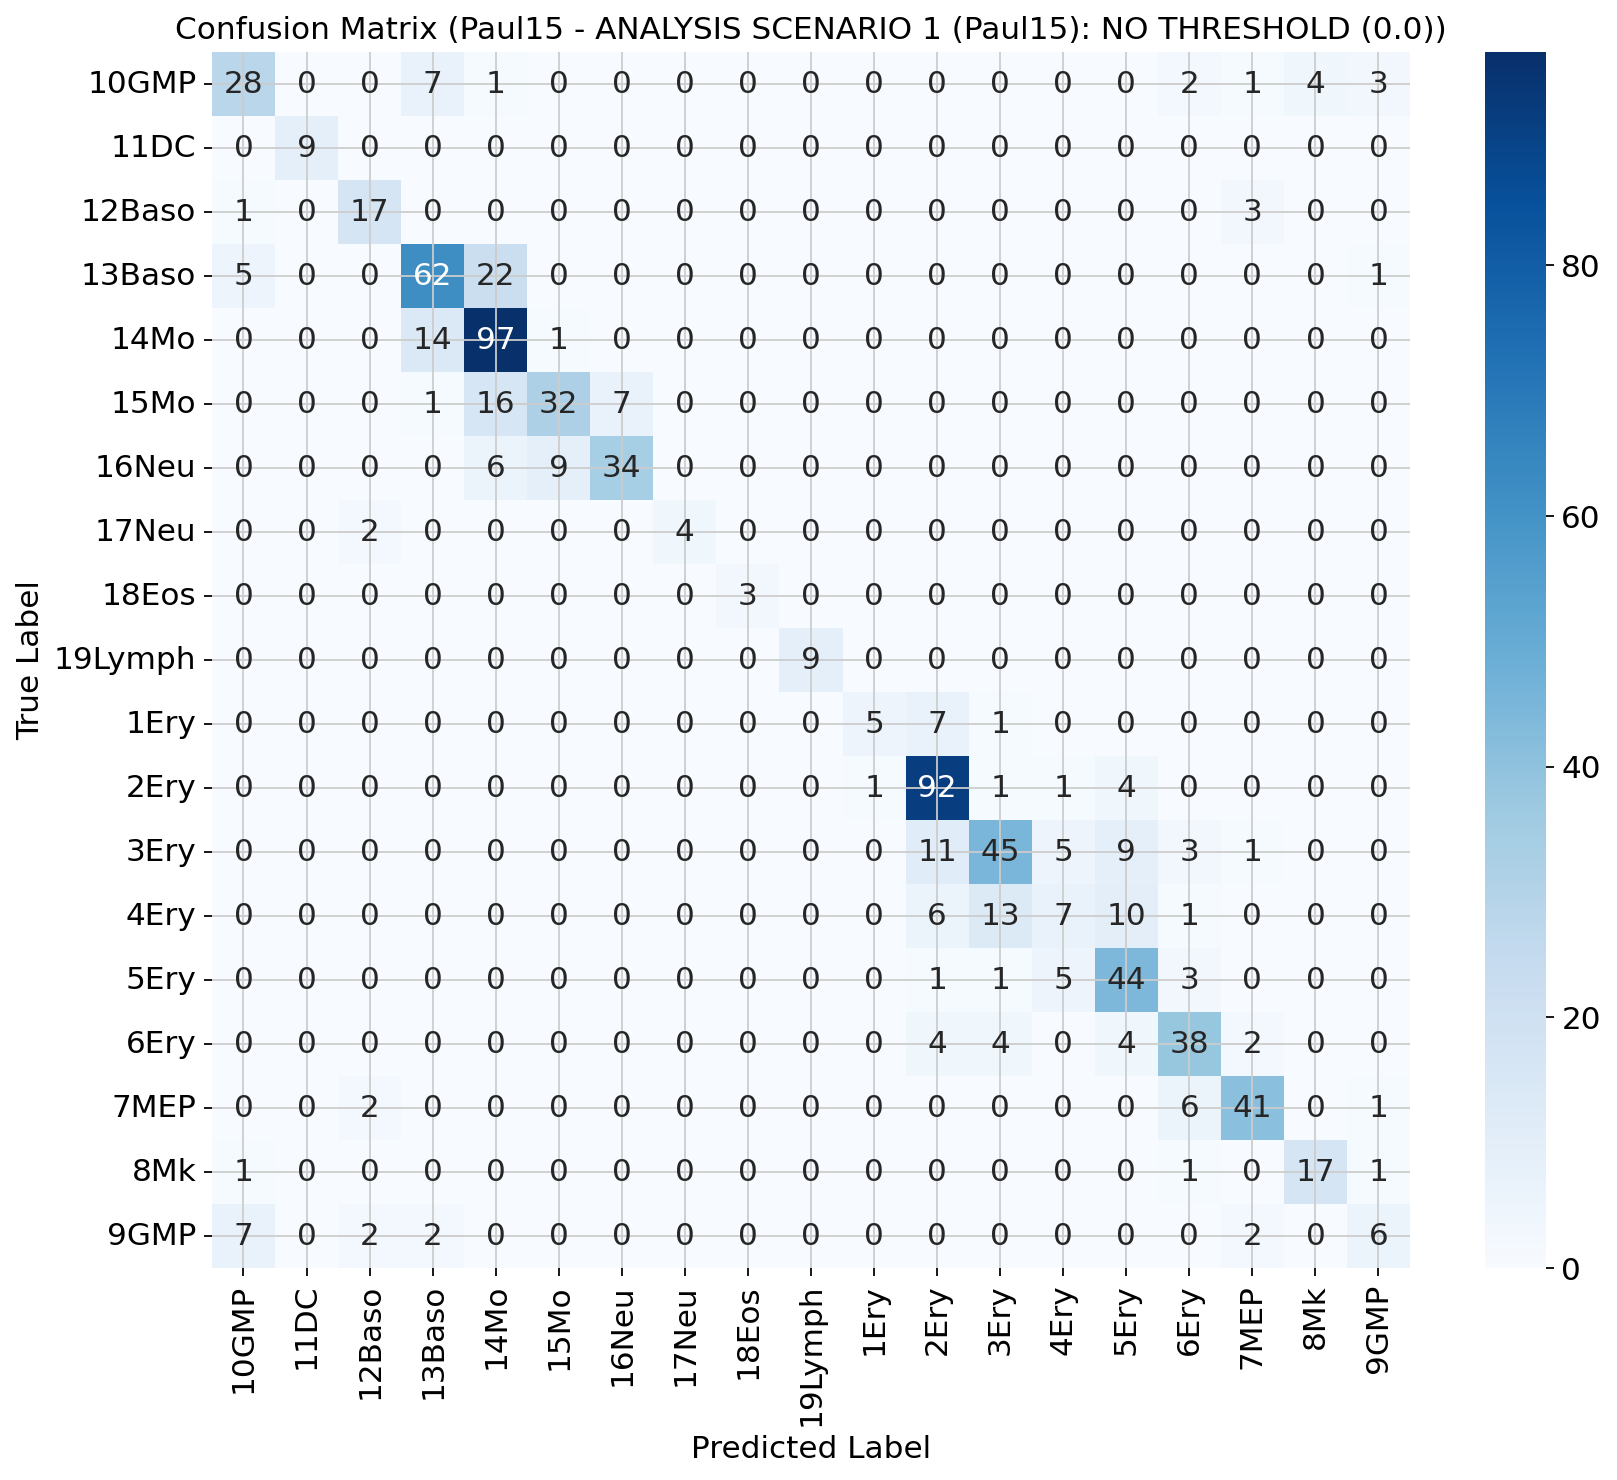


--- Per-Class ROC AUC (ANALYSIS SCENARIO 1 (Paul15): NO THRESHOLD (0.0)) ---


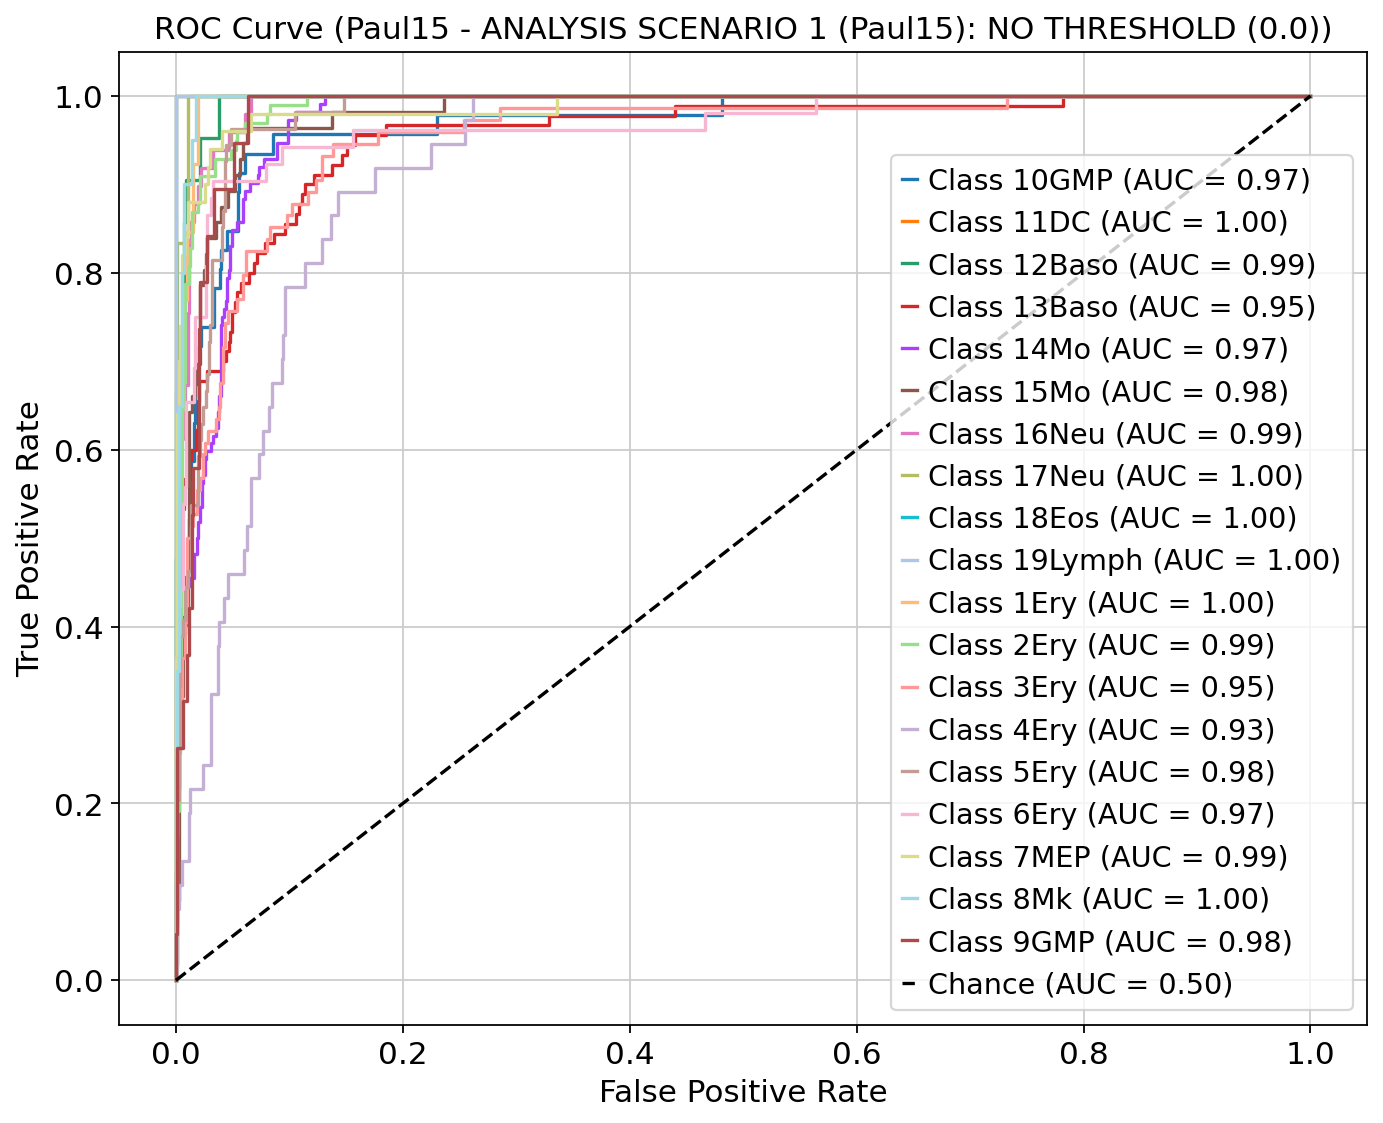


--- Distribution of Prediction Probabilities (Per True Cell Type, ANALYSIS SCENARIO 1 (Paul15): NO THRESHOLD (0.0)) ---


/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


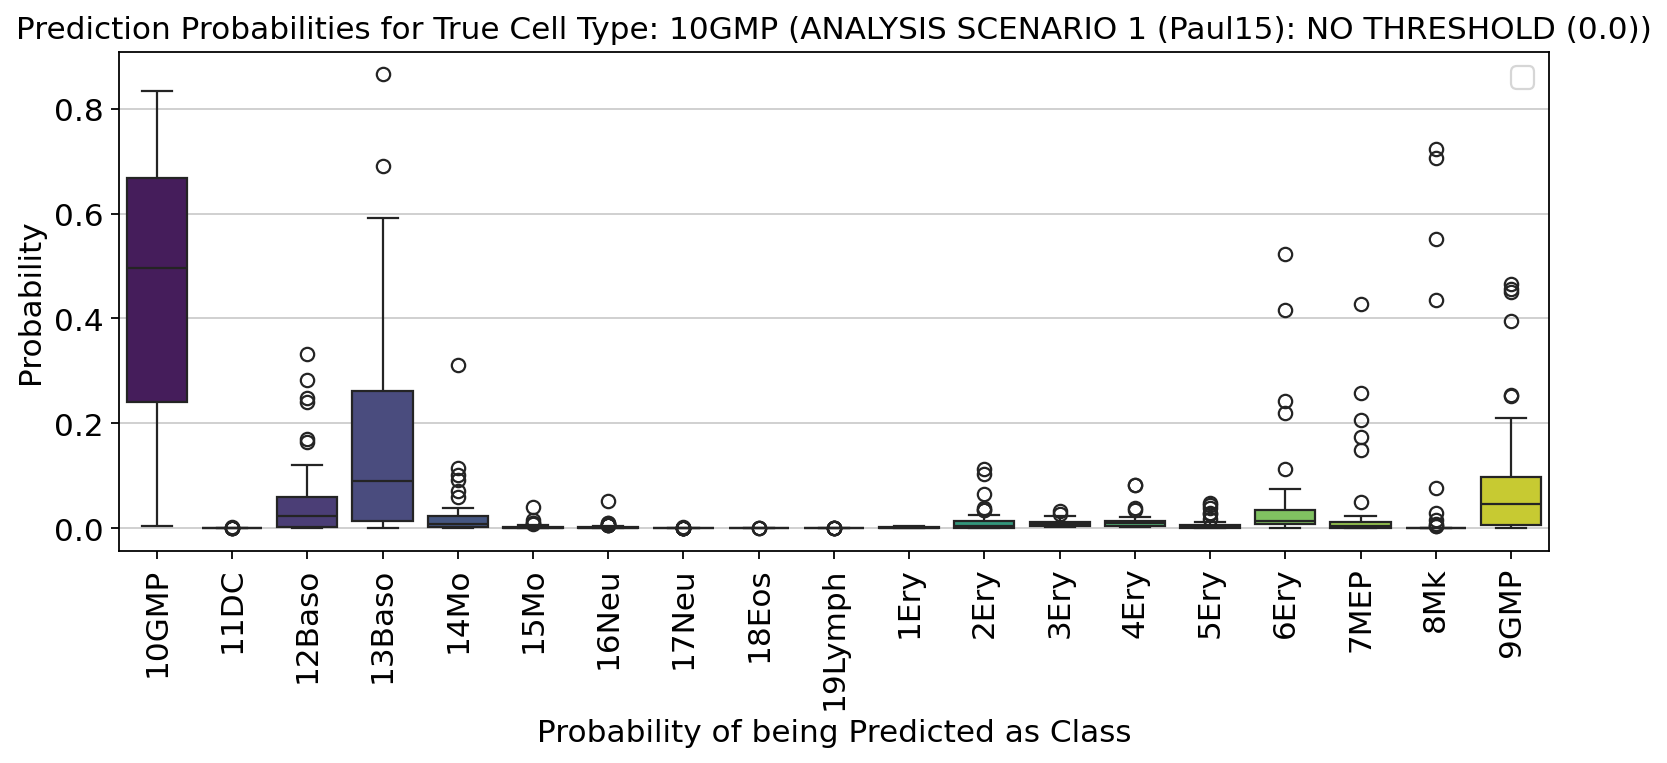

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


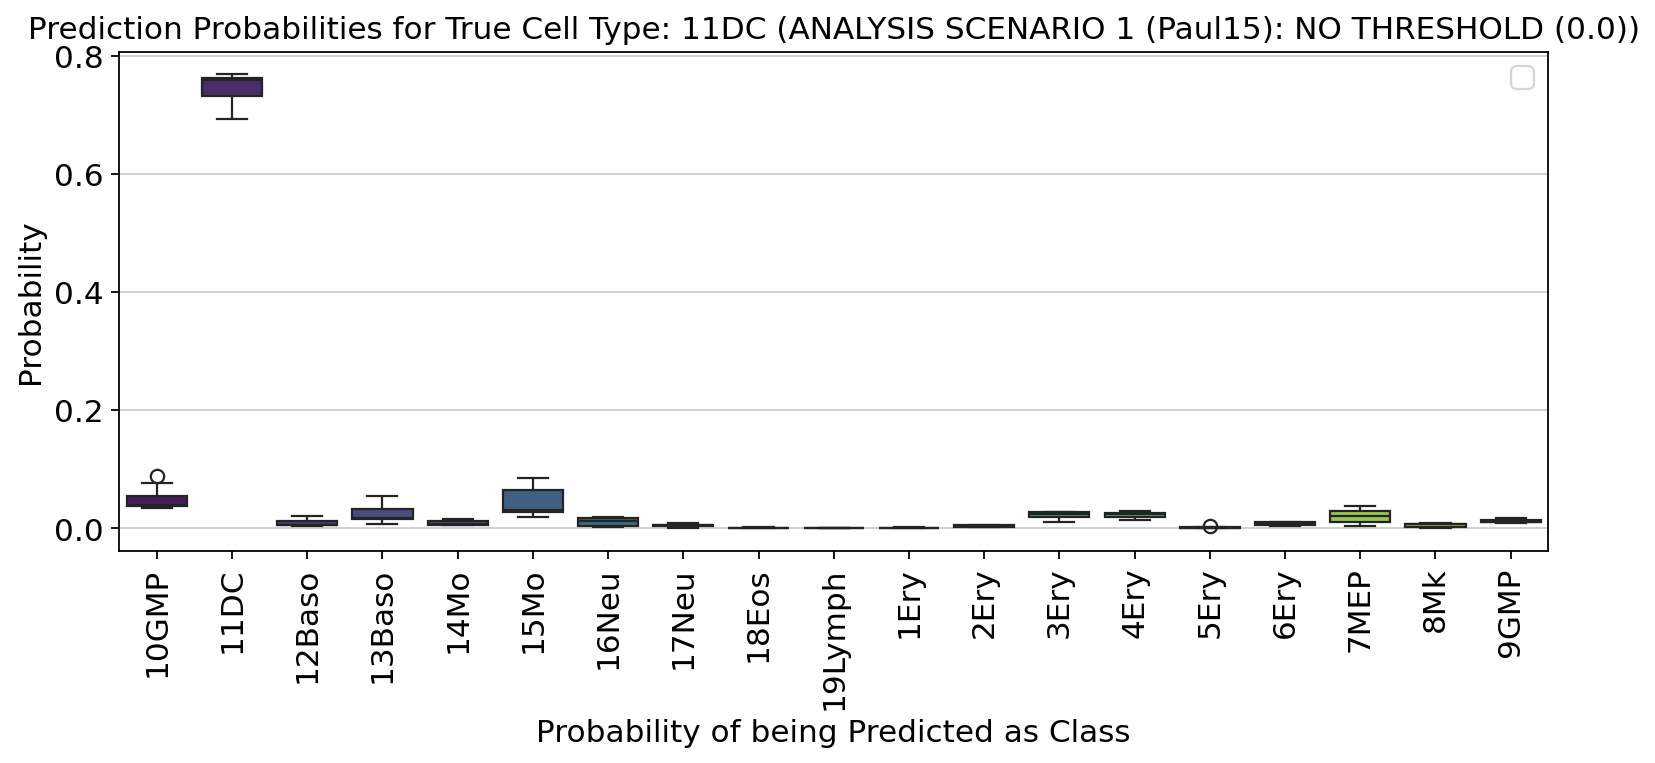

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


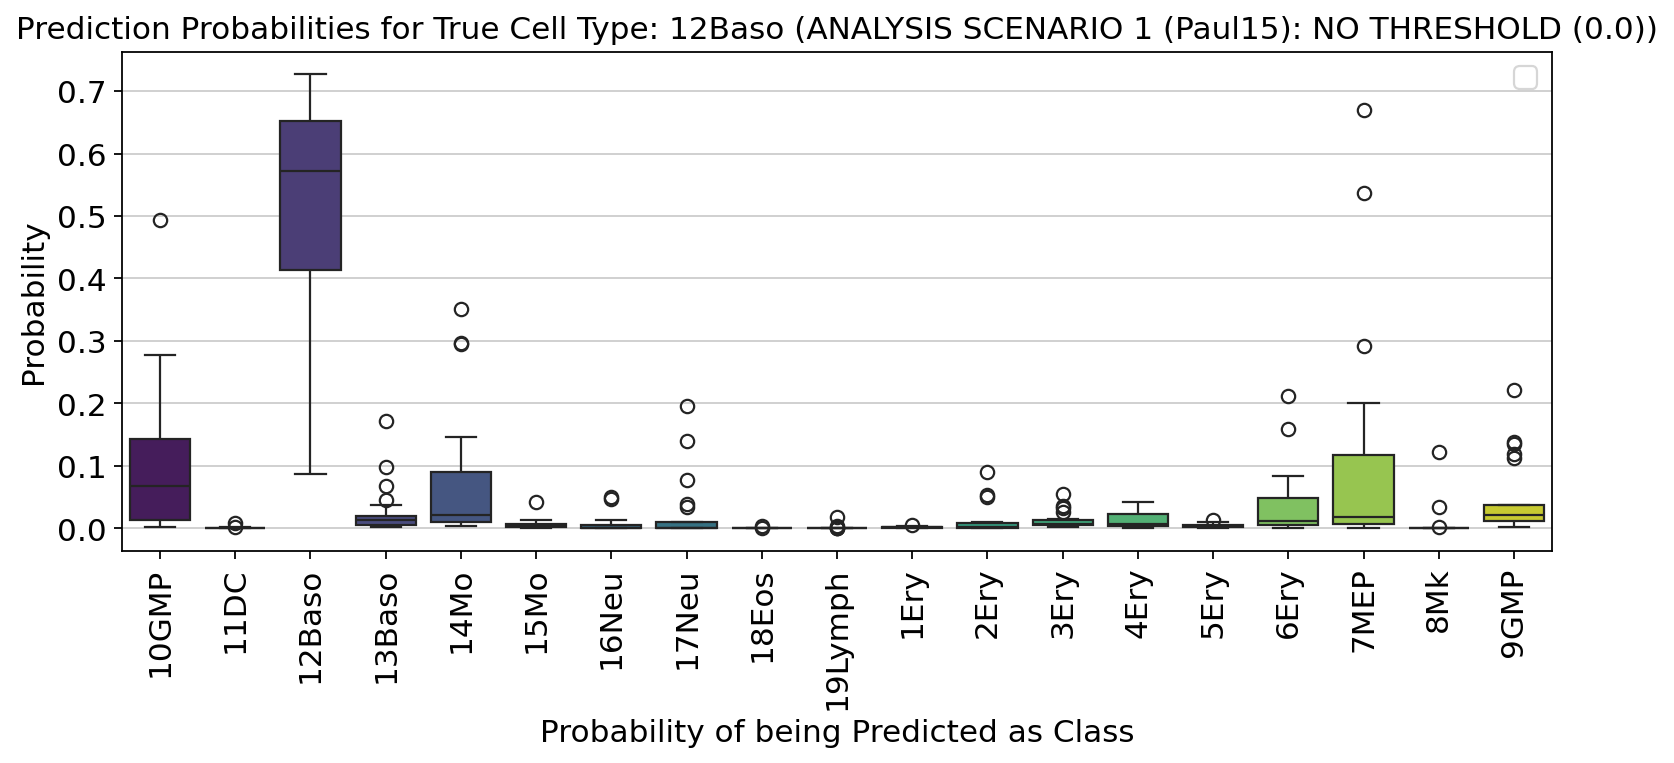

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


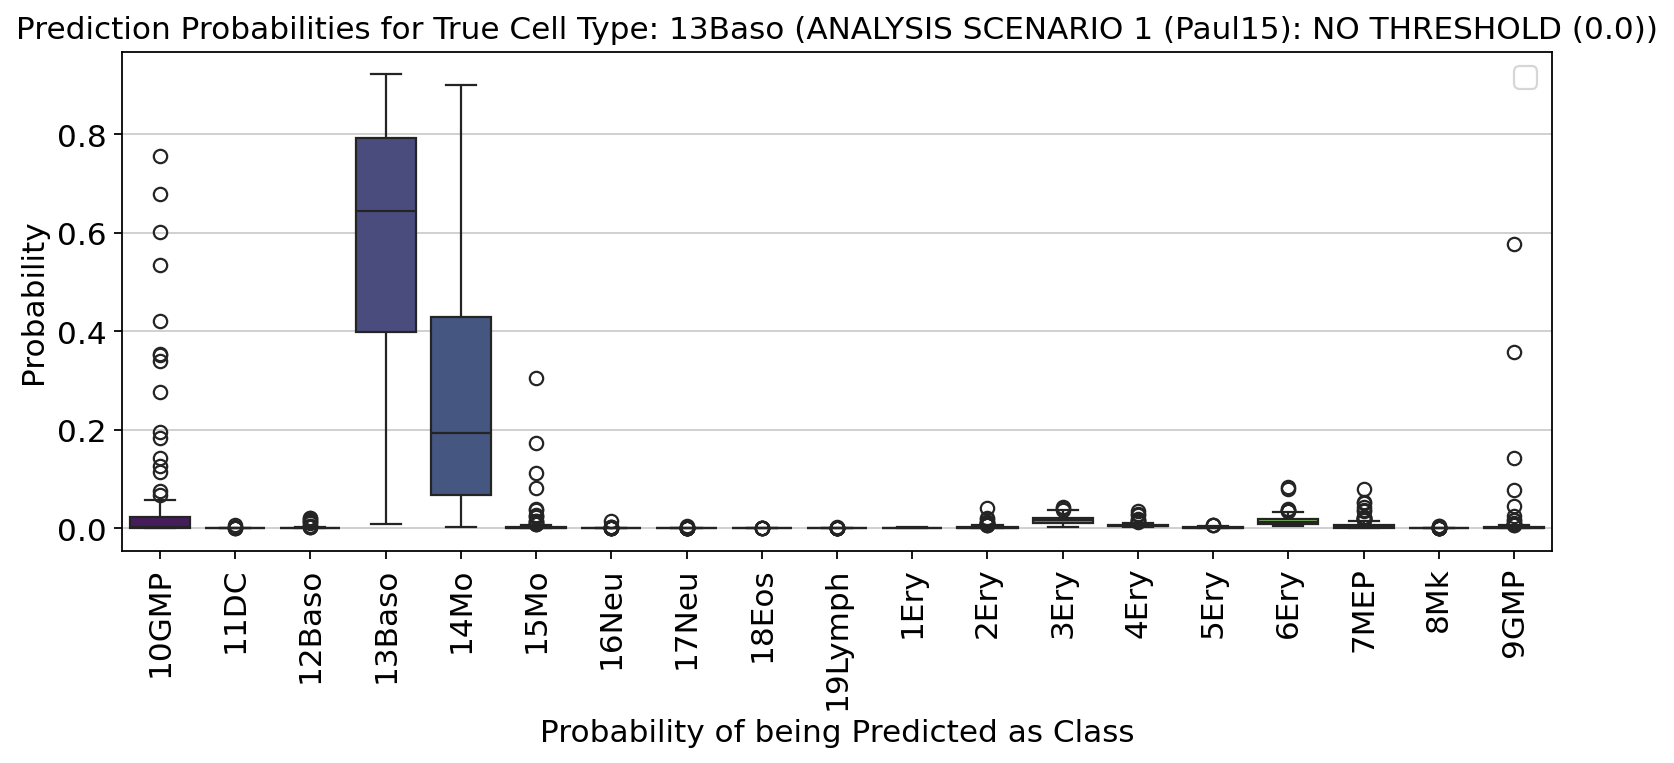

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


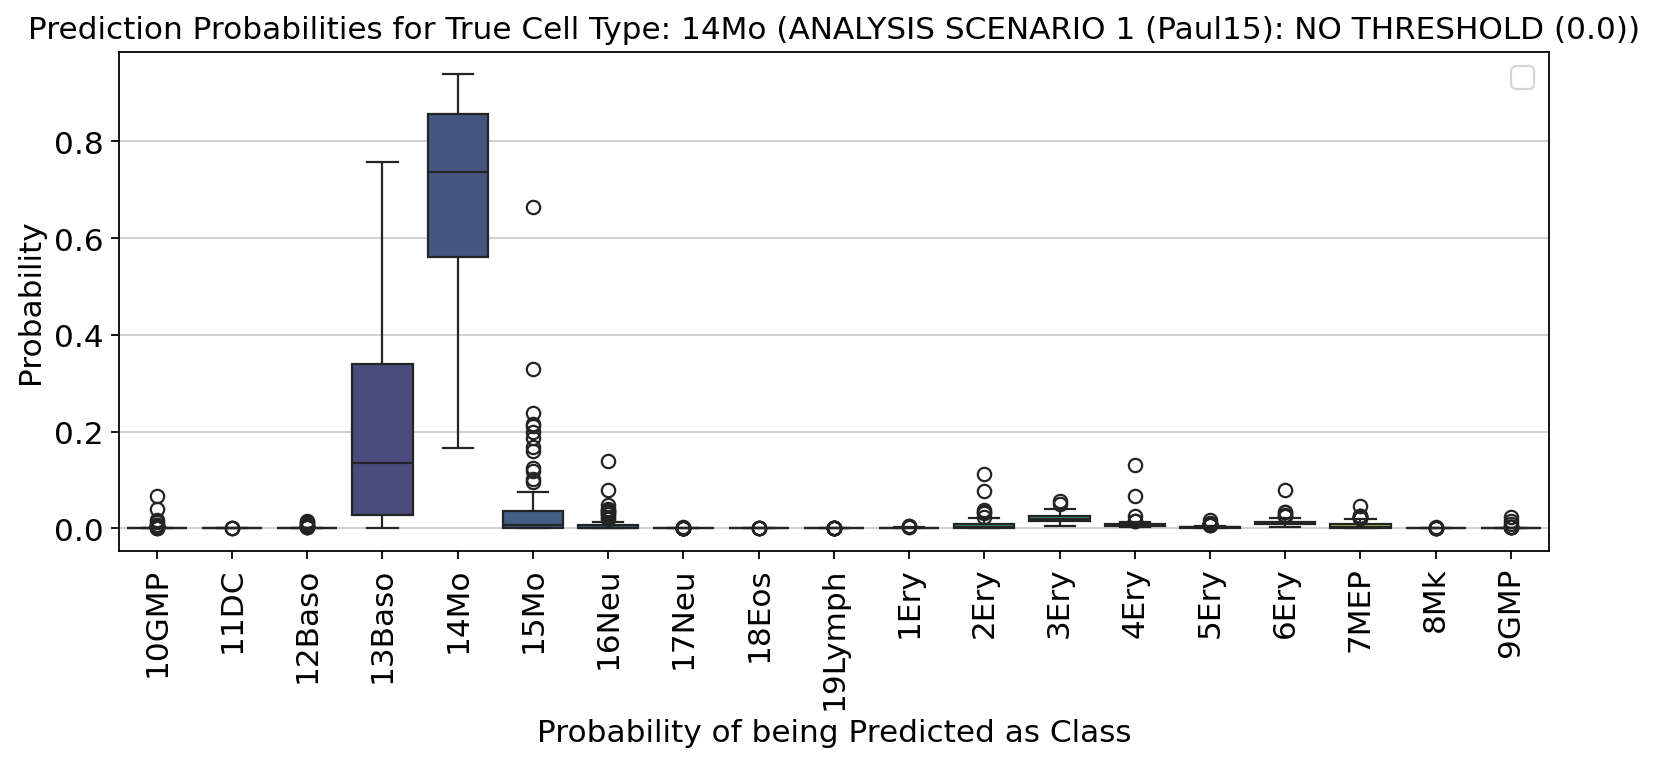

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


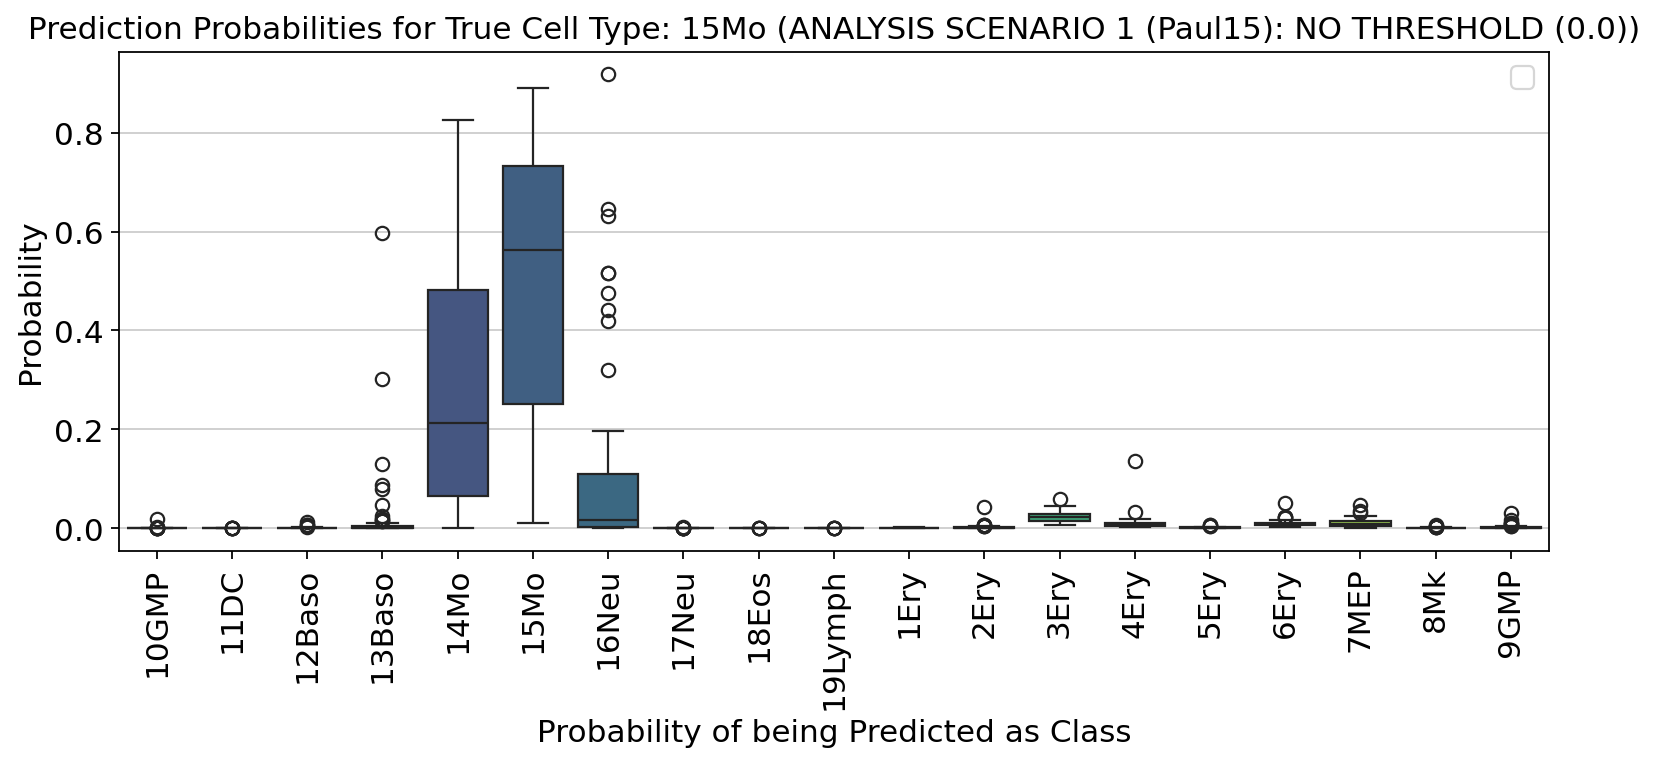

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


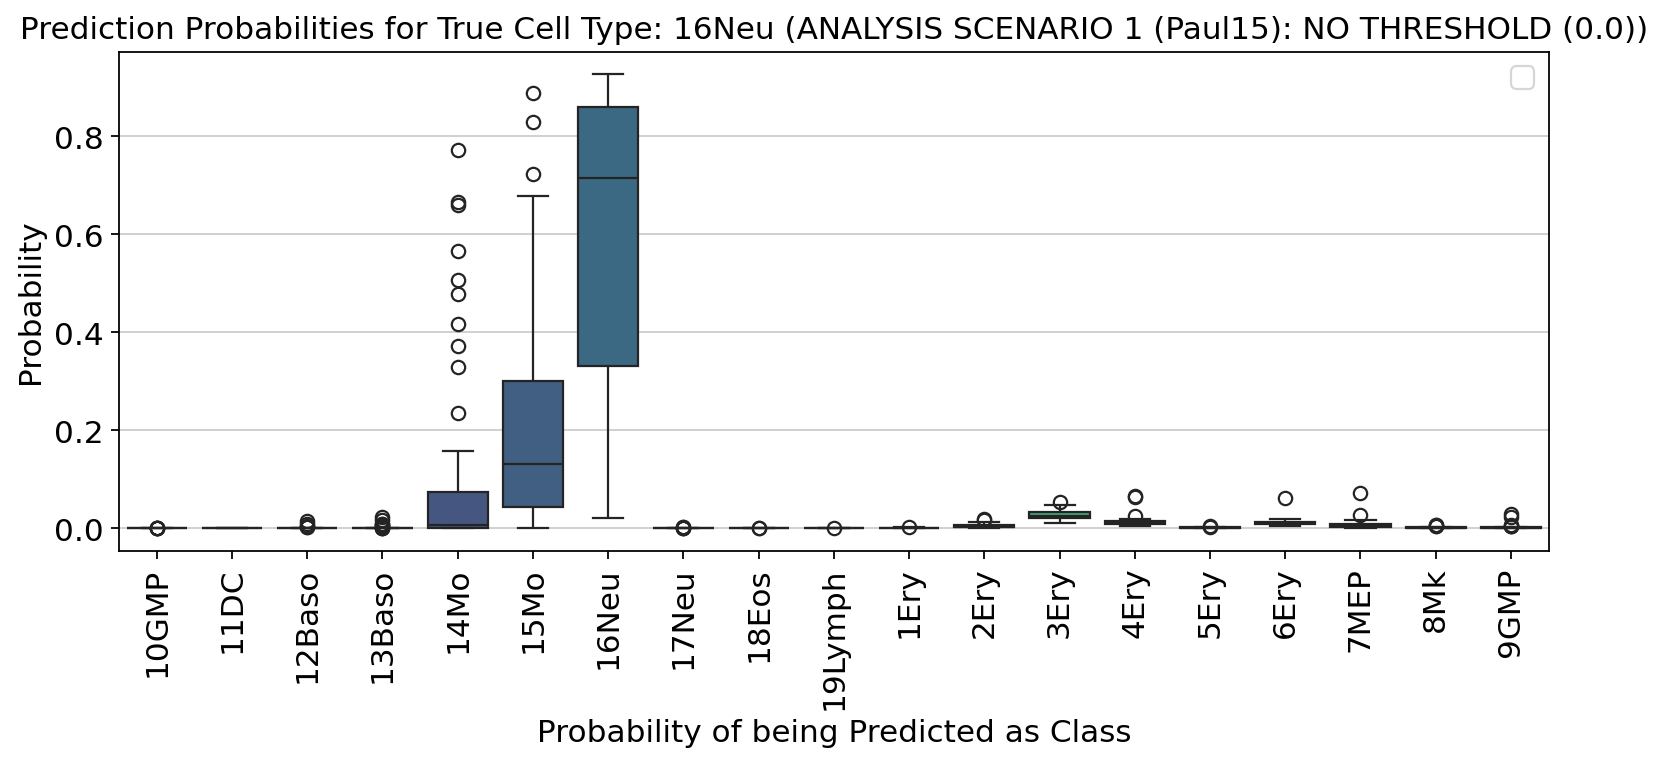

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


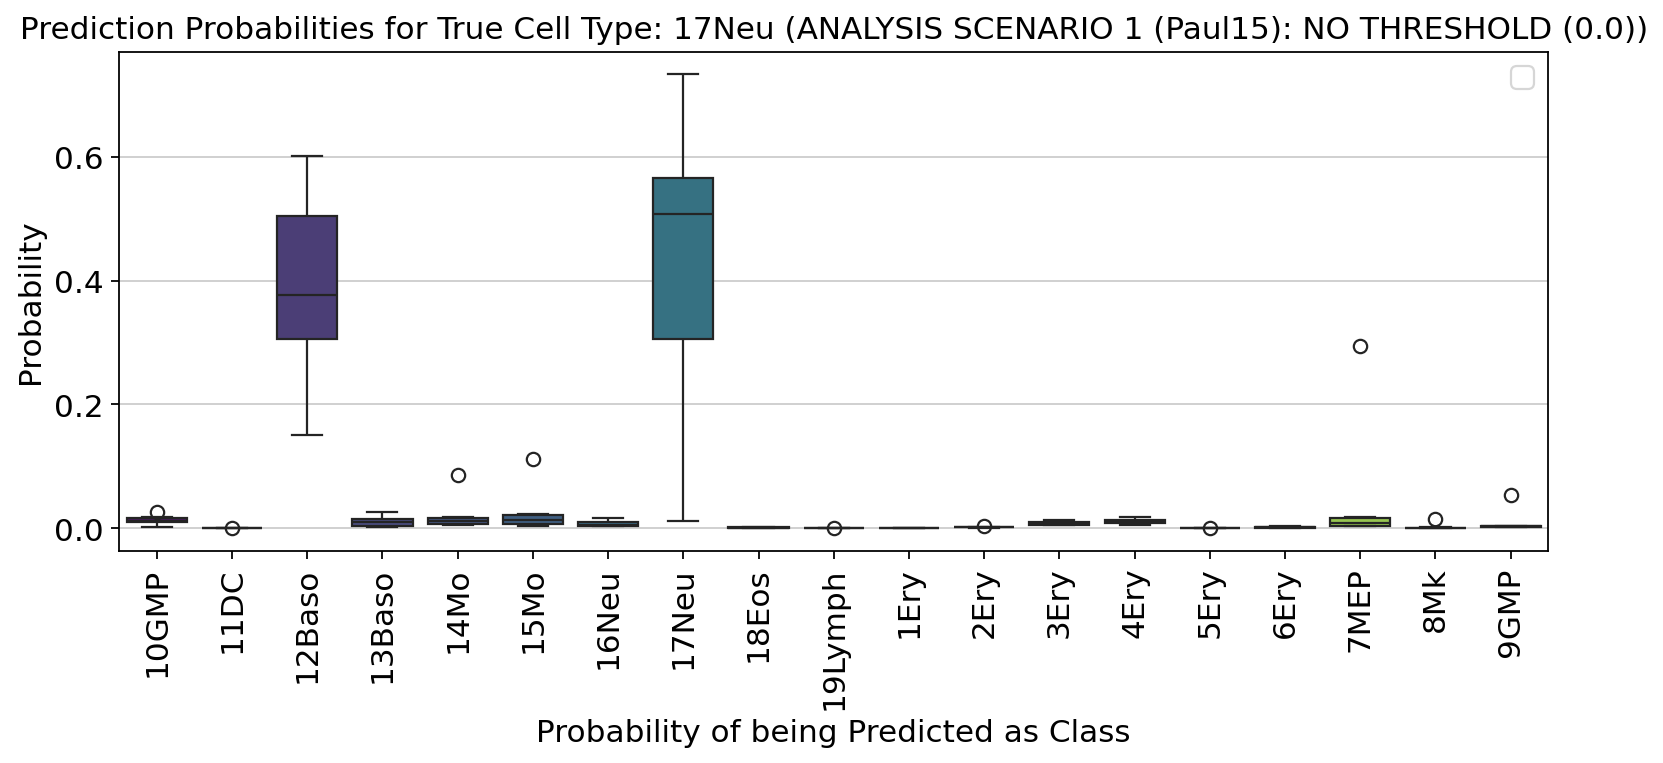

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


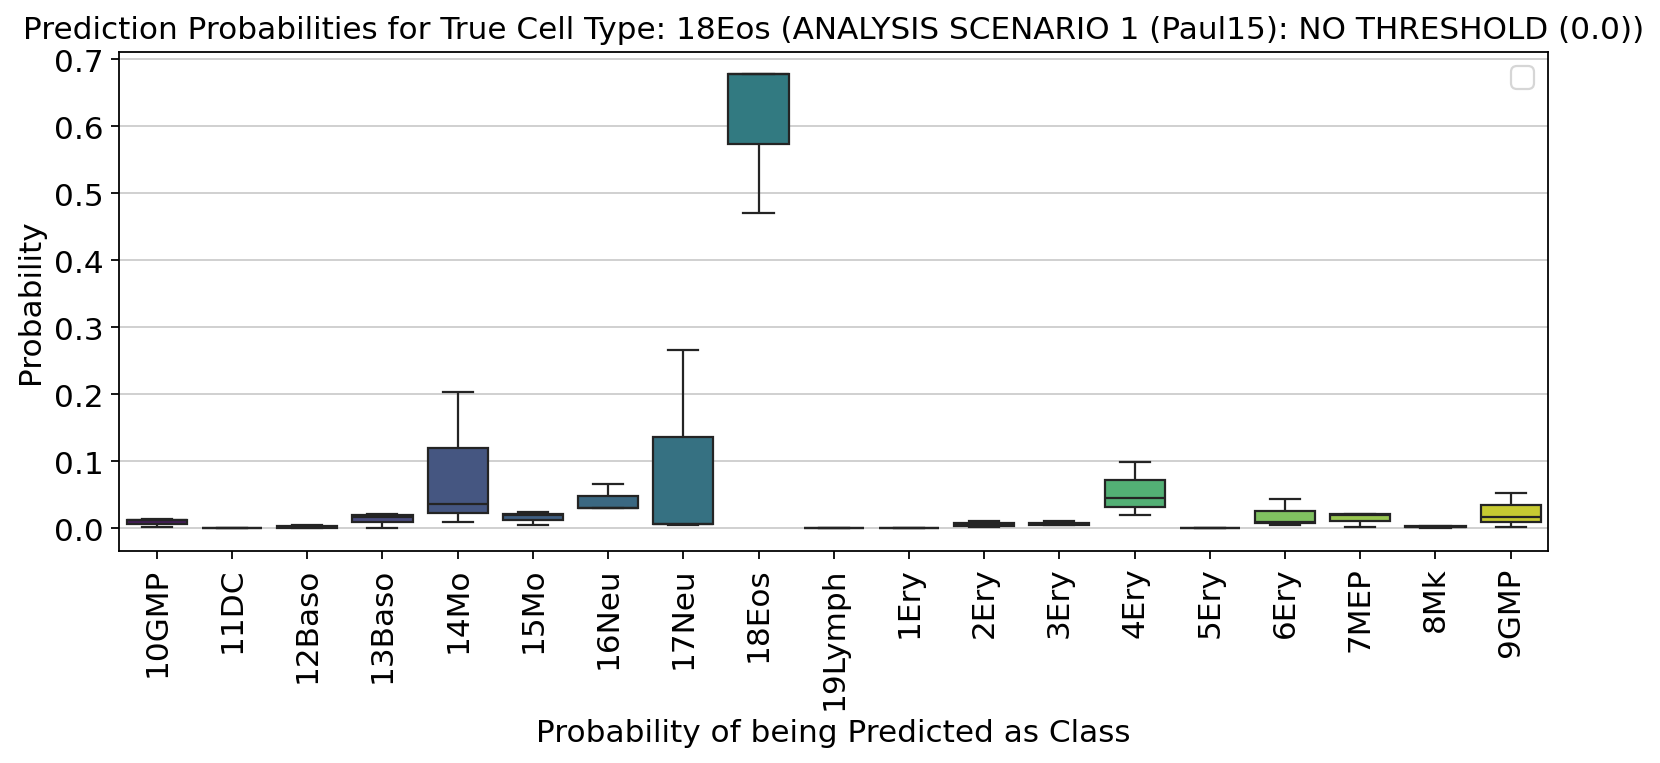

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


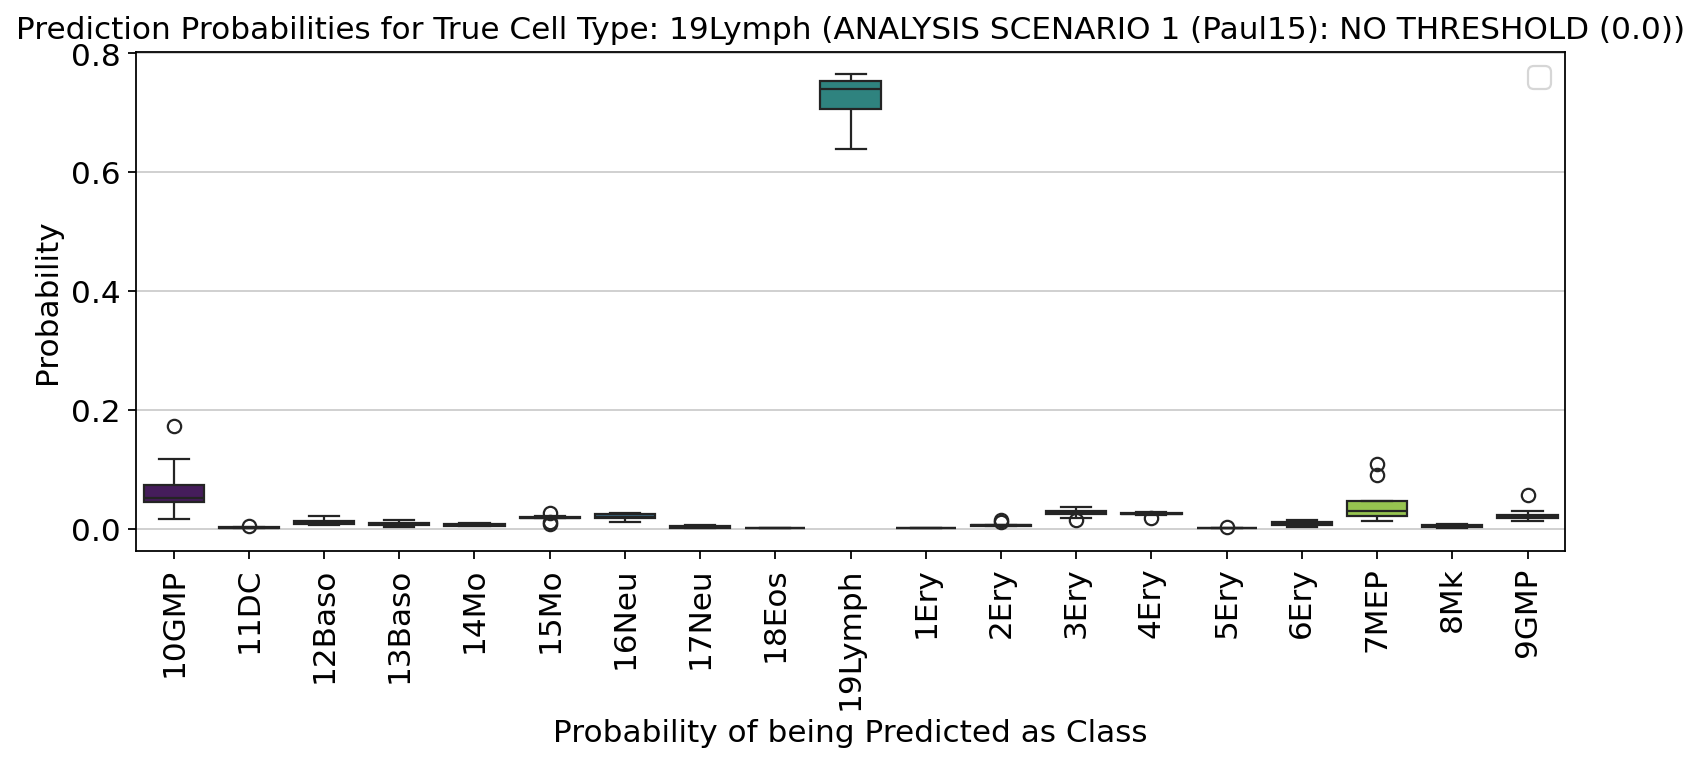

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


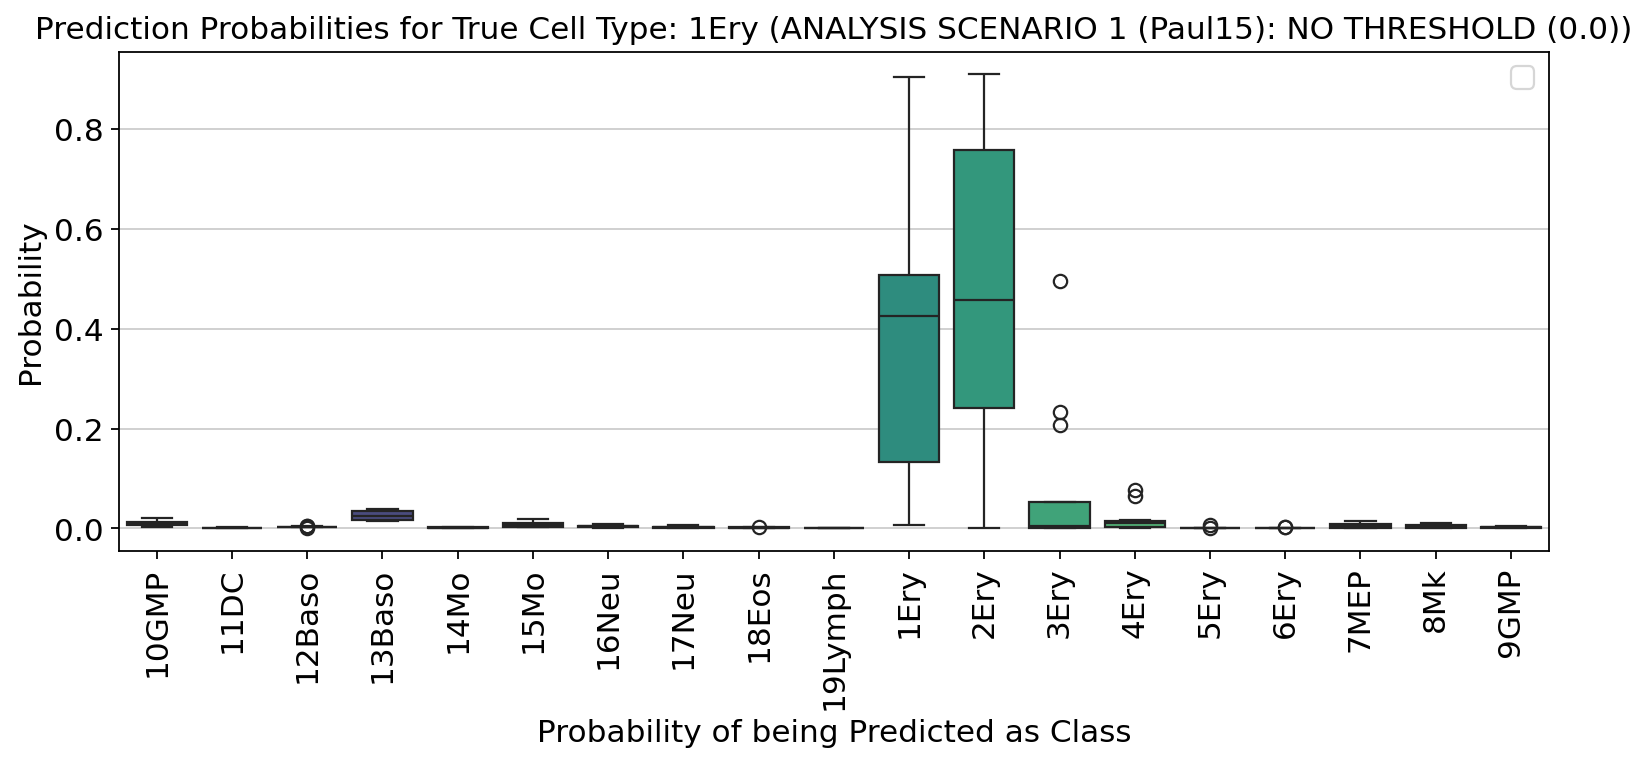

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


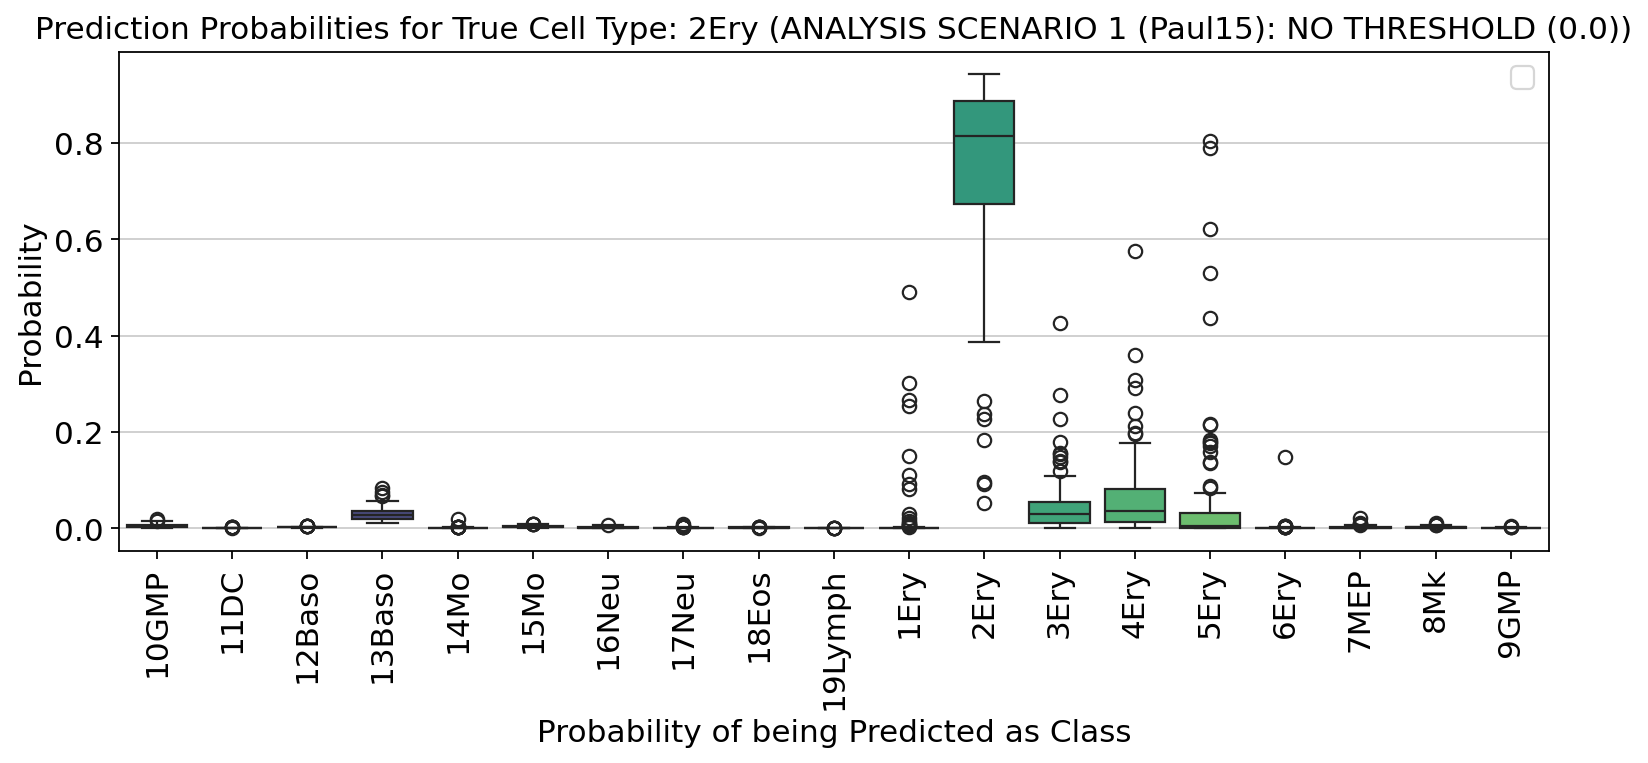

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


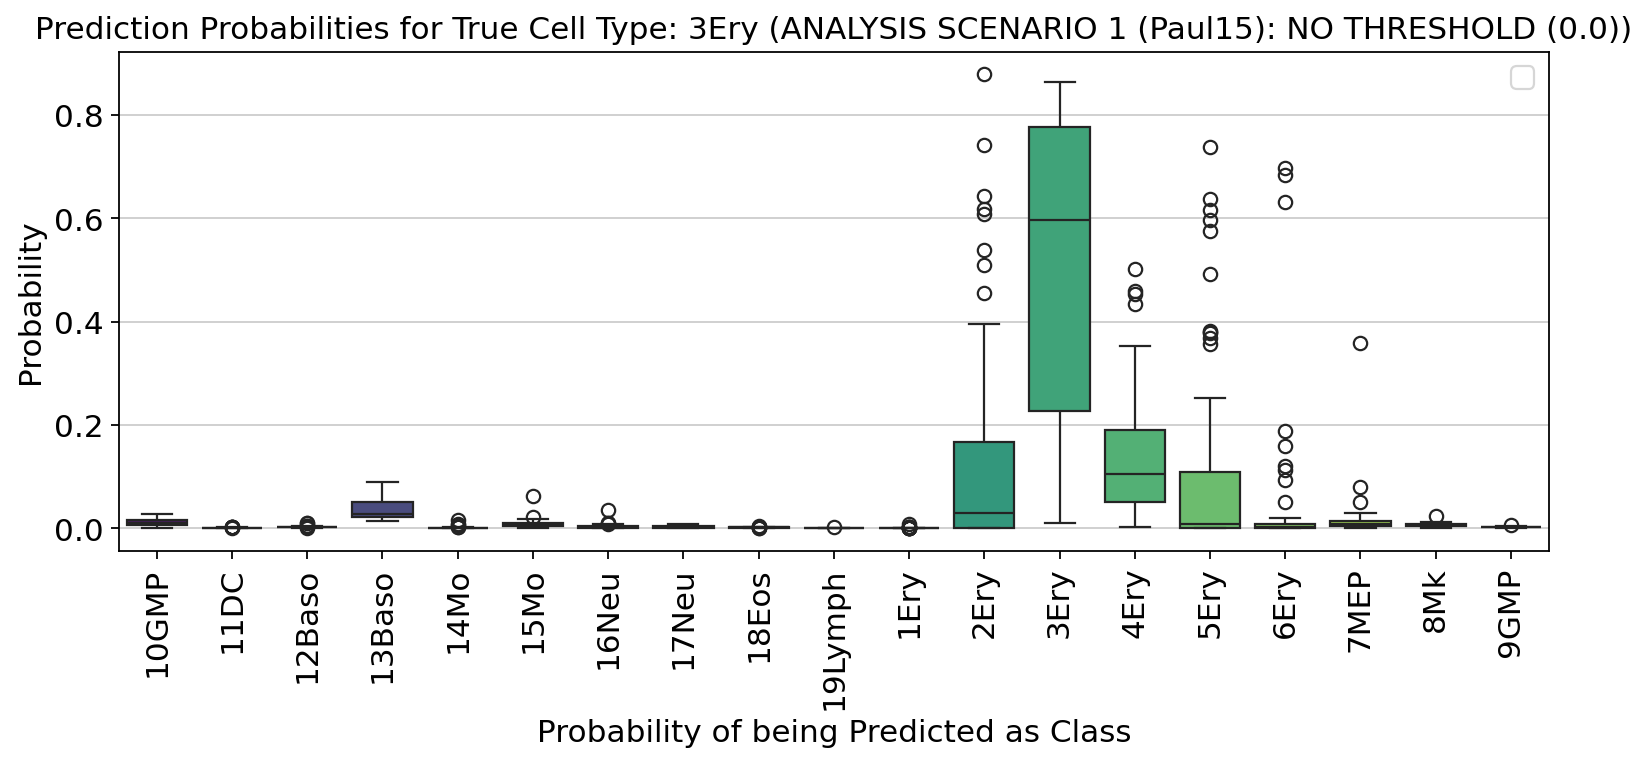

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


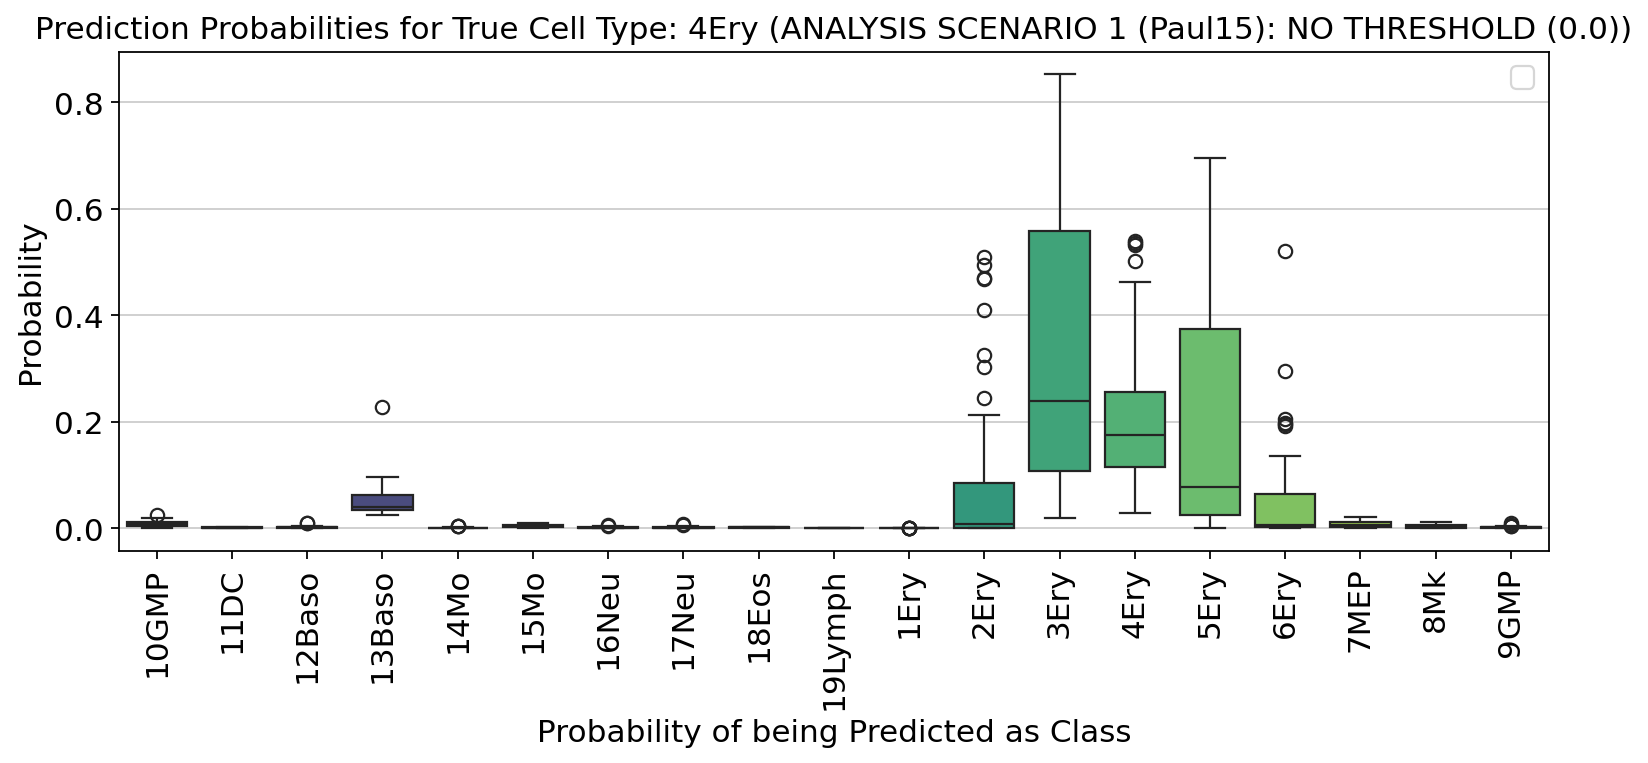

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


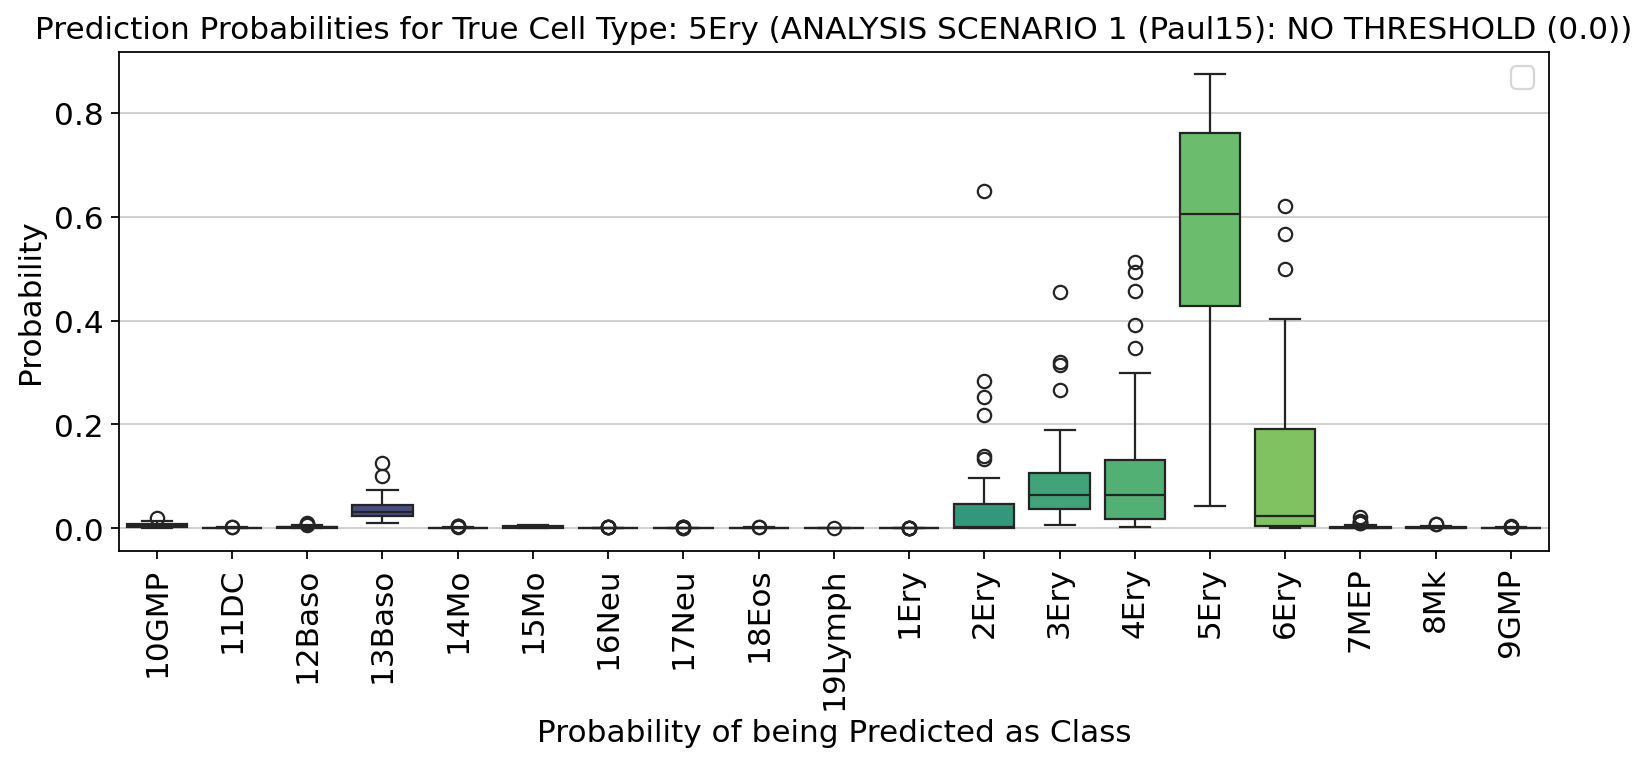

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


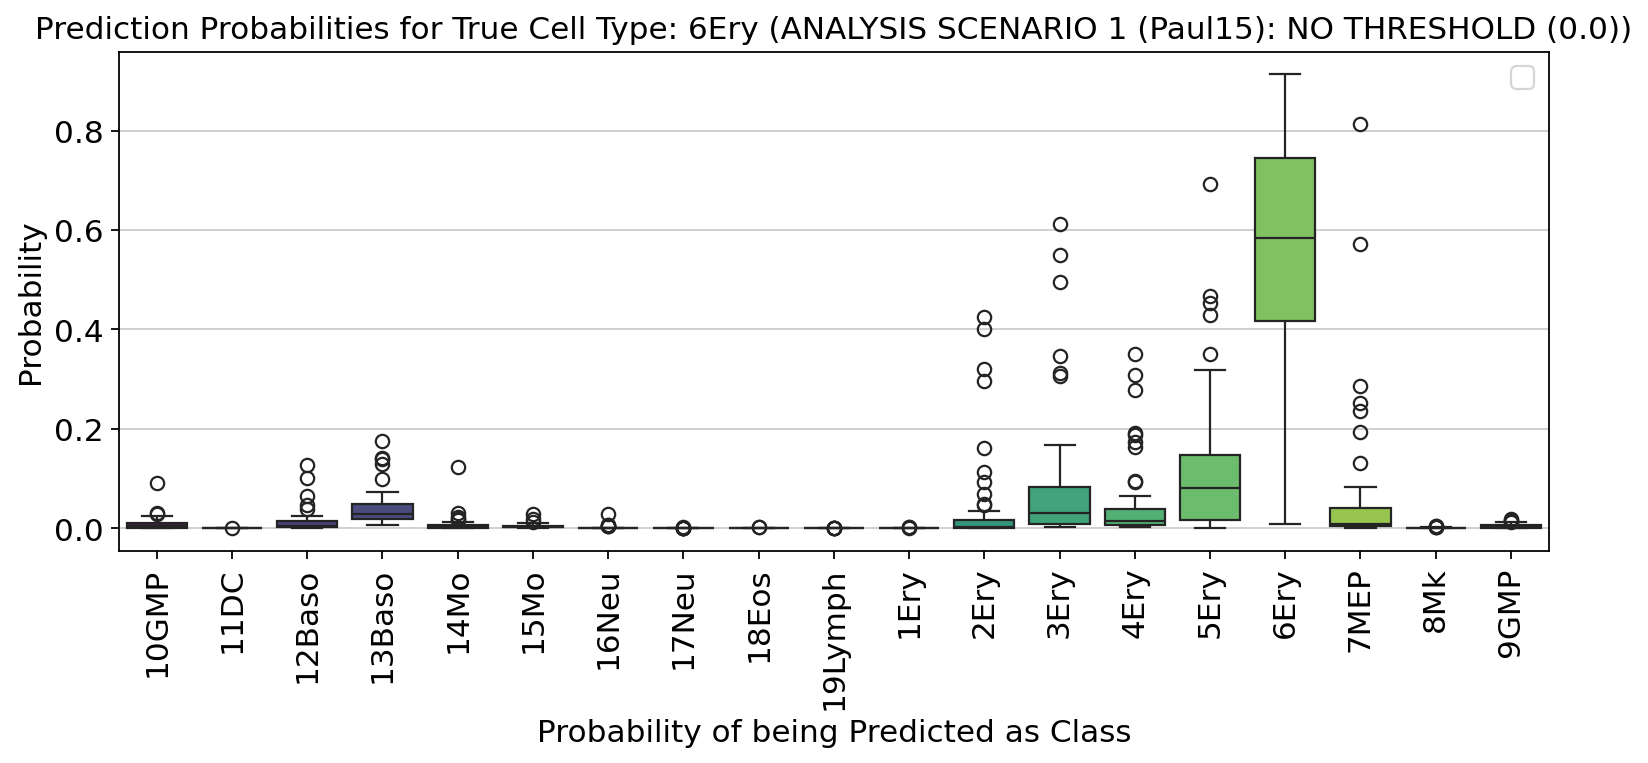

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


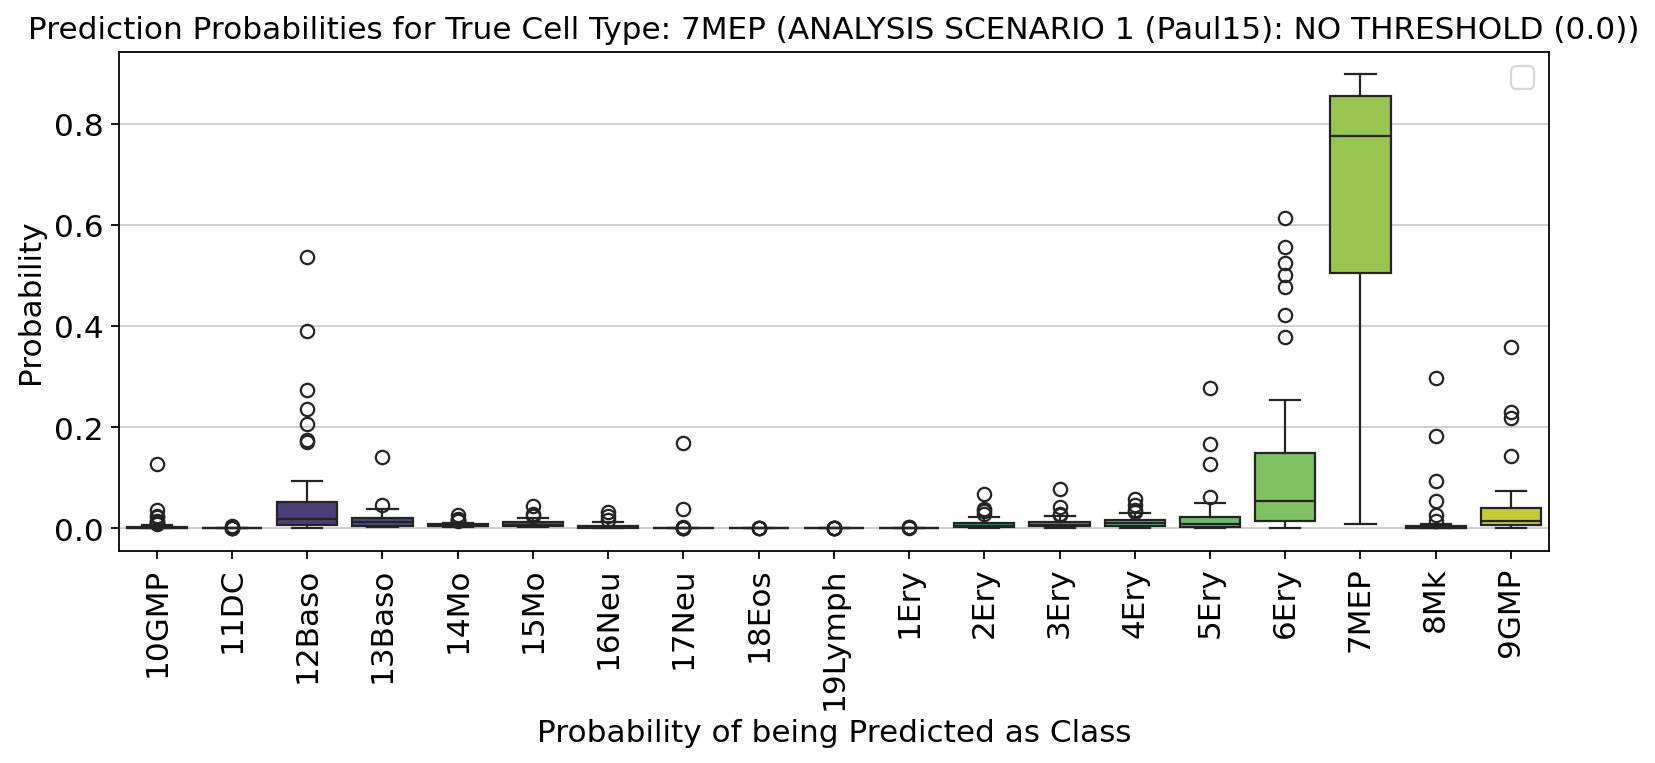

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


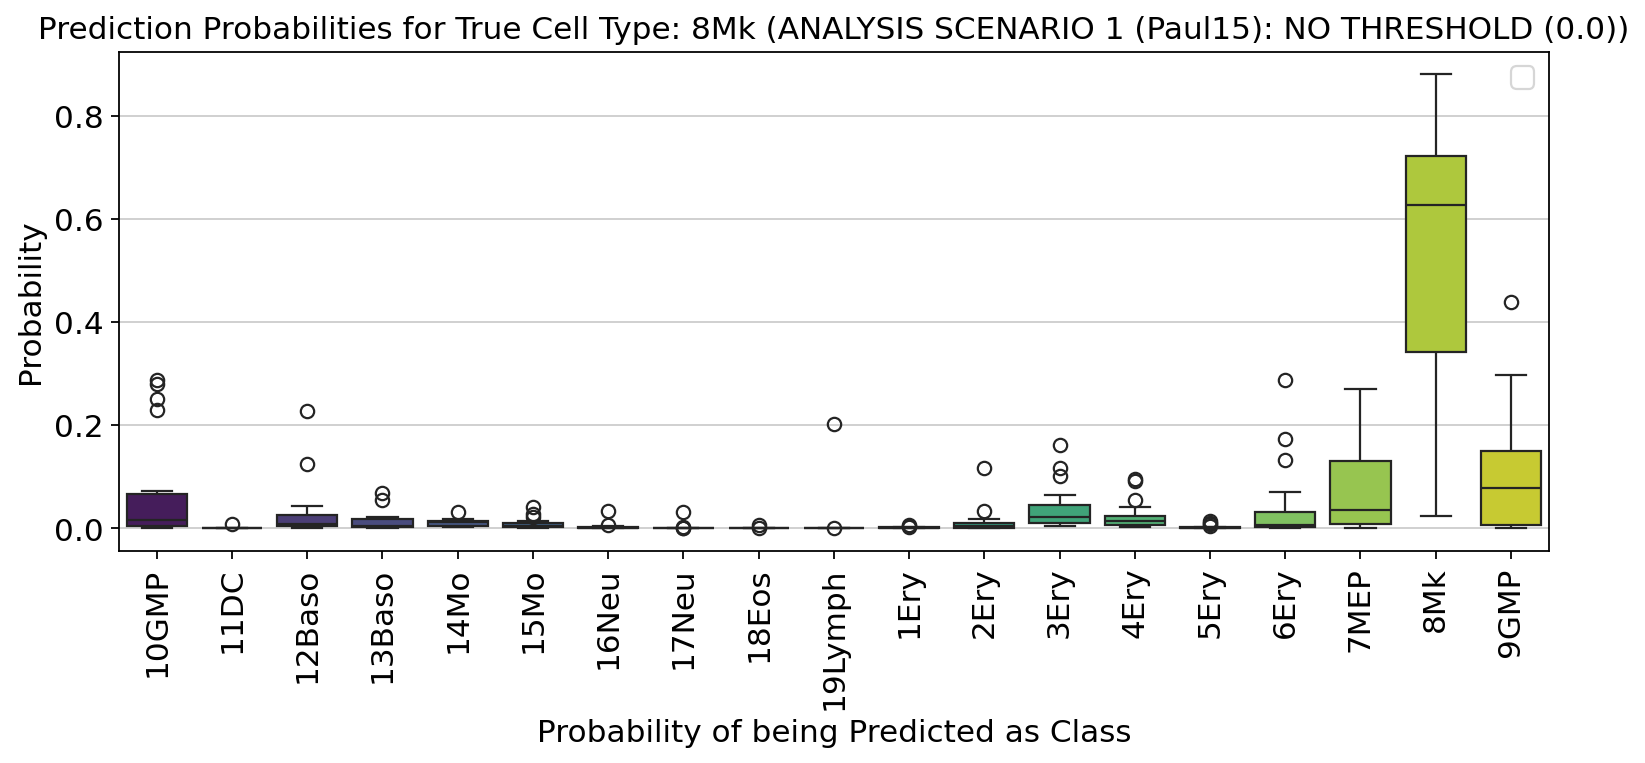

/tmp/ipykernel_1633/2507548989.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


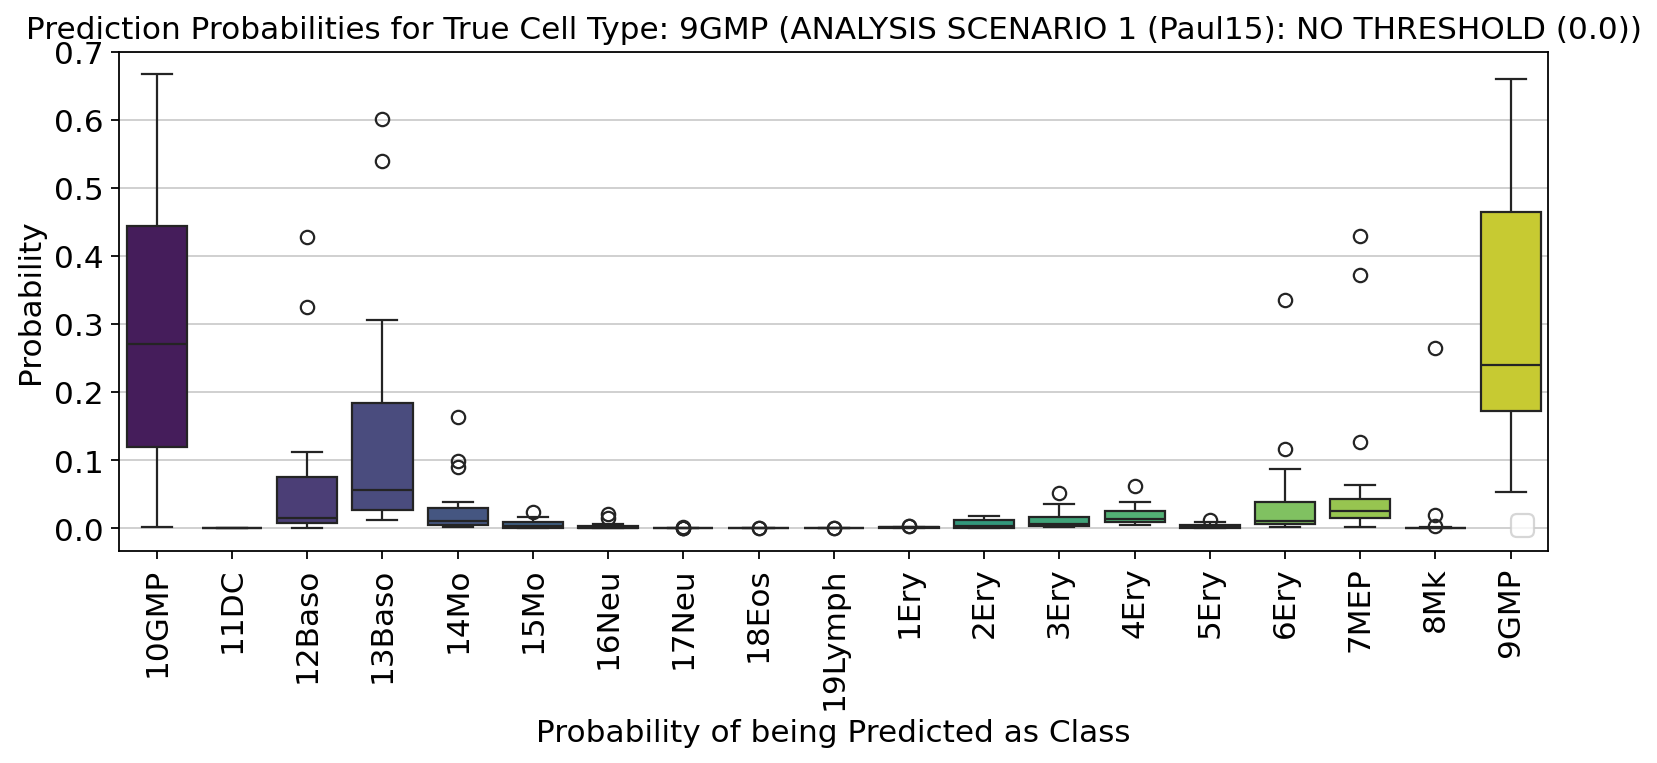


--- Max Prediction Probability per True Cell Type (ANALYSIS SCENARIO 1 (Paul15): NO THRESHOLD (0.0)) ---


/tmp/ipykernel_1633/2507548989.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


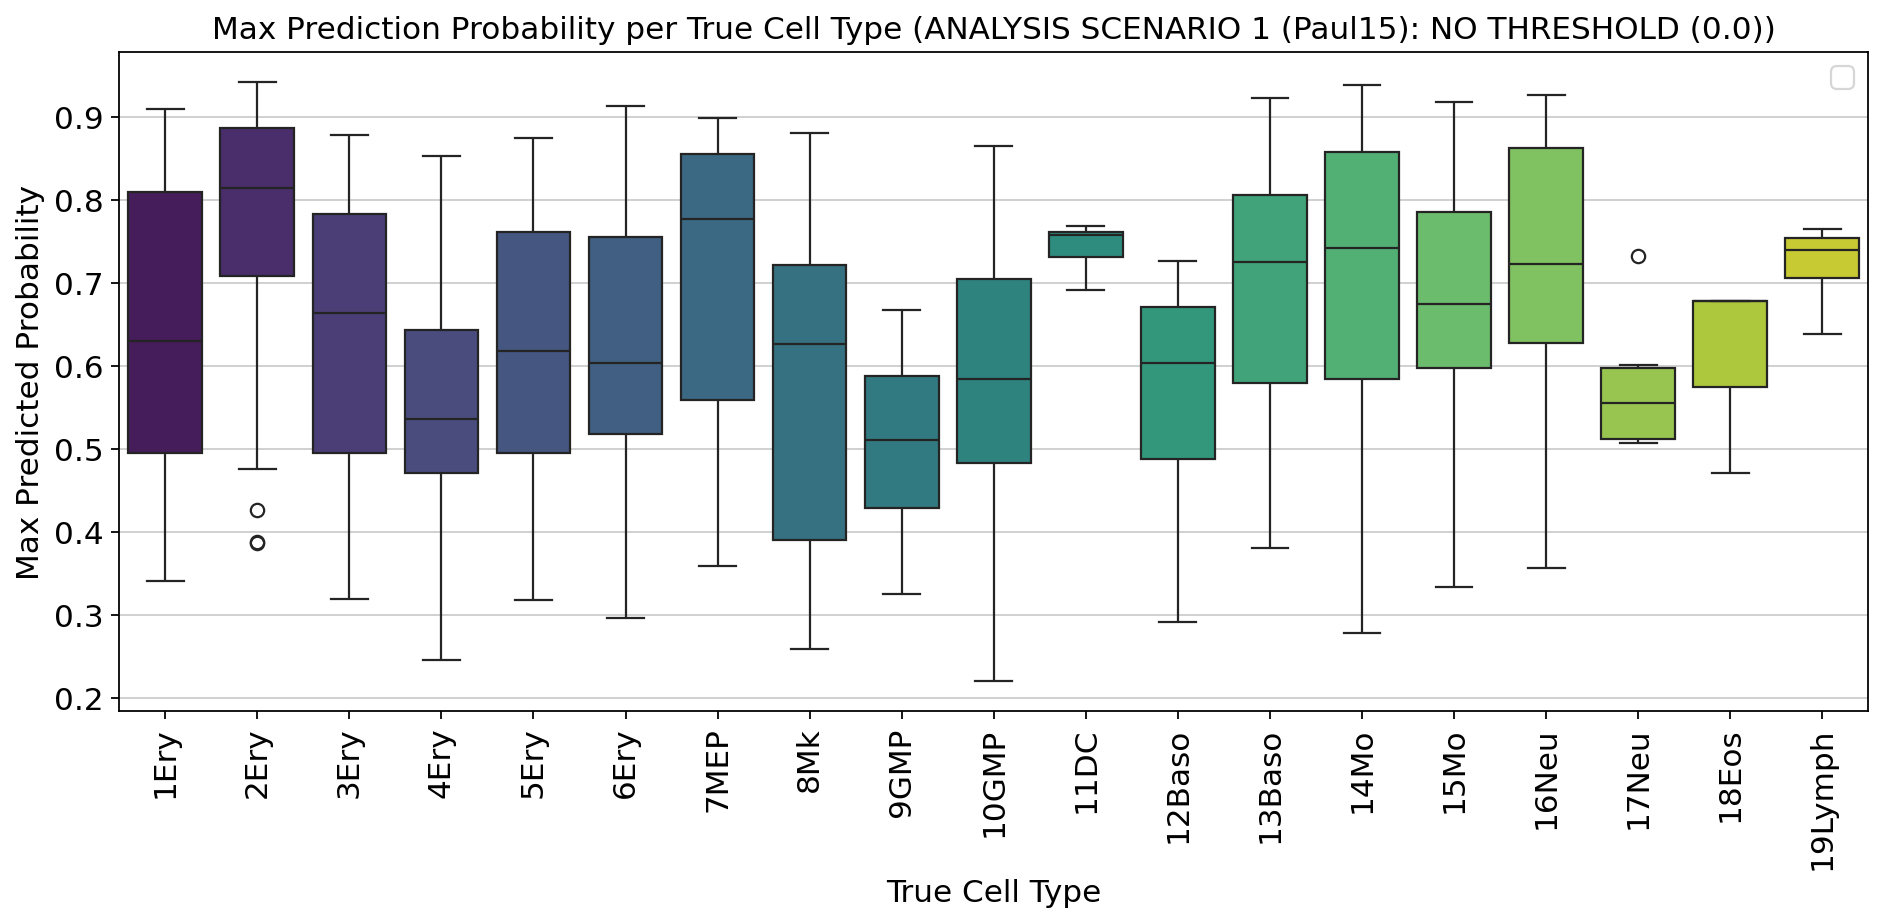


--- Max Prediction Probability per Predicted Label (ANALYSIS SCENARIO 1 (Paul15): NO THRESHOLD (0.0)) ---


/tmp/ipykernel_1633/2507548989.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.xticks(rotation=90); plt.legend(); plt.tight_layout(); plt.show()


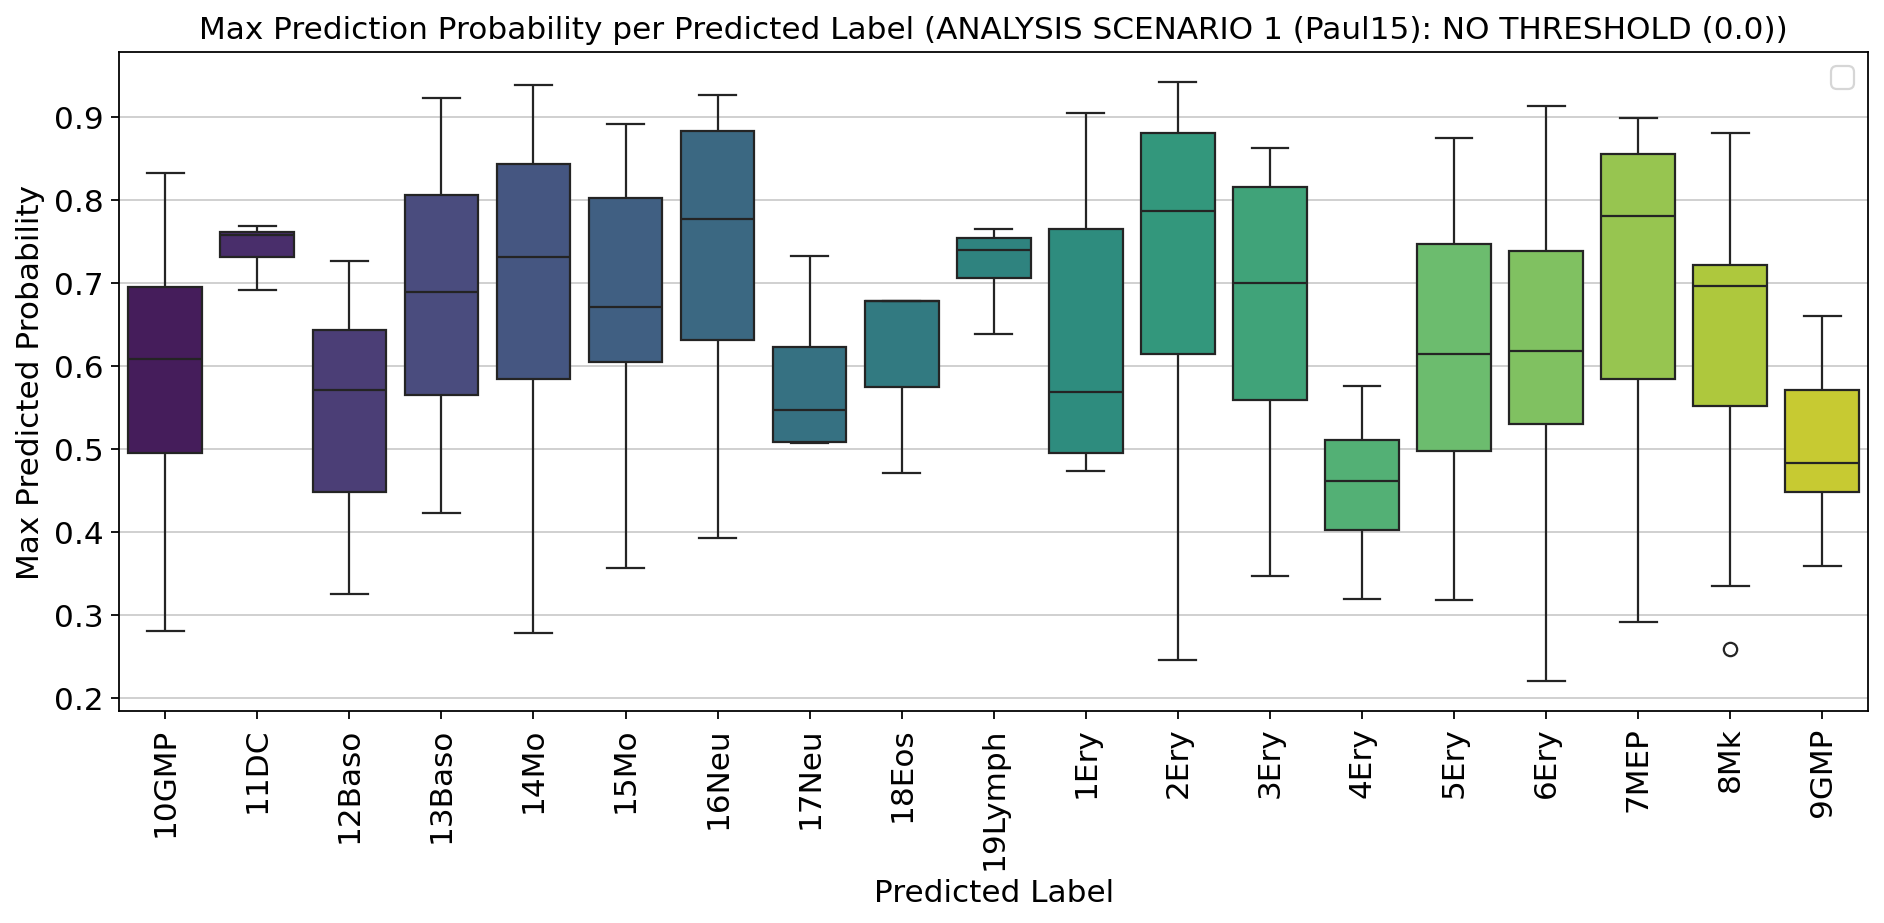


--- UMAP Visualizations (ANALYSIS SCENARIO 1 (Paul15): NO THRESHOLD (0.0)) ---


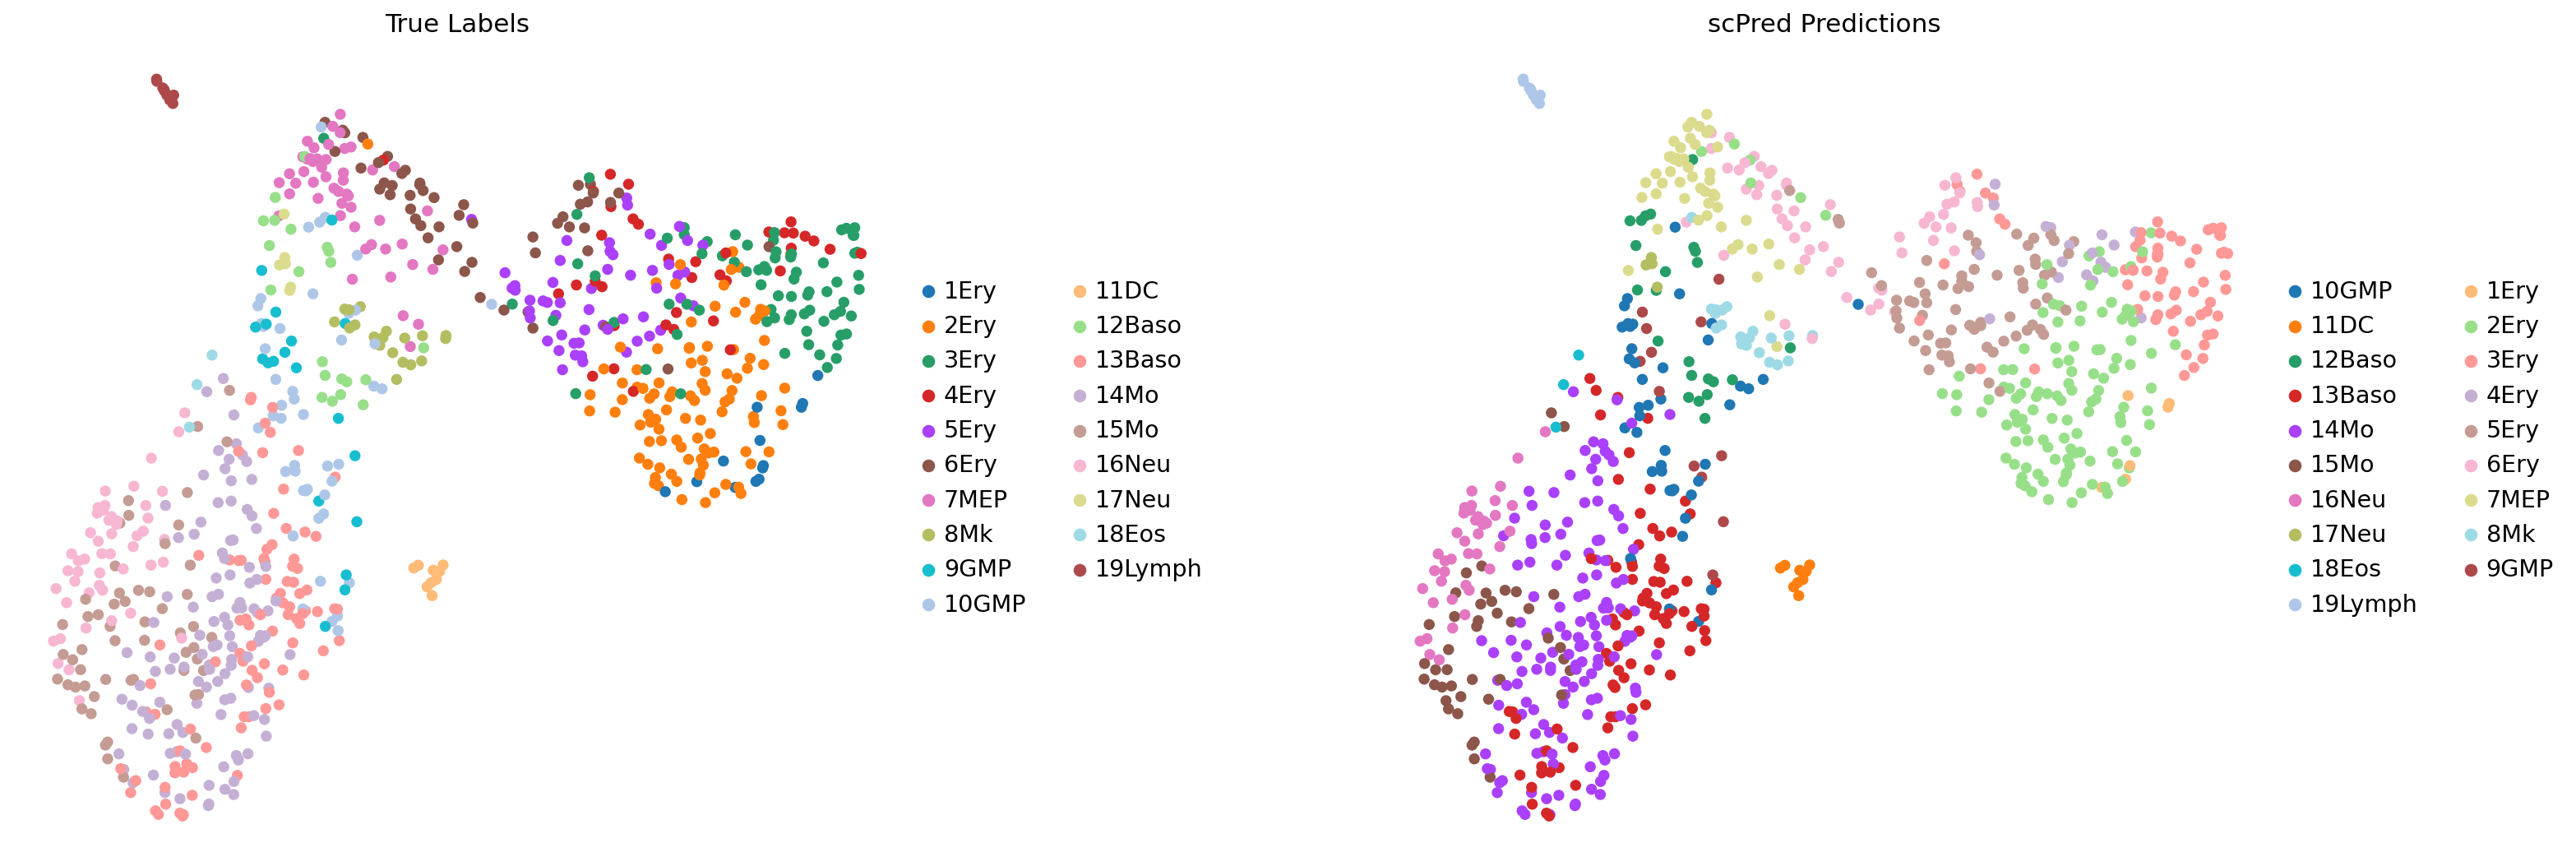

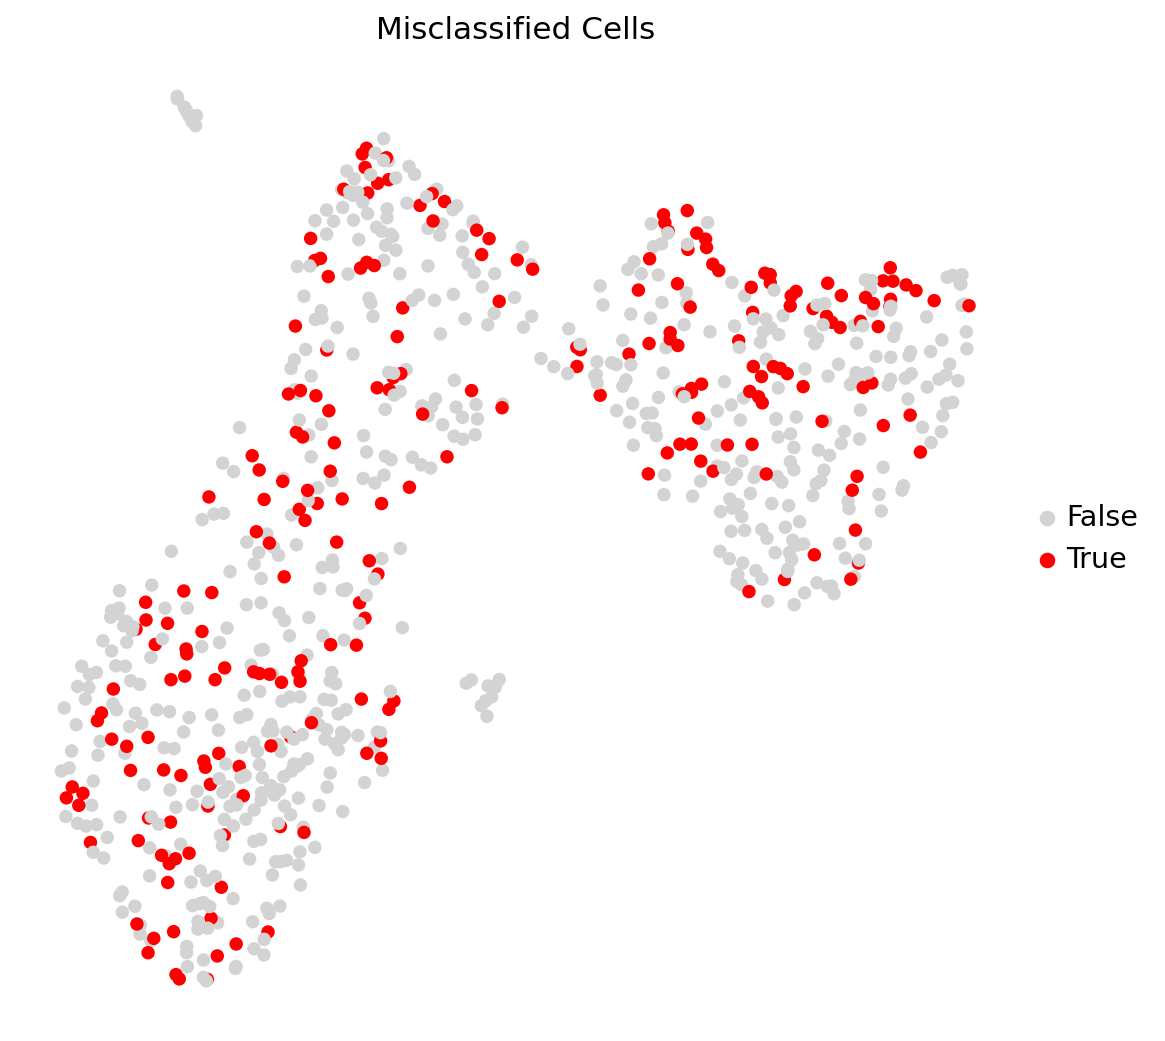

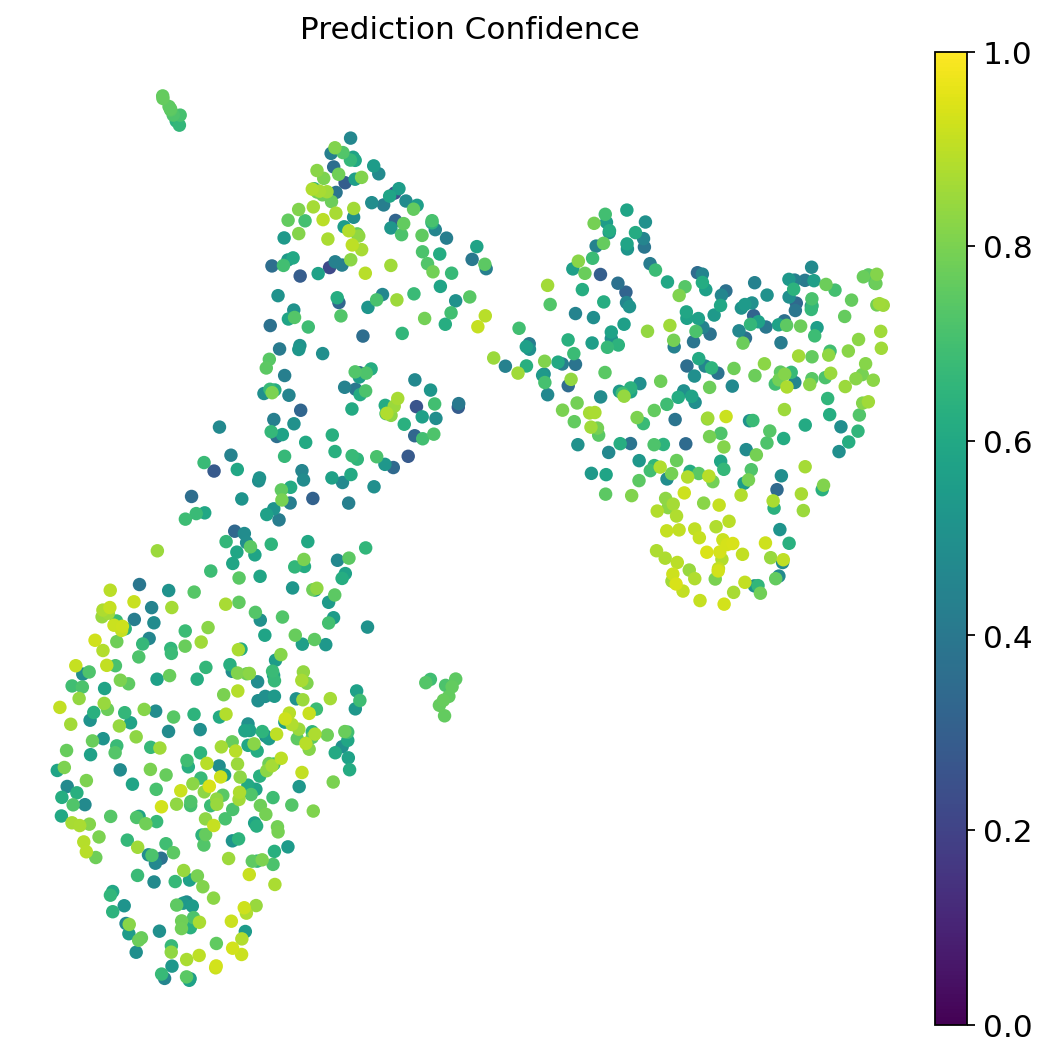

In [6]:
# --- Run Scenario 1 ---
run_scenario(scpred_model, query_adata_raw, threshold=0.0, scenario_name="ANALYSIS SCENARIO 1 (Paul15): NO THRESHOLD (0.0)", random_state=RANDOM_STATE)


## Run Scenario 2 (With Threshold)
Executes the second analysis scenario for the Paul15 dataset. It calls the `run_scenario` function with `threshold=0.6`. In this scenario, cells for which the maximum predicted probability falls below 0.6 are labeled as 'unassigned'. This demonstrates the impact of confidence filtering on improving the reliability of assigned predictions, albeit at the cost of reduced coverage. The cell concludes the Paul15 analysis.



======== ANALYSIS SCENARIO 2 (Paul15): WITH THRESHOLD (0.6) ========
AnnData object check passed.
--- Starting ScPred Prediction ---
  `perform_preprocessing` is True. Performing full internal preprocessing of query data...
Applying initial preprocessing (filter, normalize, log1p)...
Initial preprocessing finished.
Aligning 3438 genes to 3000 reference genes...
  Note: 11 reference genes were missing in the query data and filled with zeros.
  Note: 449 query genes were not in the reference and were dropped.
Genes aligned. New shape: (819, 3000)
Transforming data with fitted StandardScaler...
Data scaled.
Projecting data onto existing PCA space...
Projection finished.
Predicting cell types...
Applied probability thresholding: 283 cells set to 'unassigned' (threshold=0.6).
Prediction finished.
Projected PCs stored in query_adata.obsm['X_scpred_pca']. Cells filtered during preprocessing will have NaN values.
--- ScPred Prediction Complete ---

Query Data with Predictions (first 5 rows):

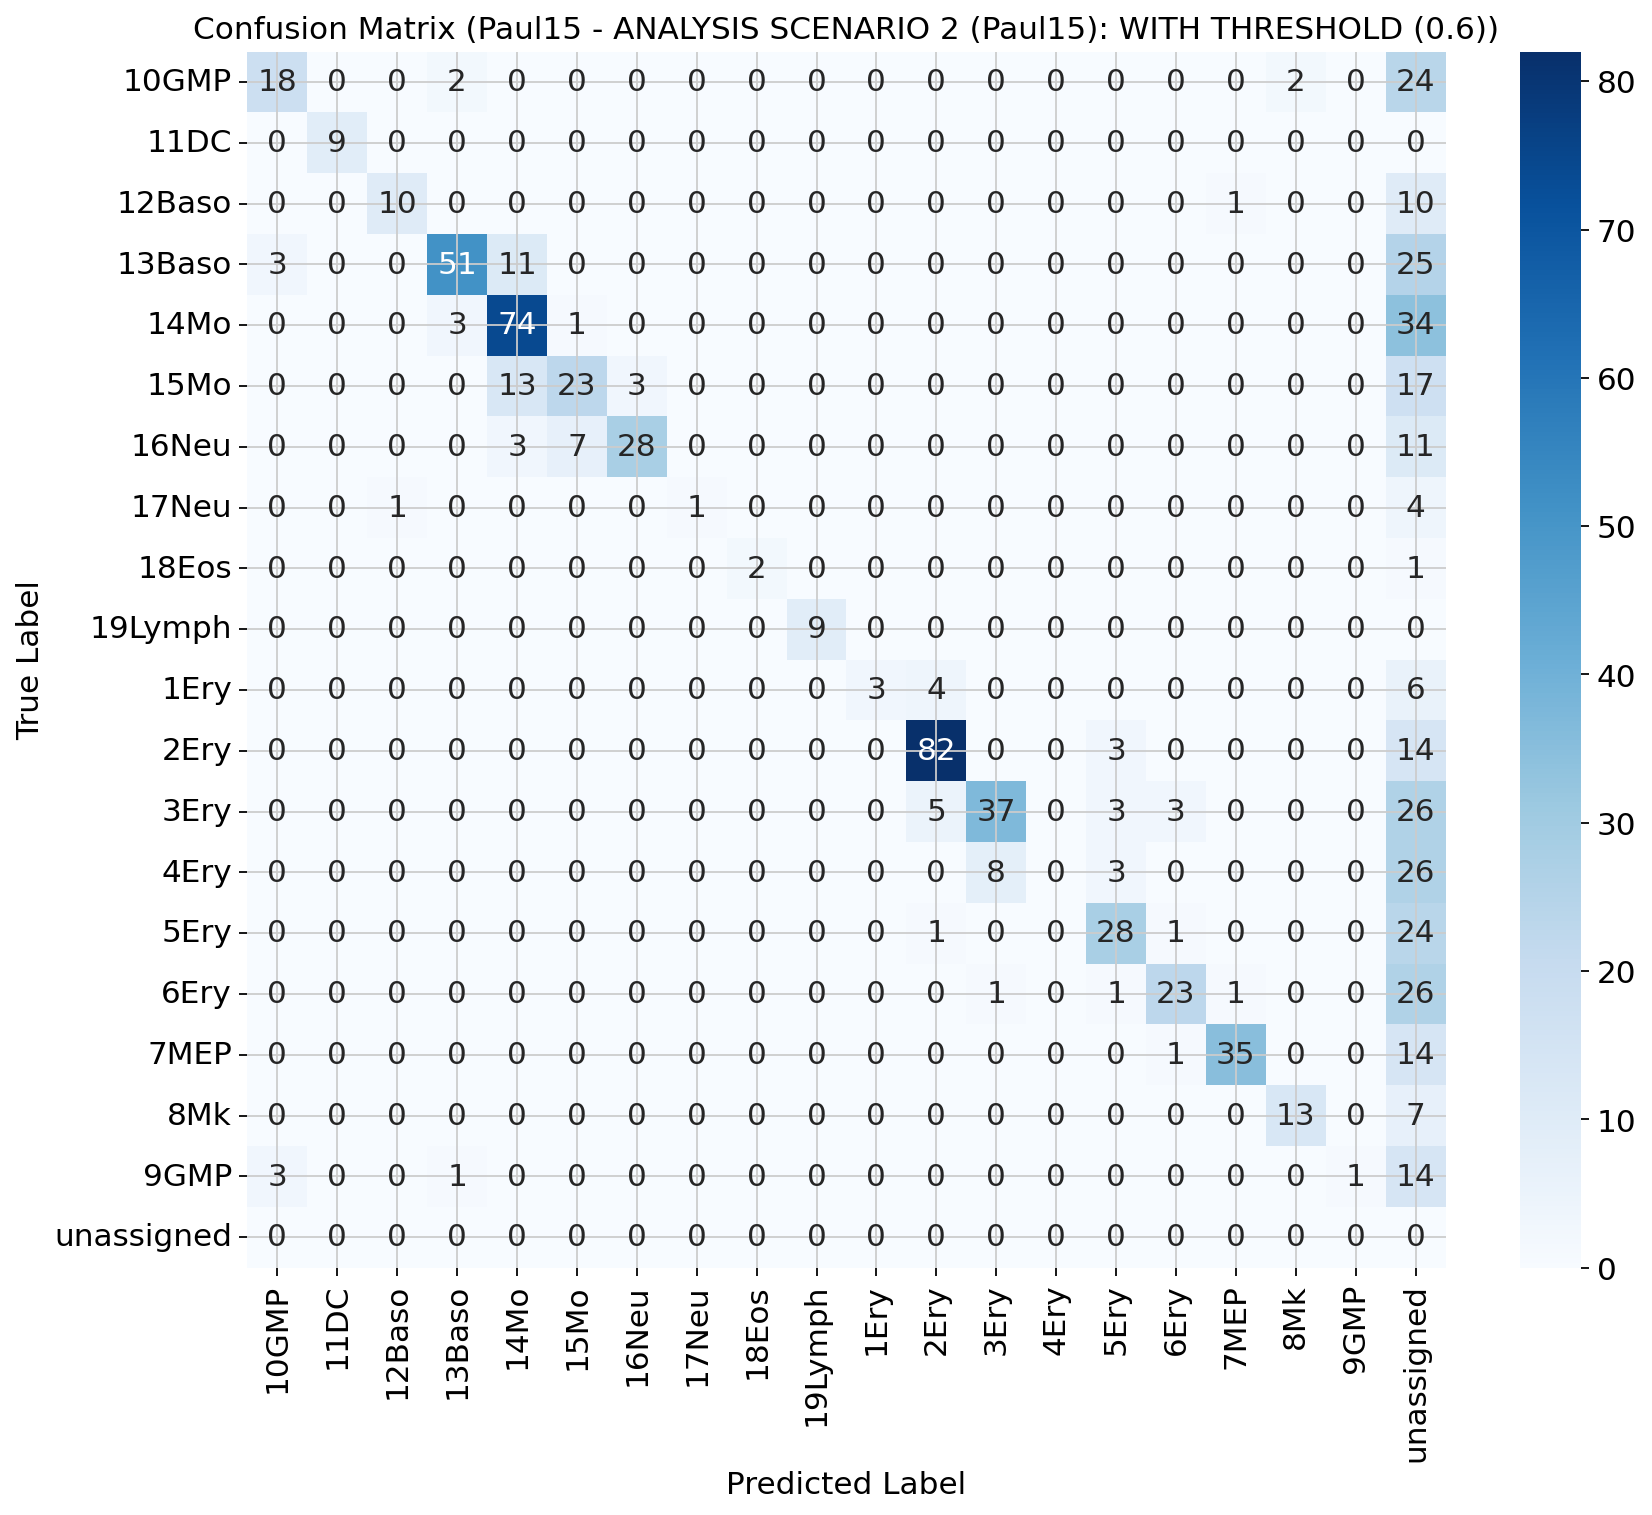


--- Per-Class ROC AUC (ANALYSIS SCENARIO 2 (Paul15): WITH THRESHOLD (0.6)) ---


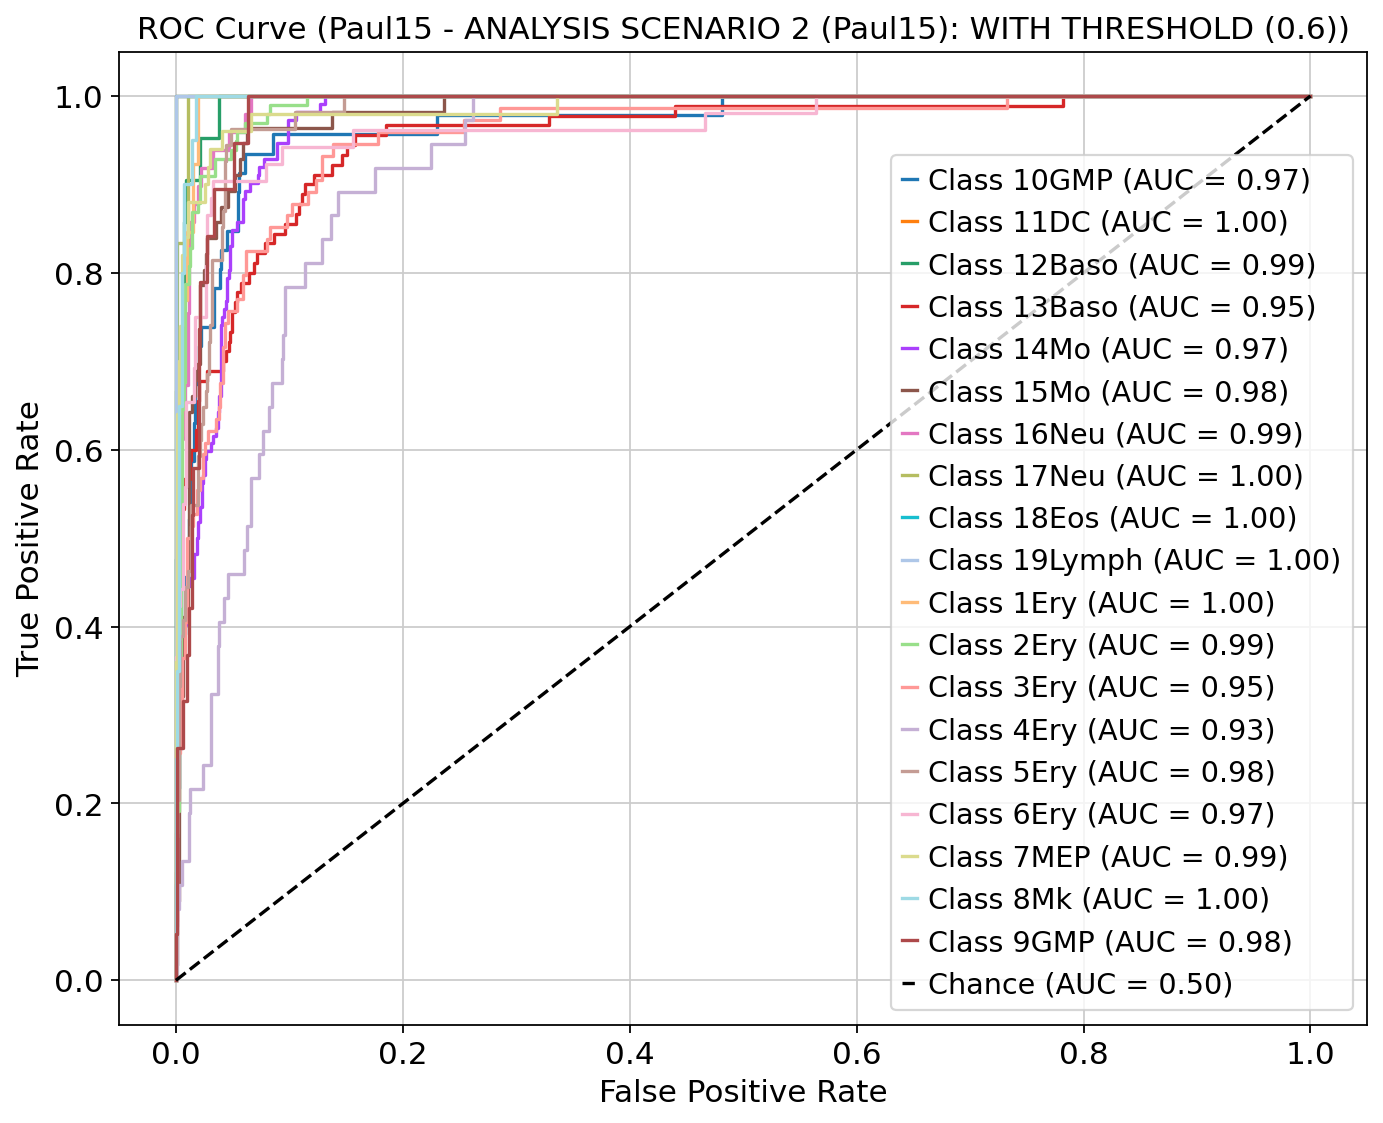


--- Distribution of Prediction Probabilities (Per True Cell Type, ANALYSIS SCENARIO 2 (Paul15): WITH THRESHOLD (0.6)) ---


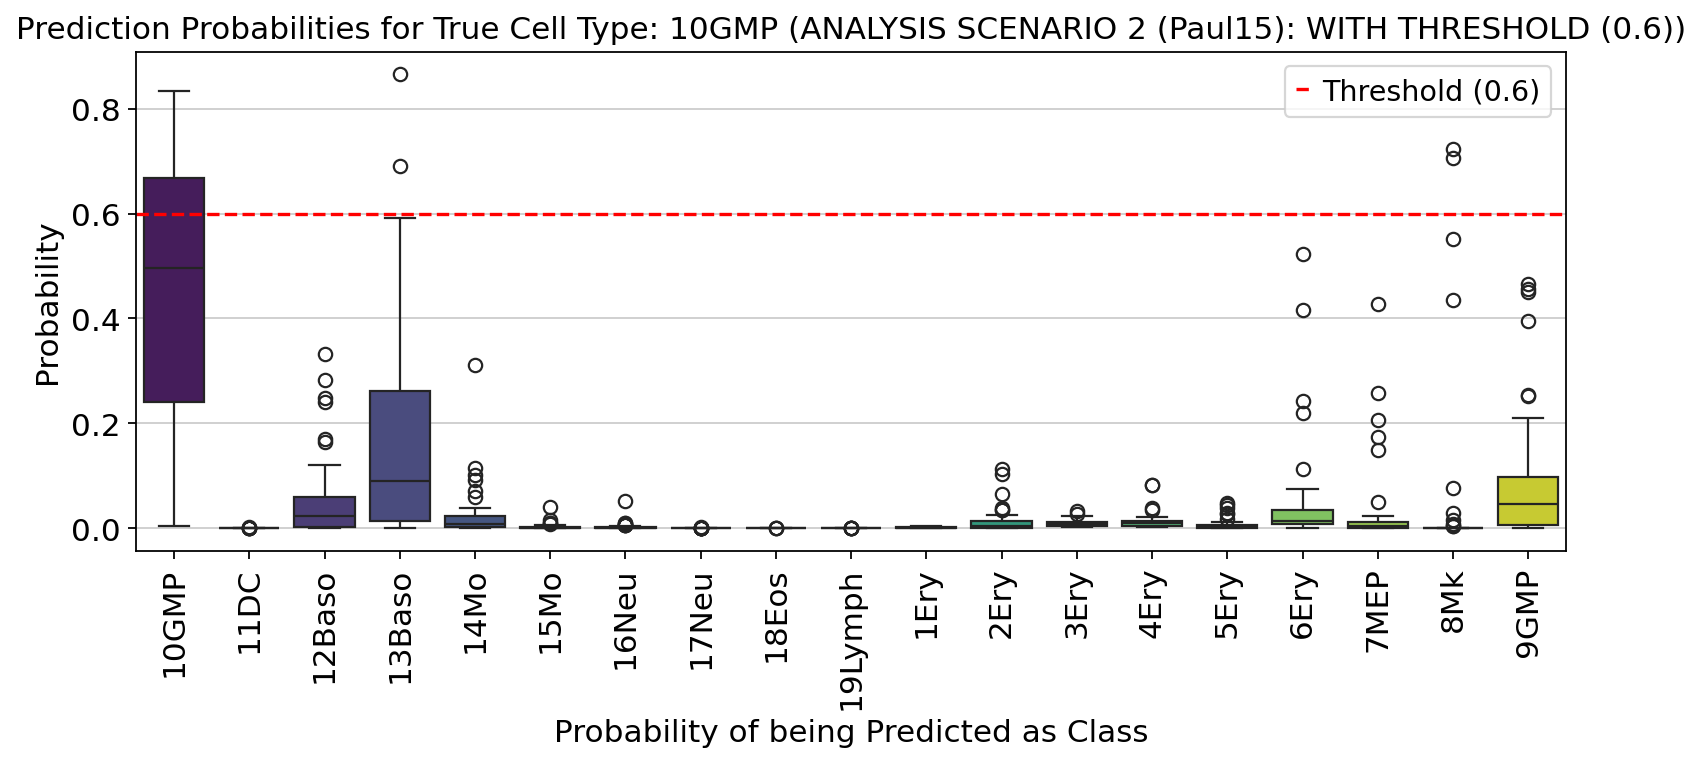

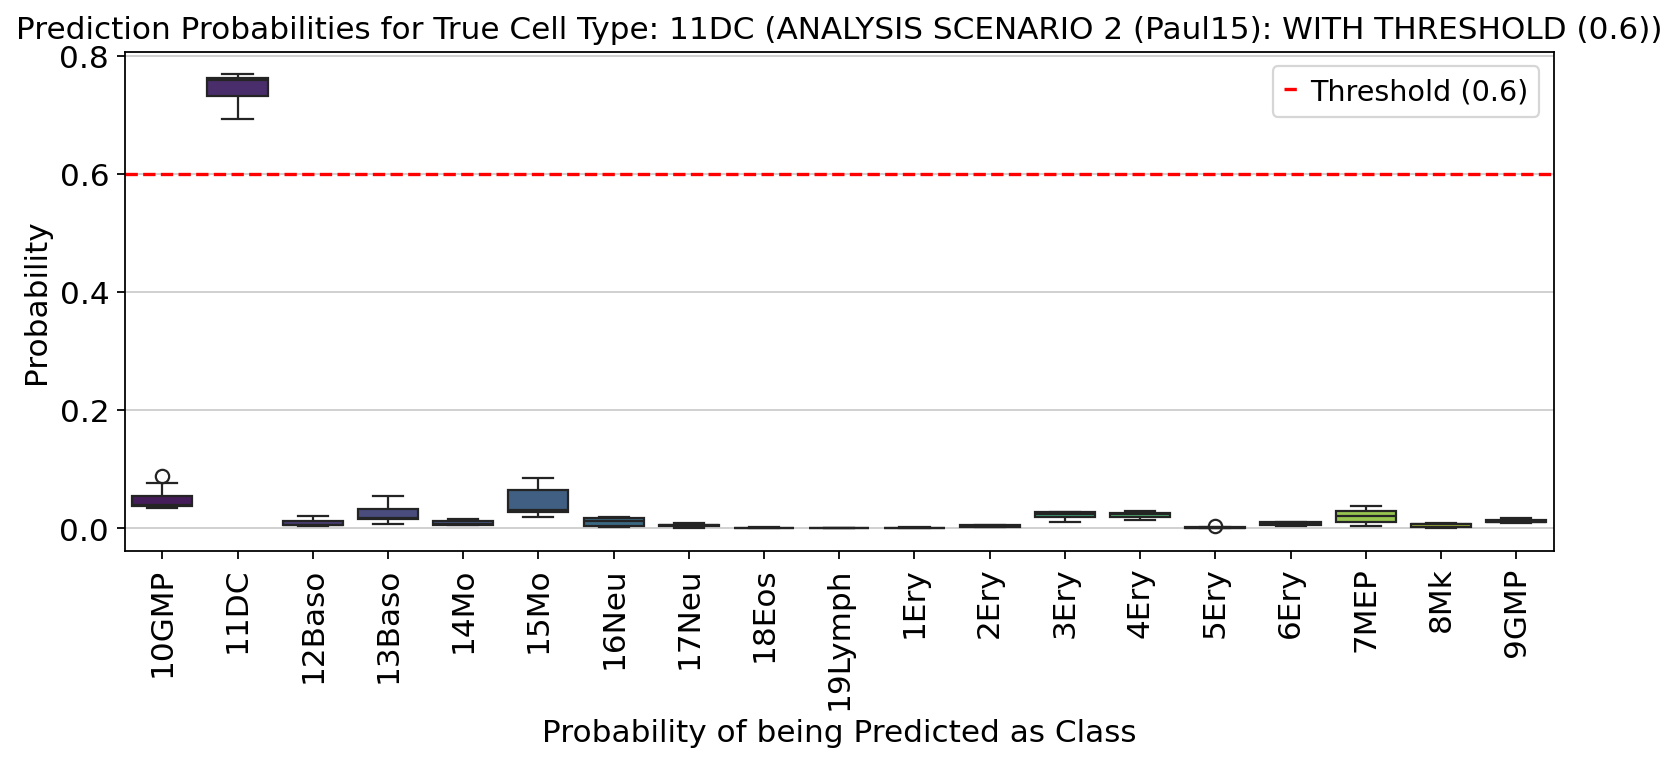

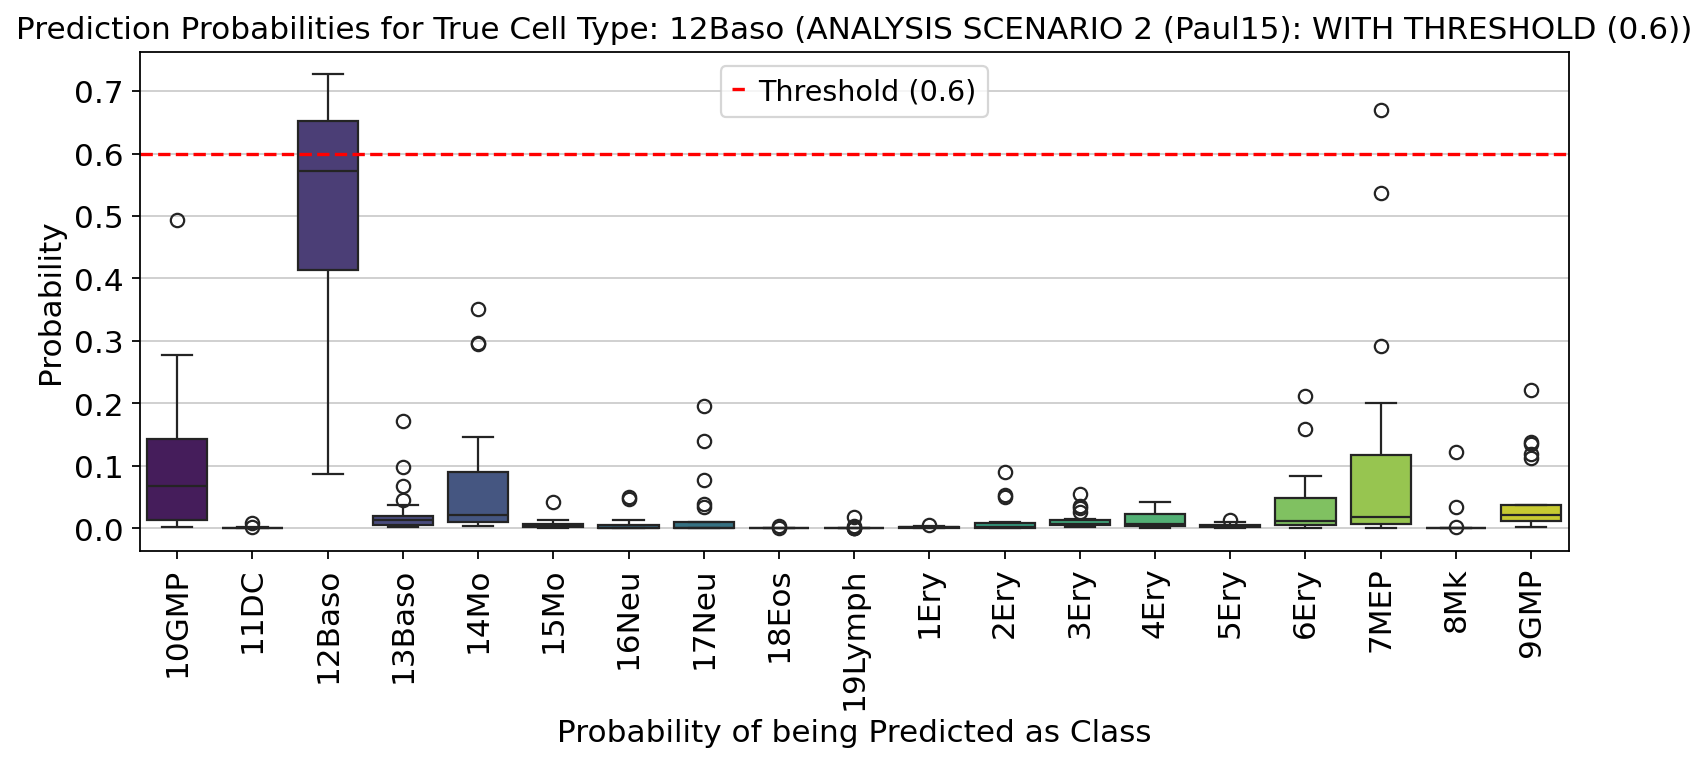

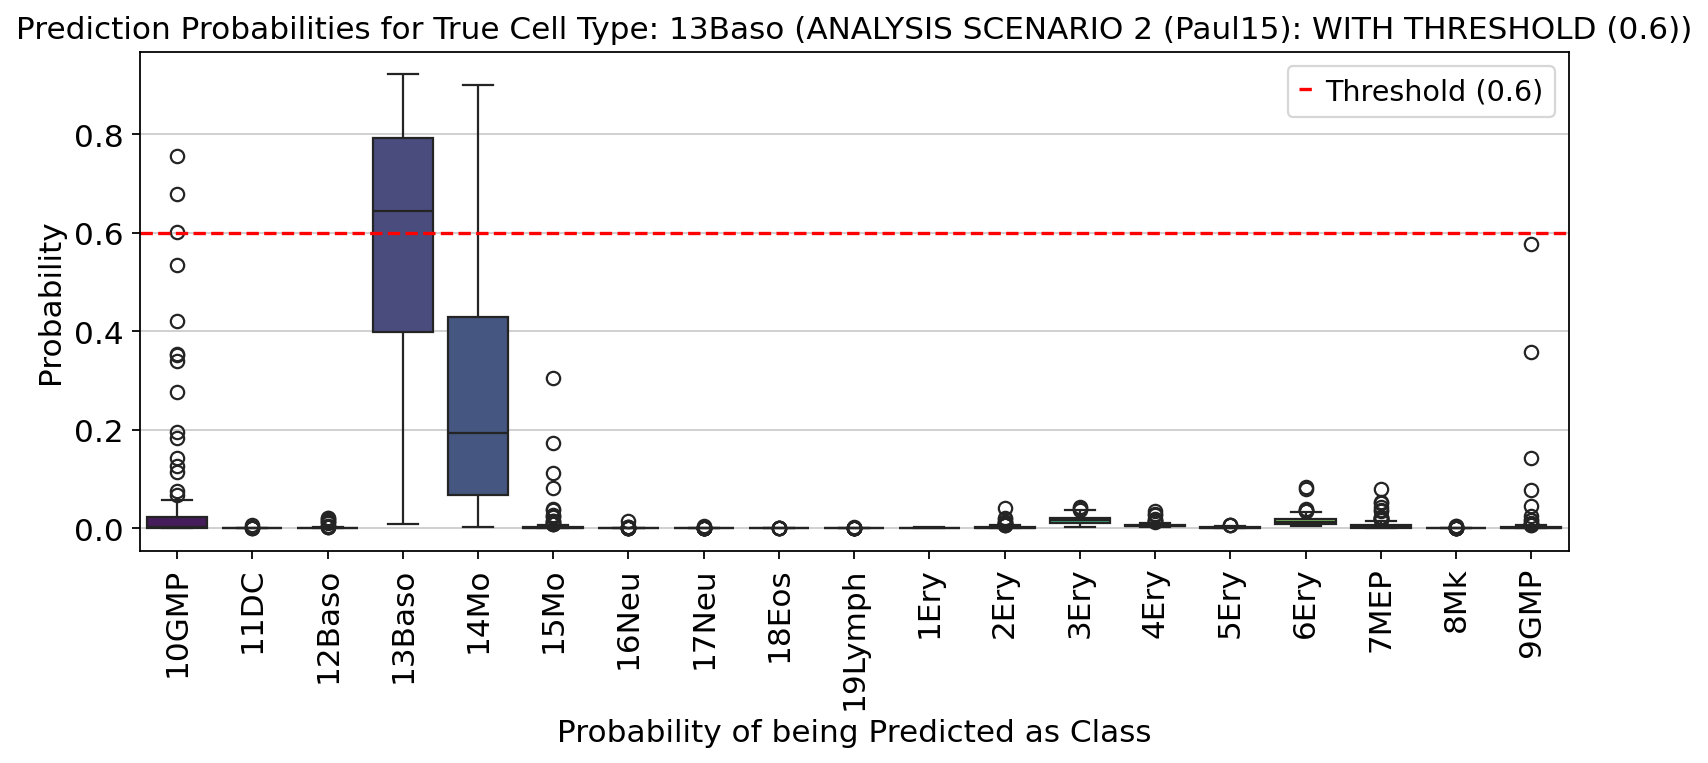

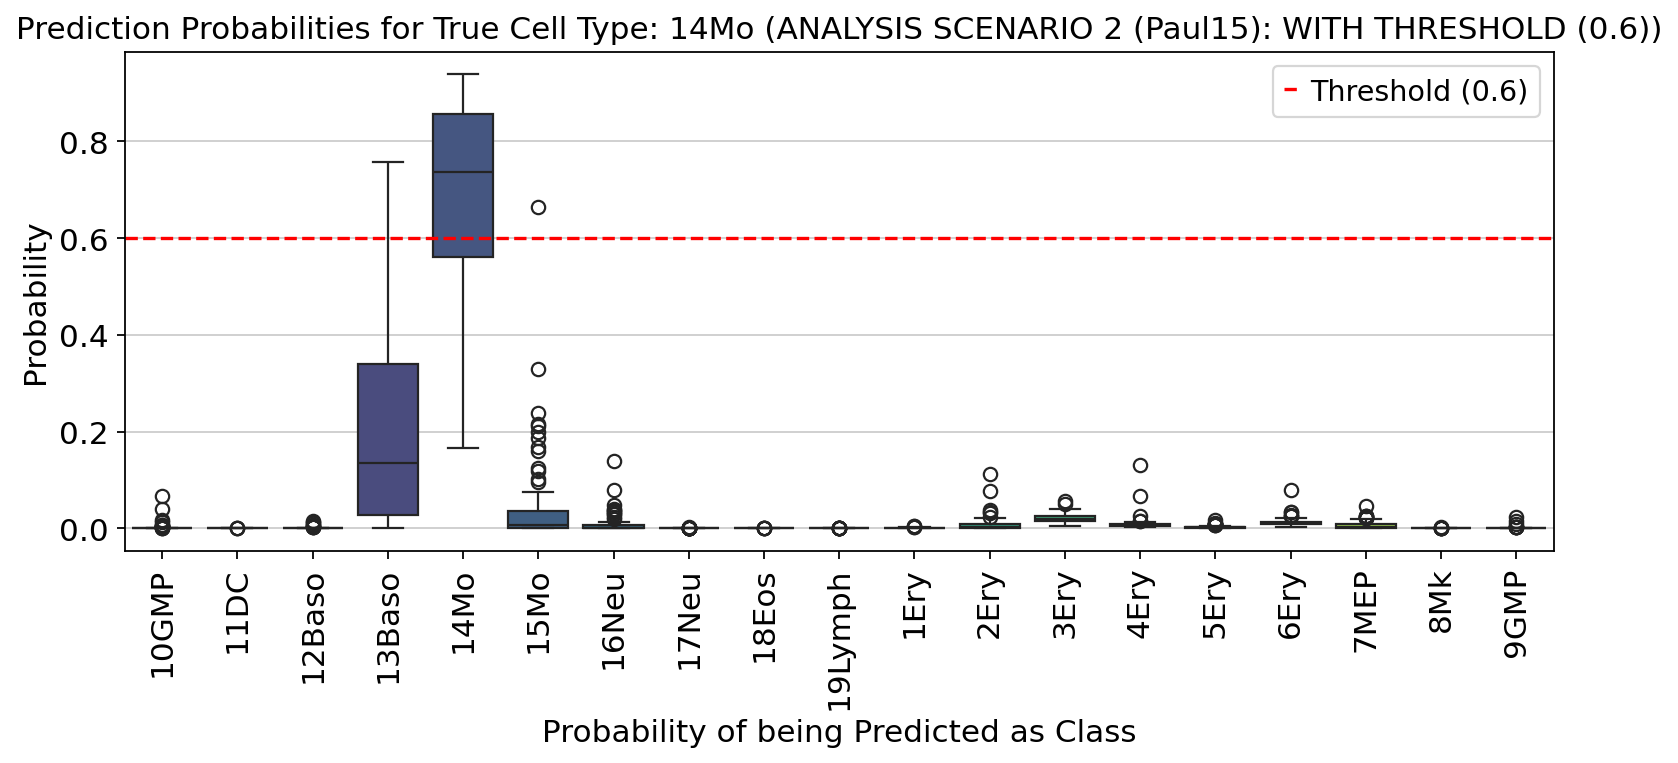

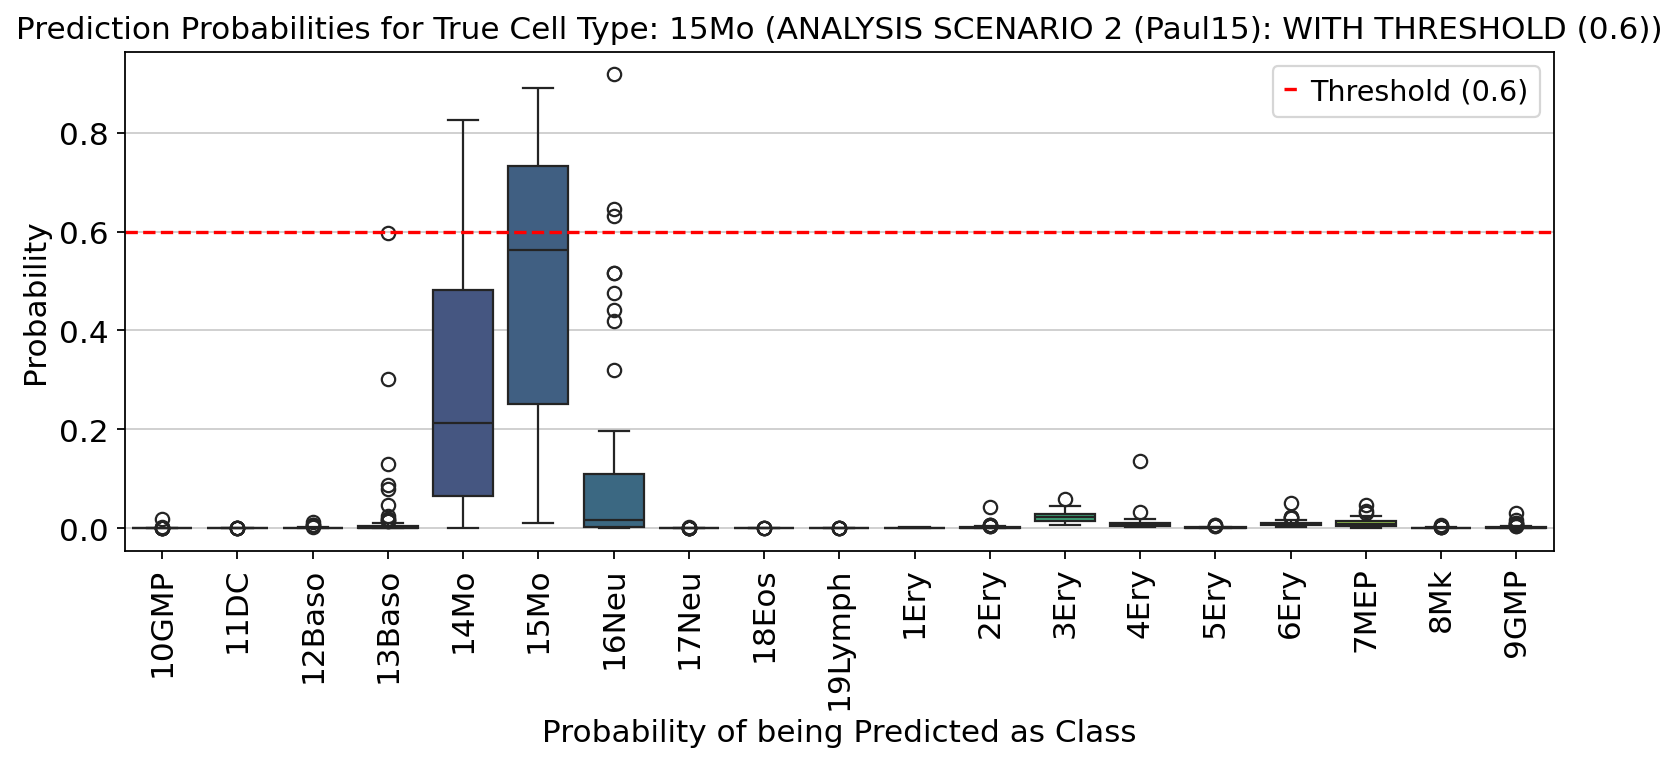

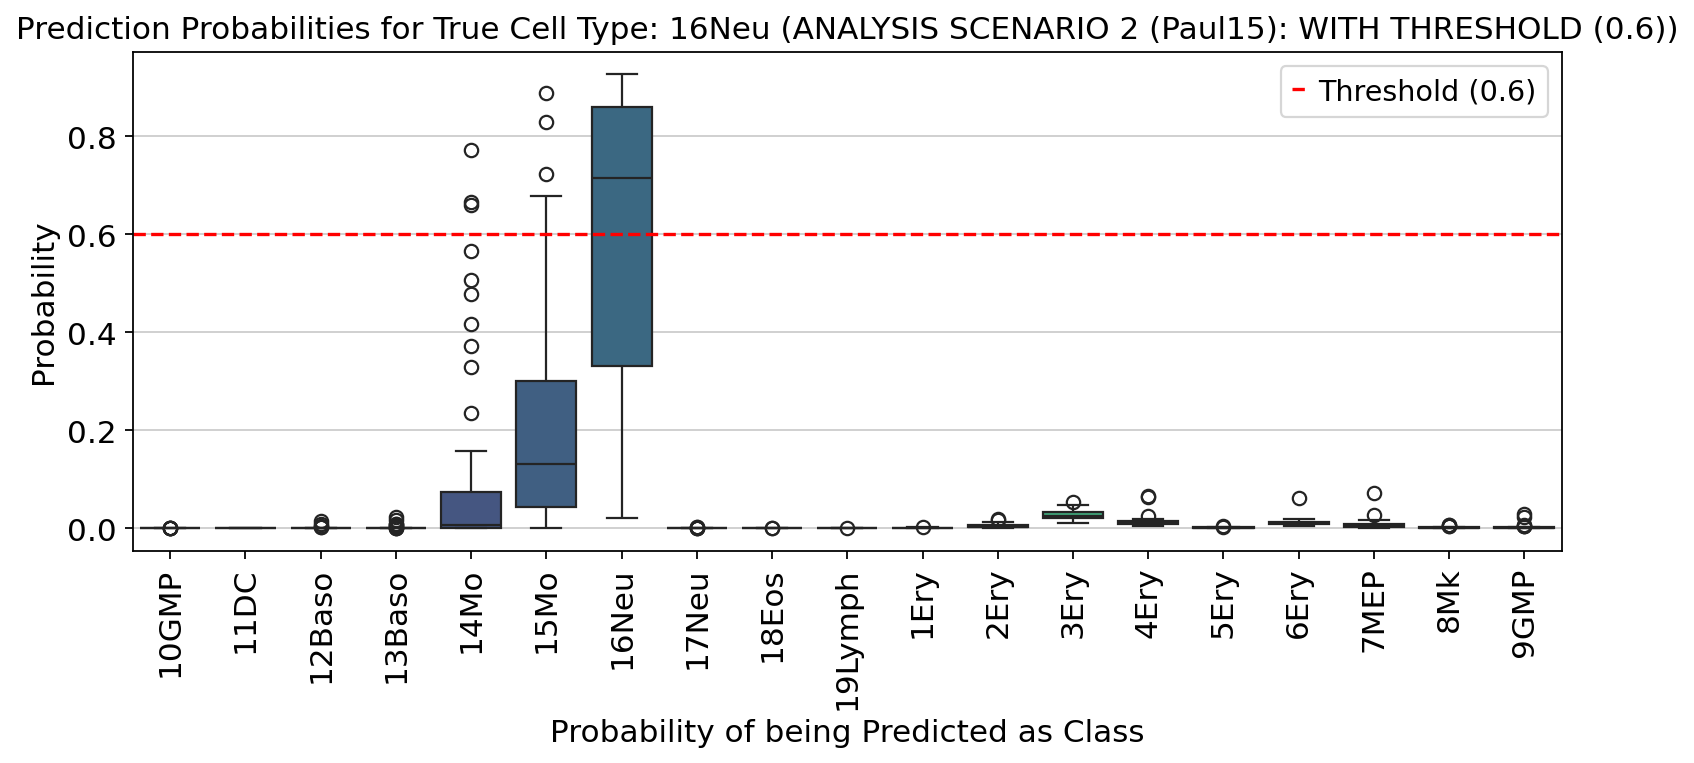

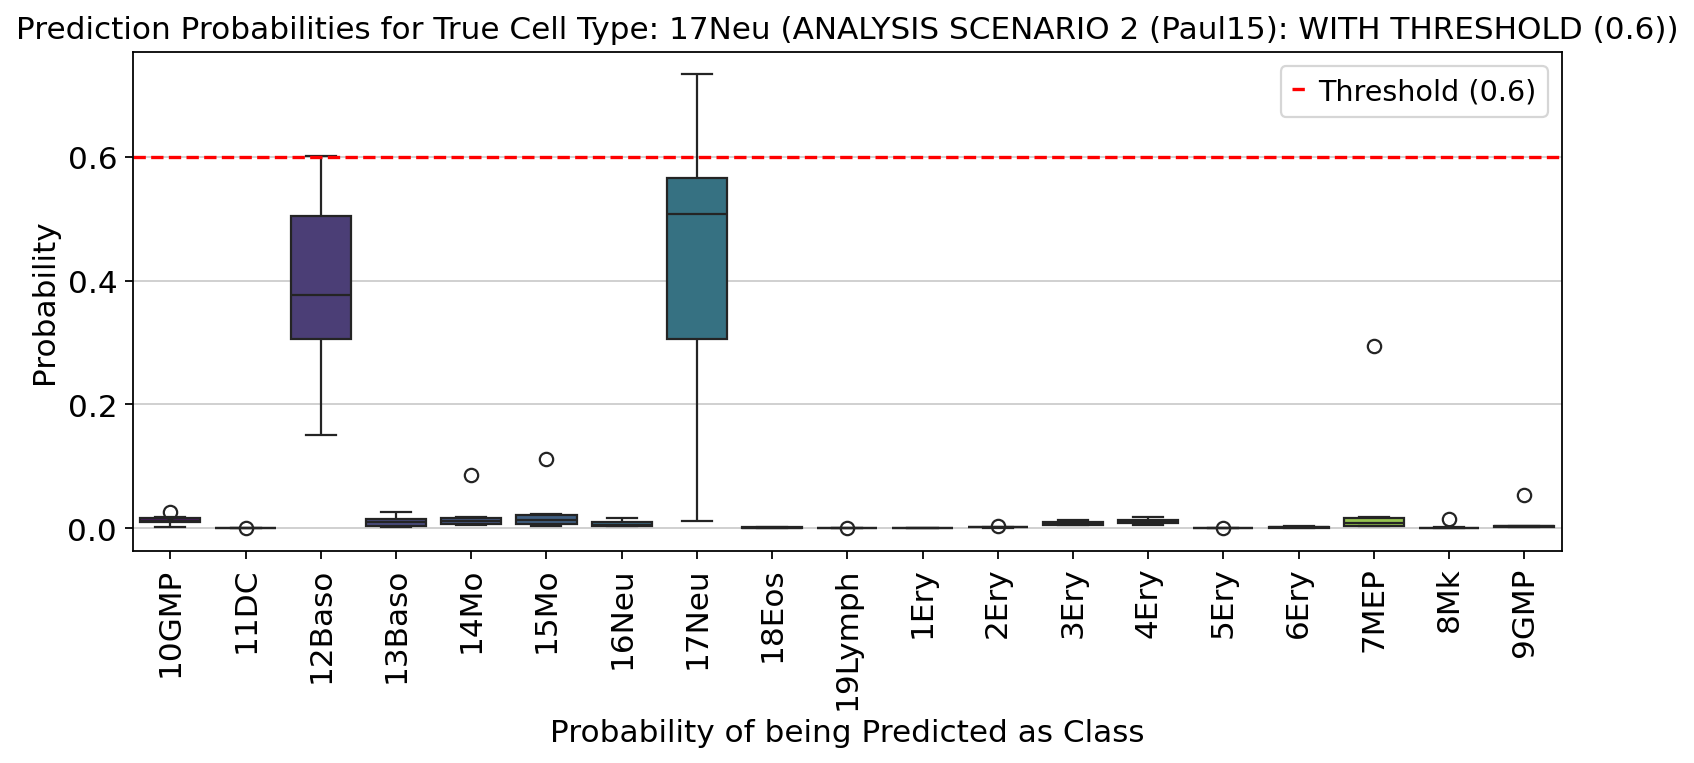

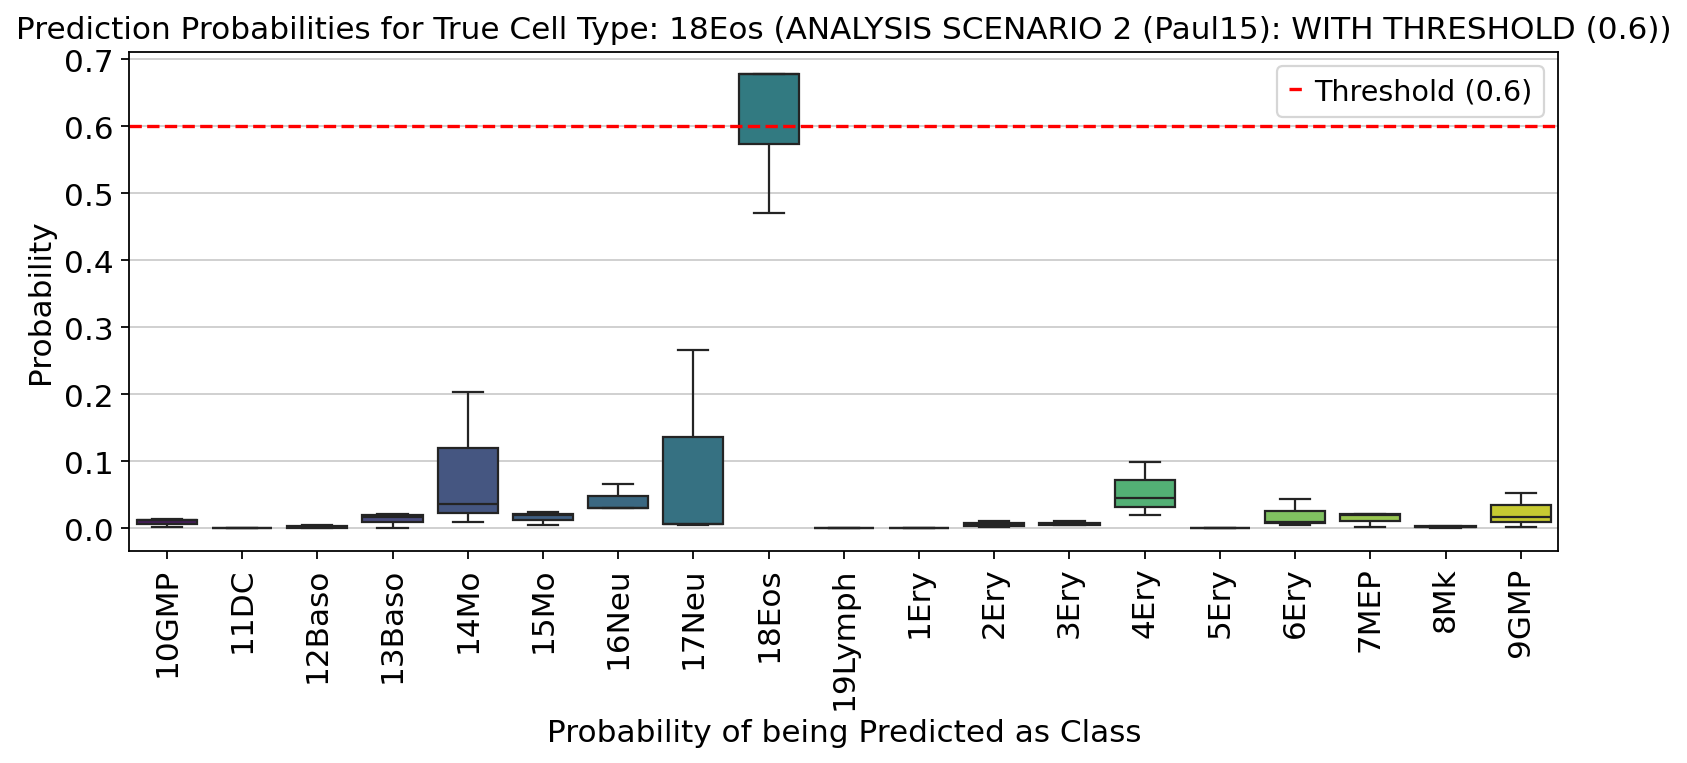

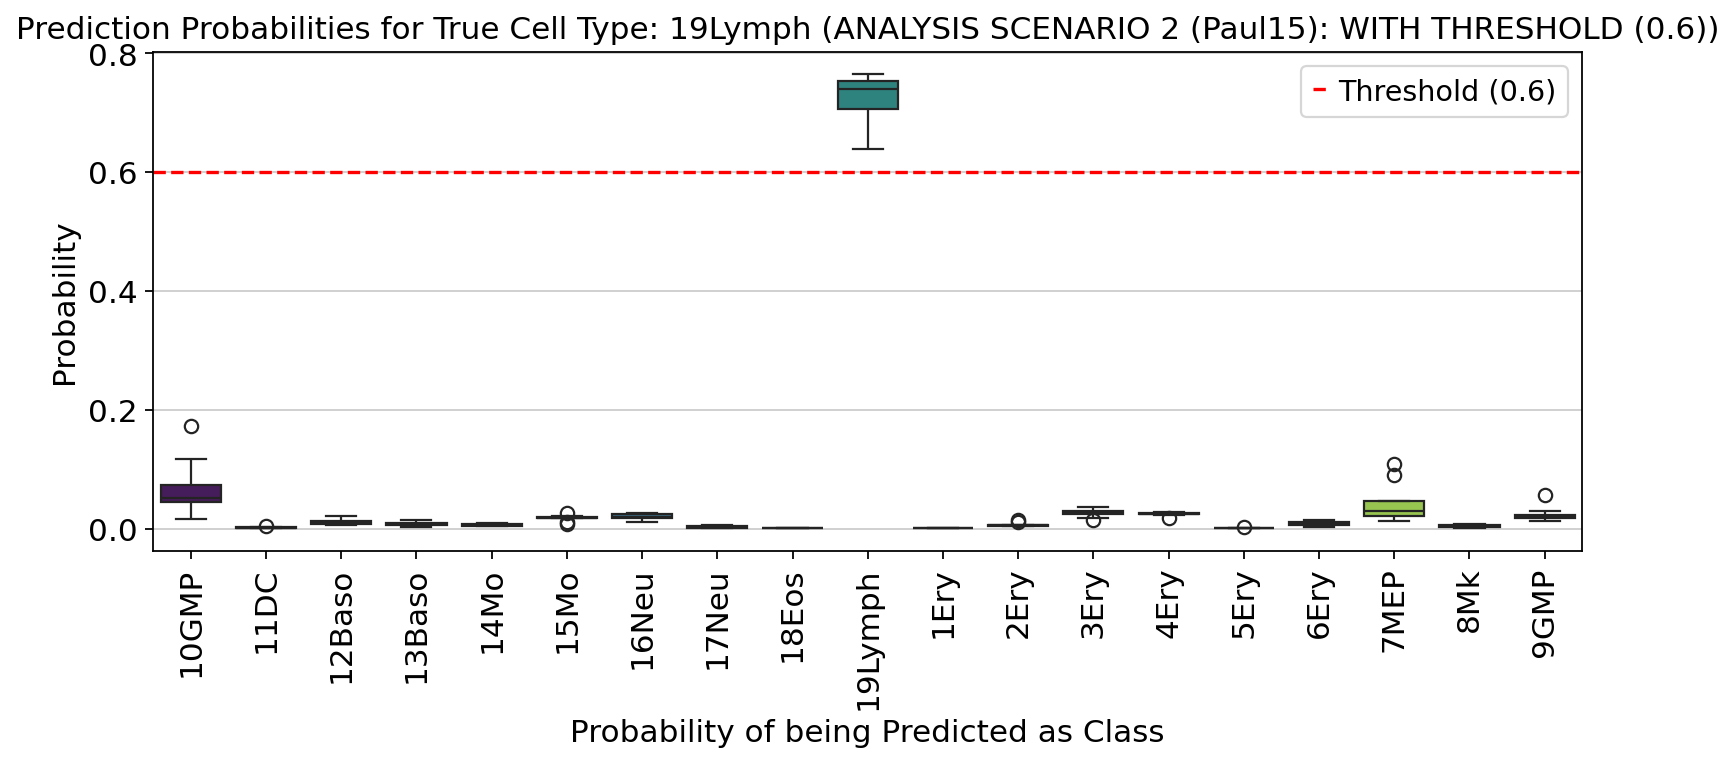

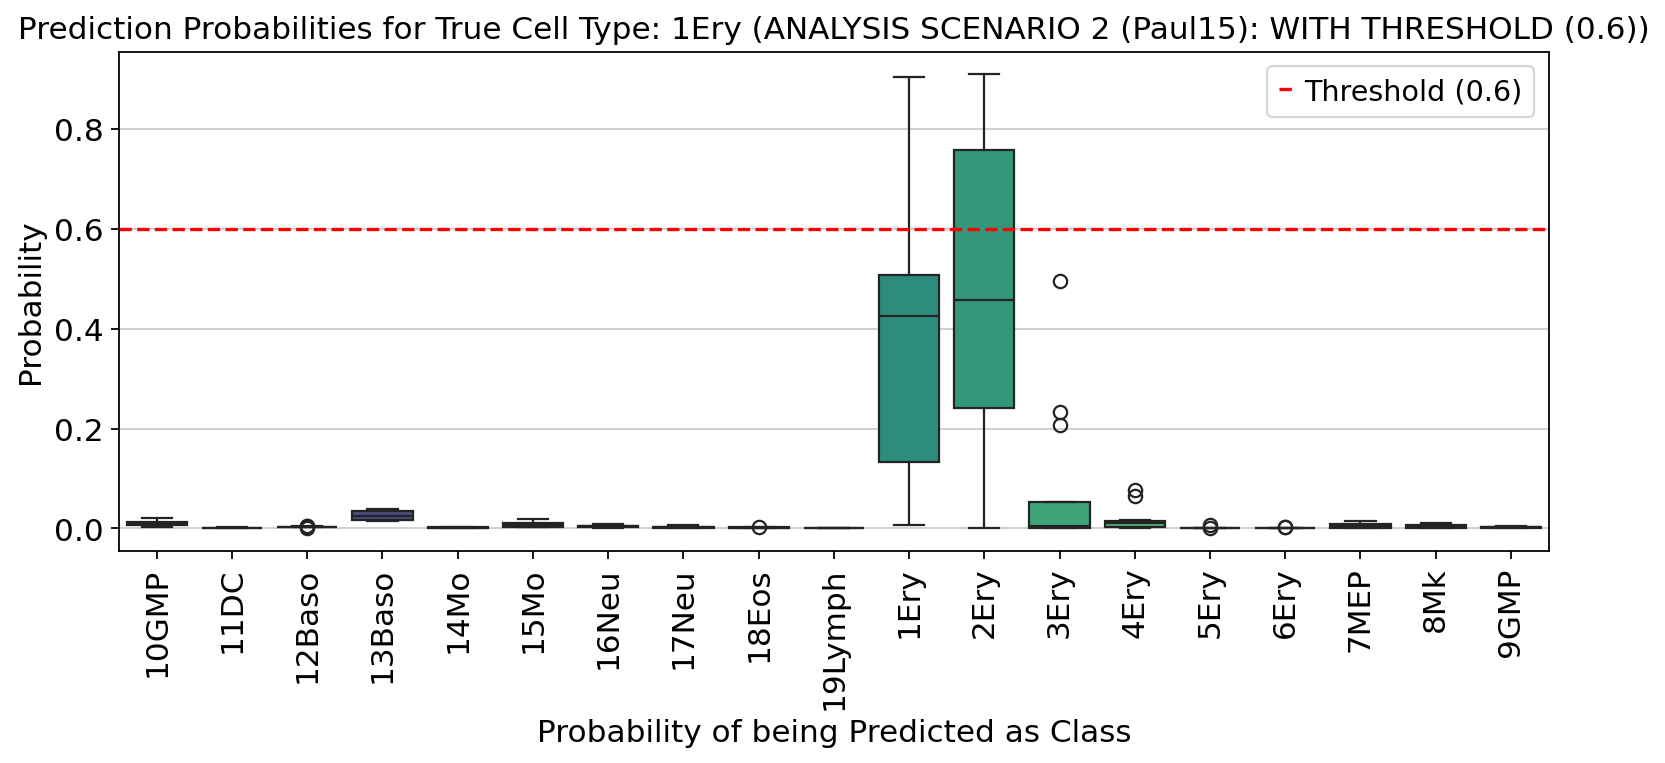

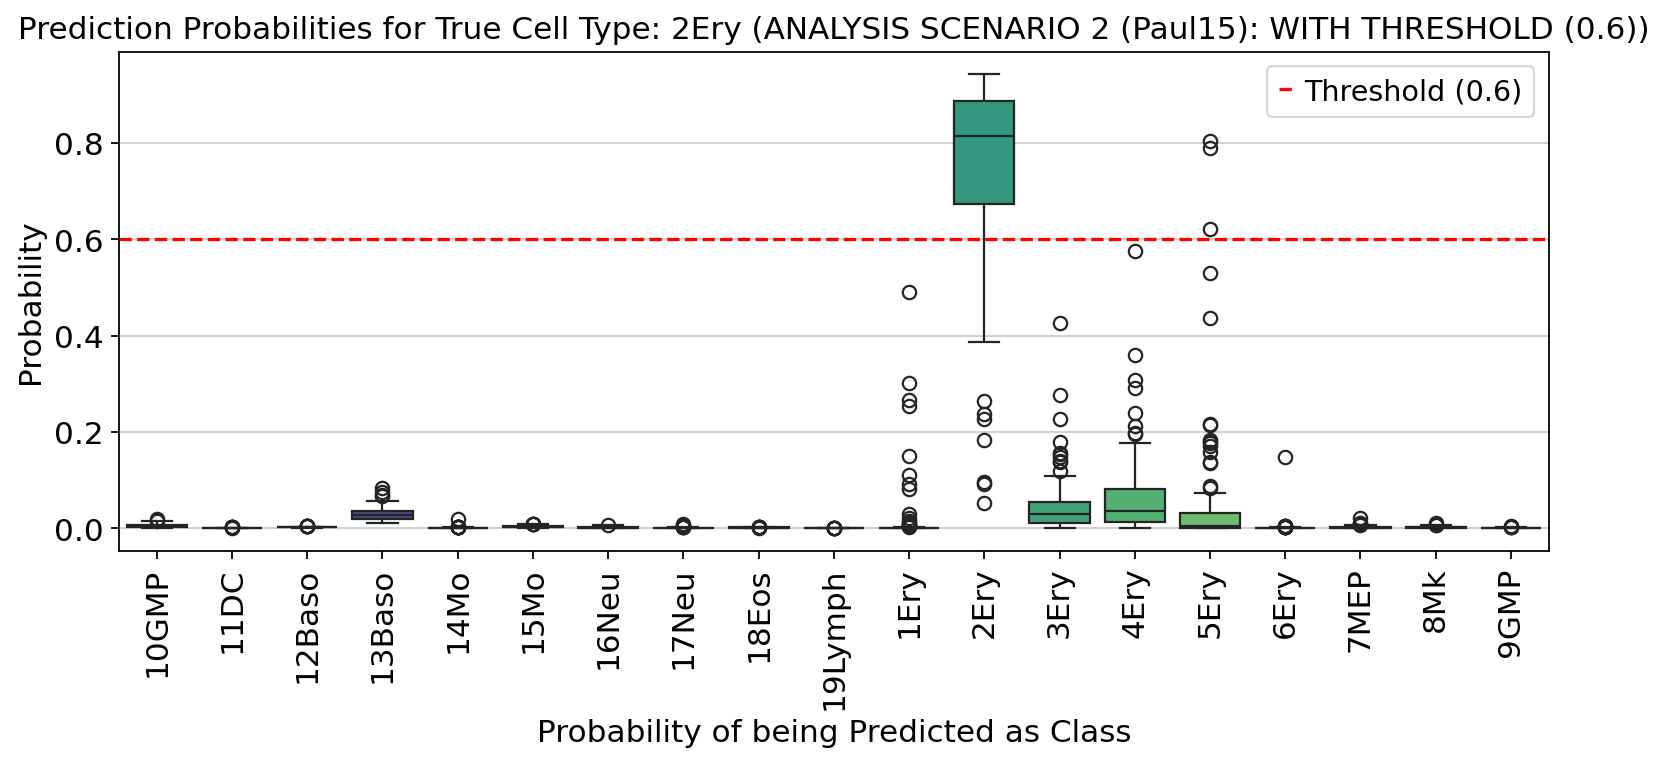

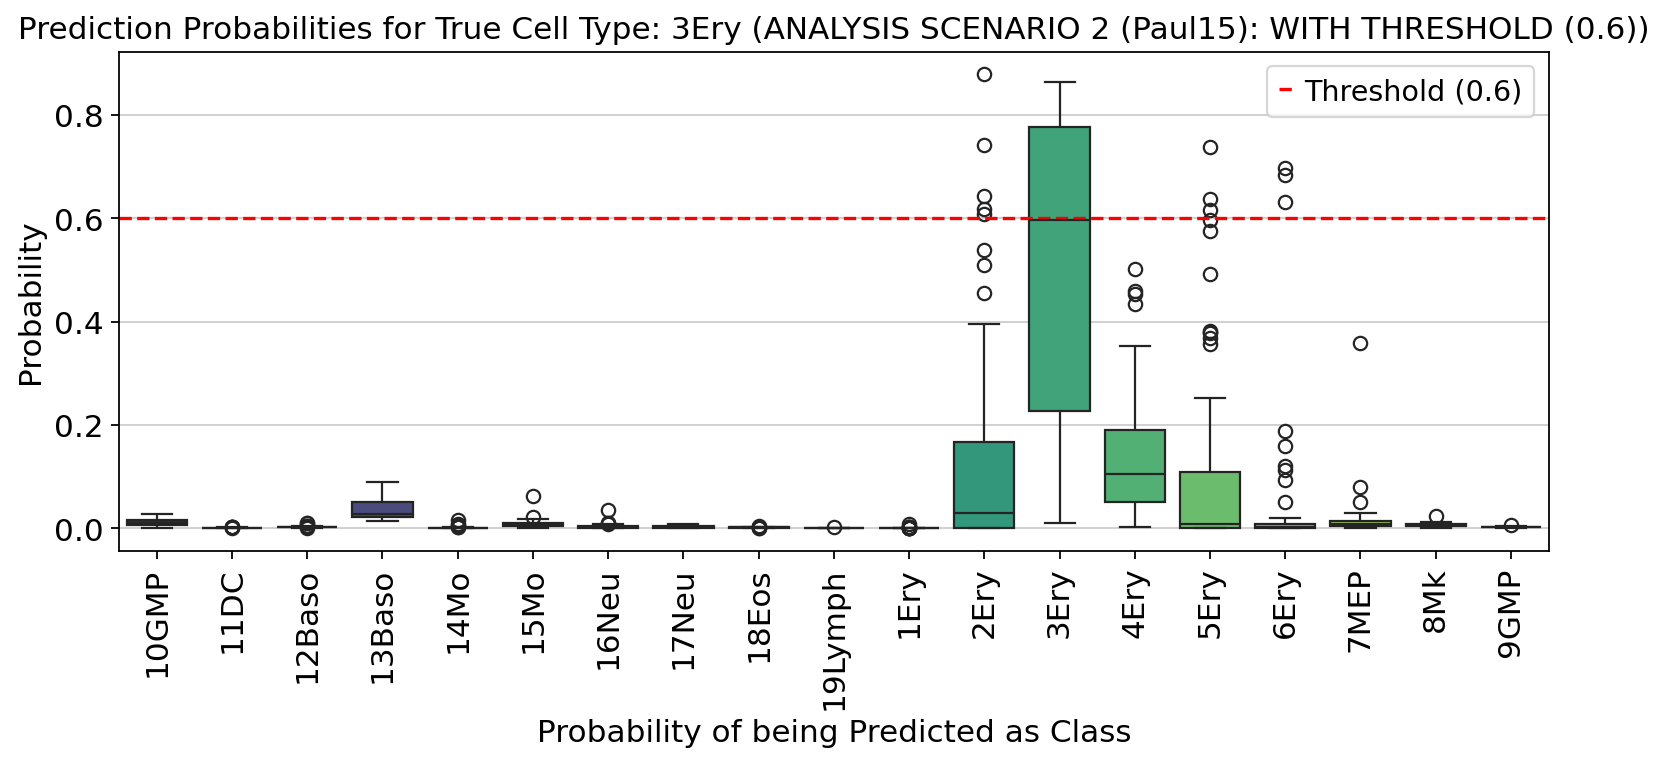

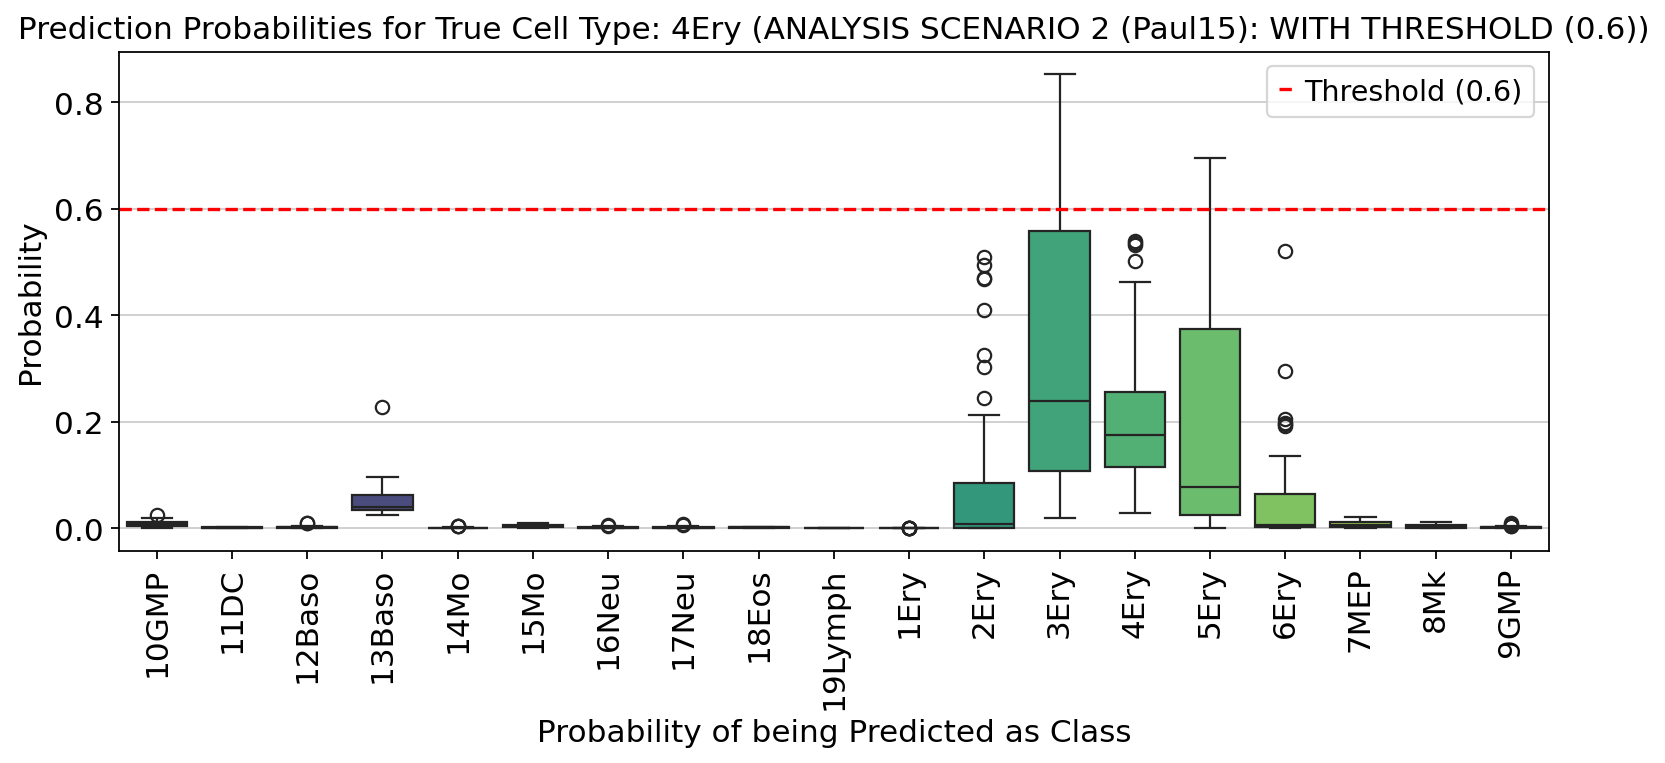

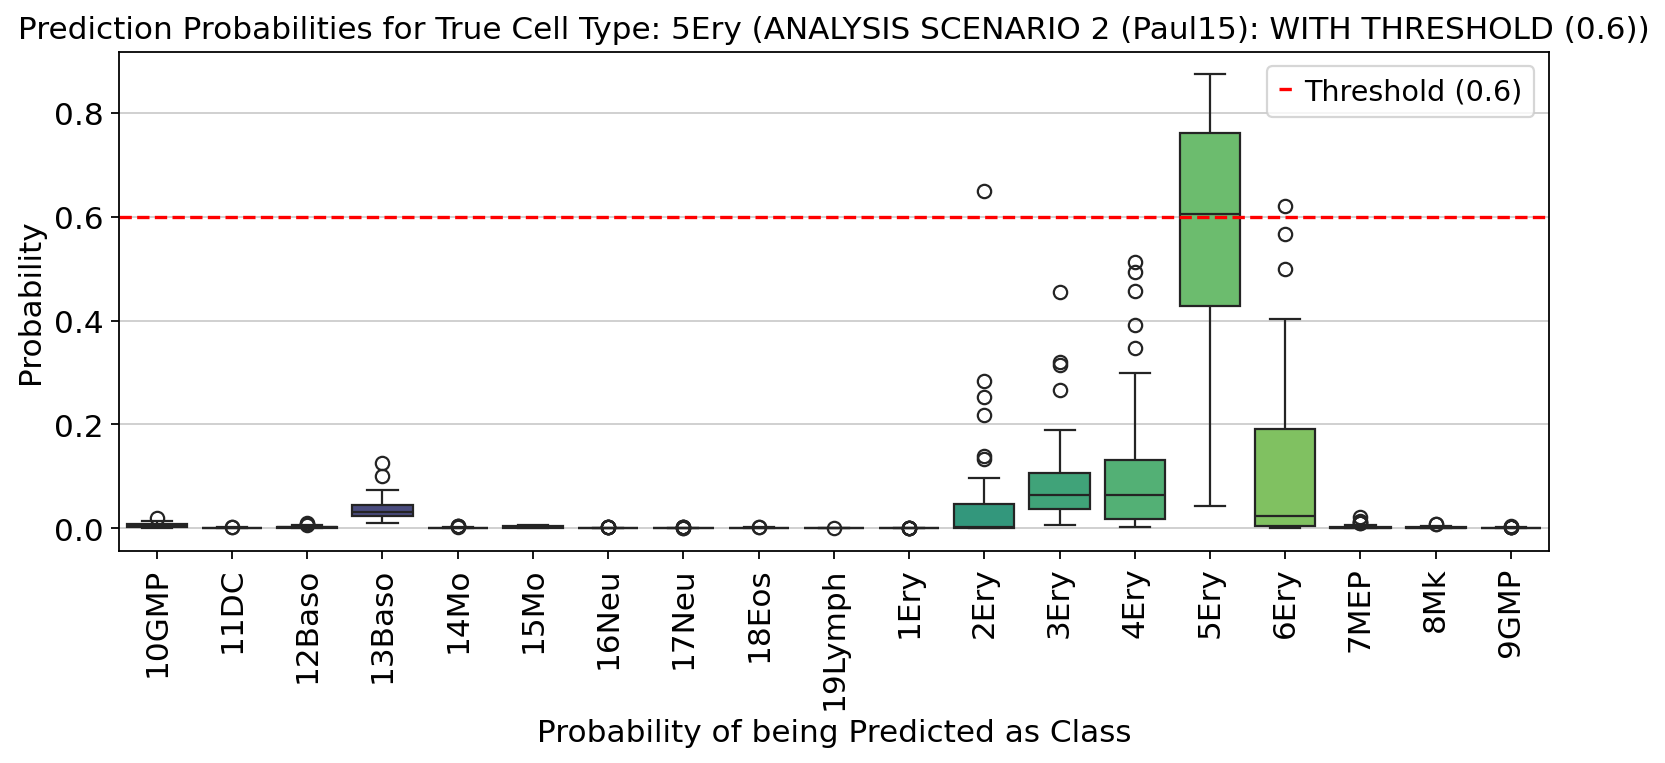

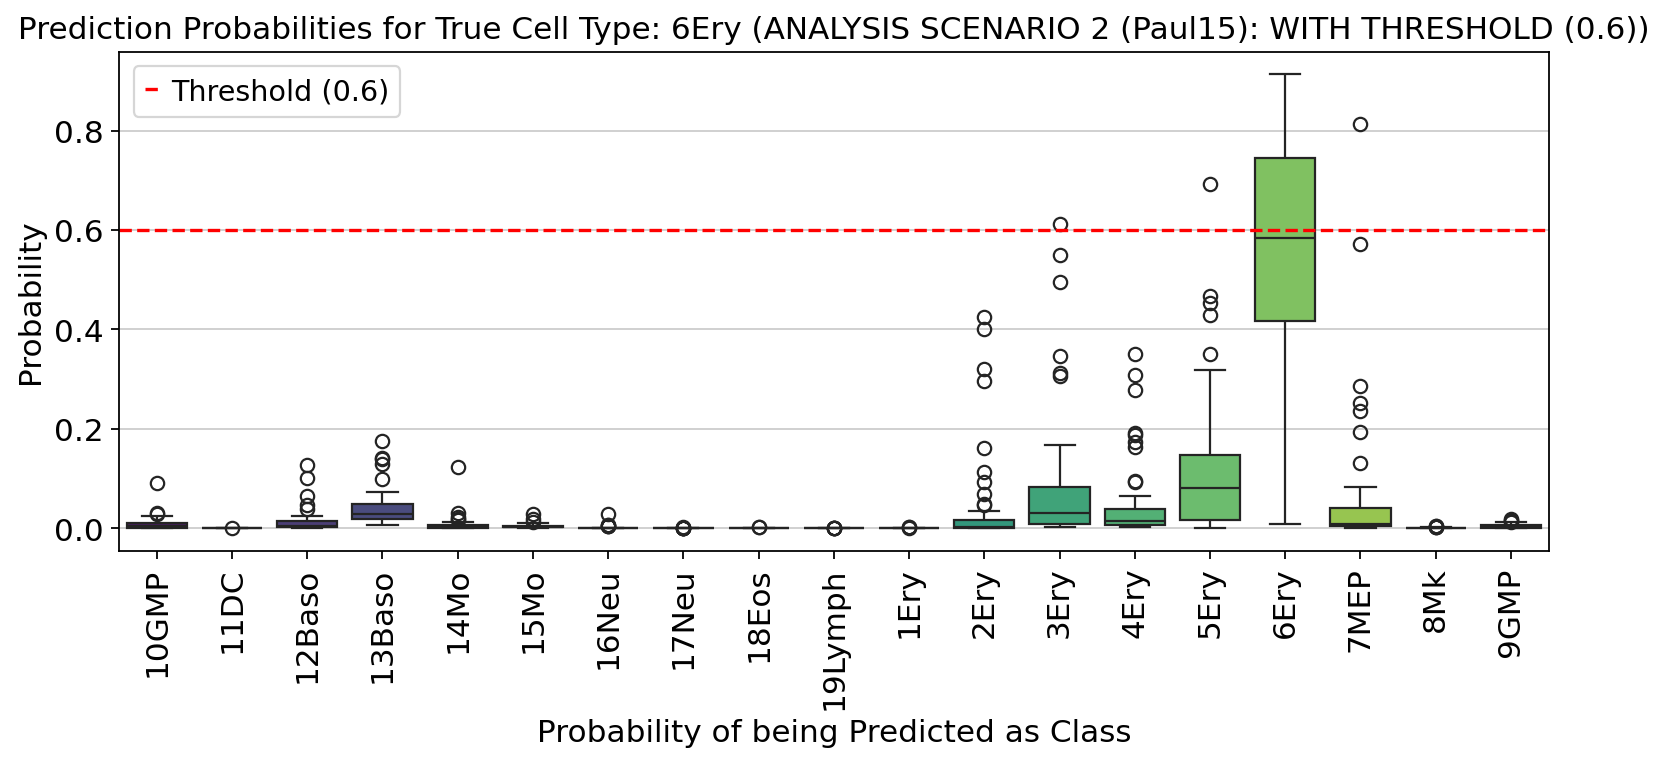

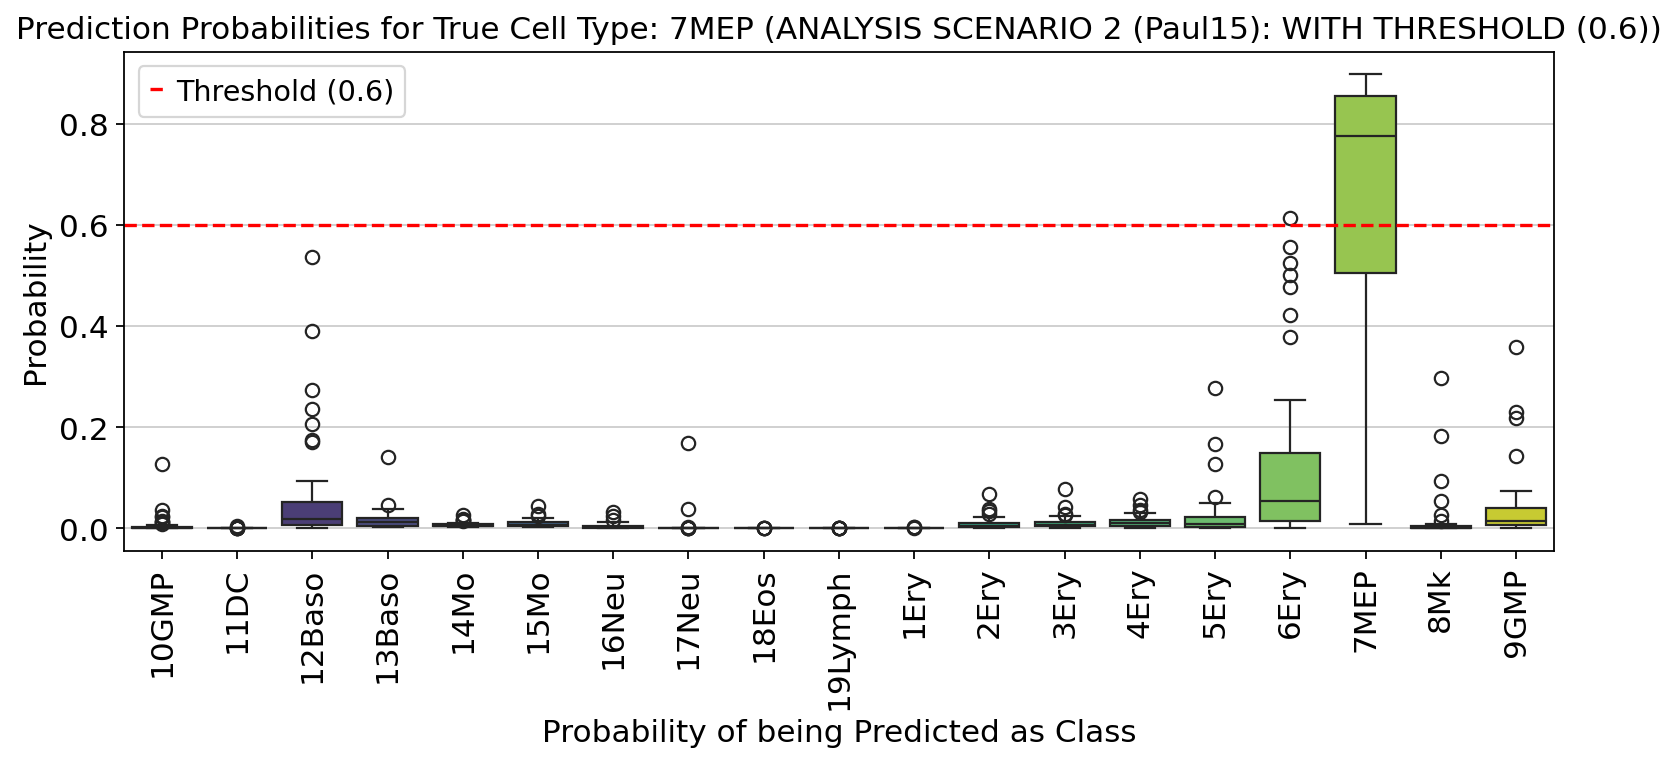

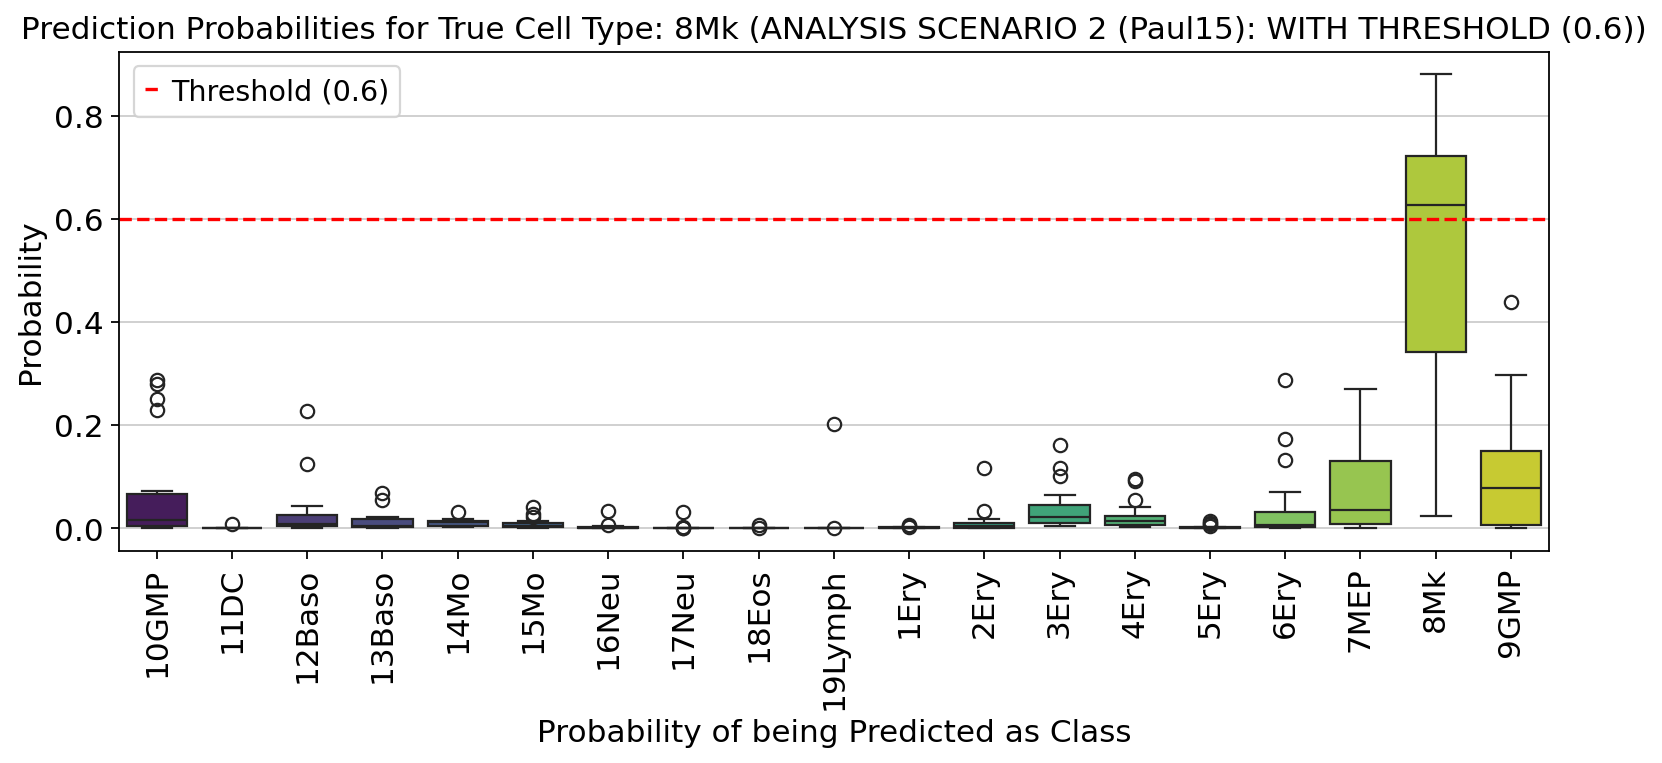

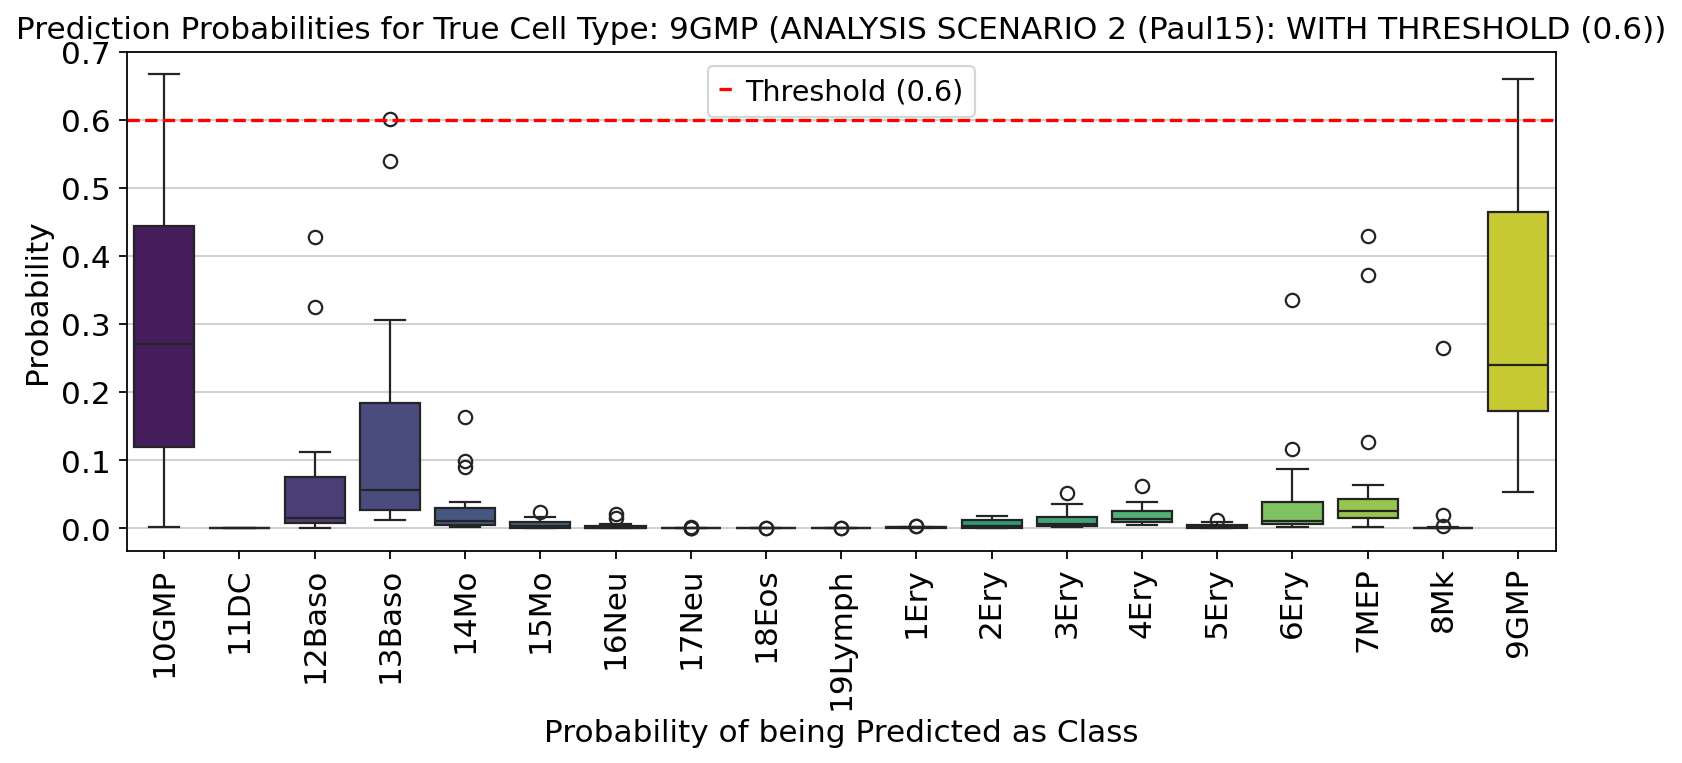


--- Max Prediction Probability per True Cell Type (ANALYSIS SCENARIO 2 (Paul15): WITH THRESHOLD (0.6)) ---


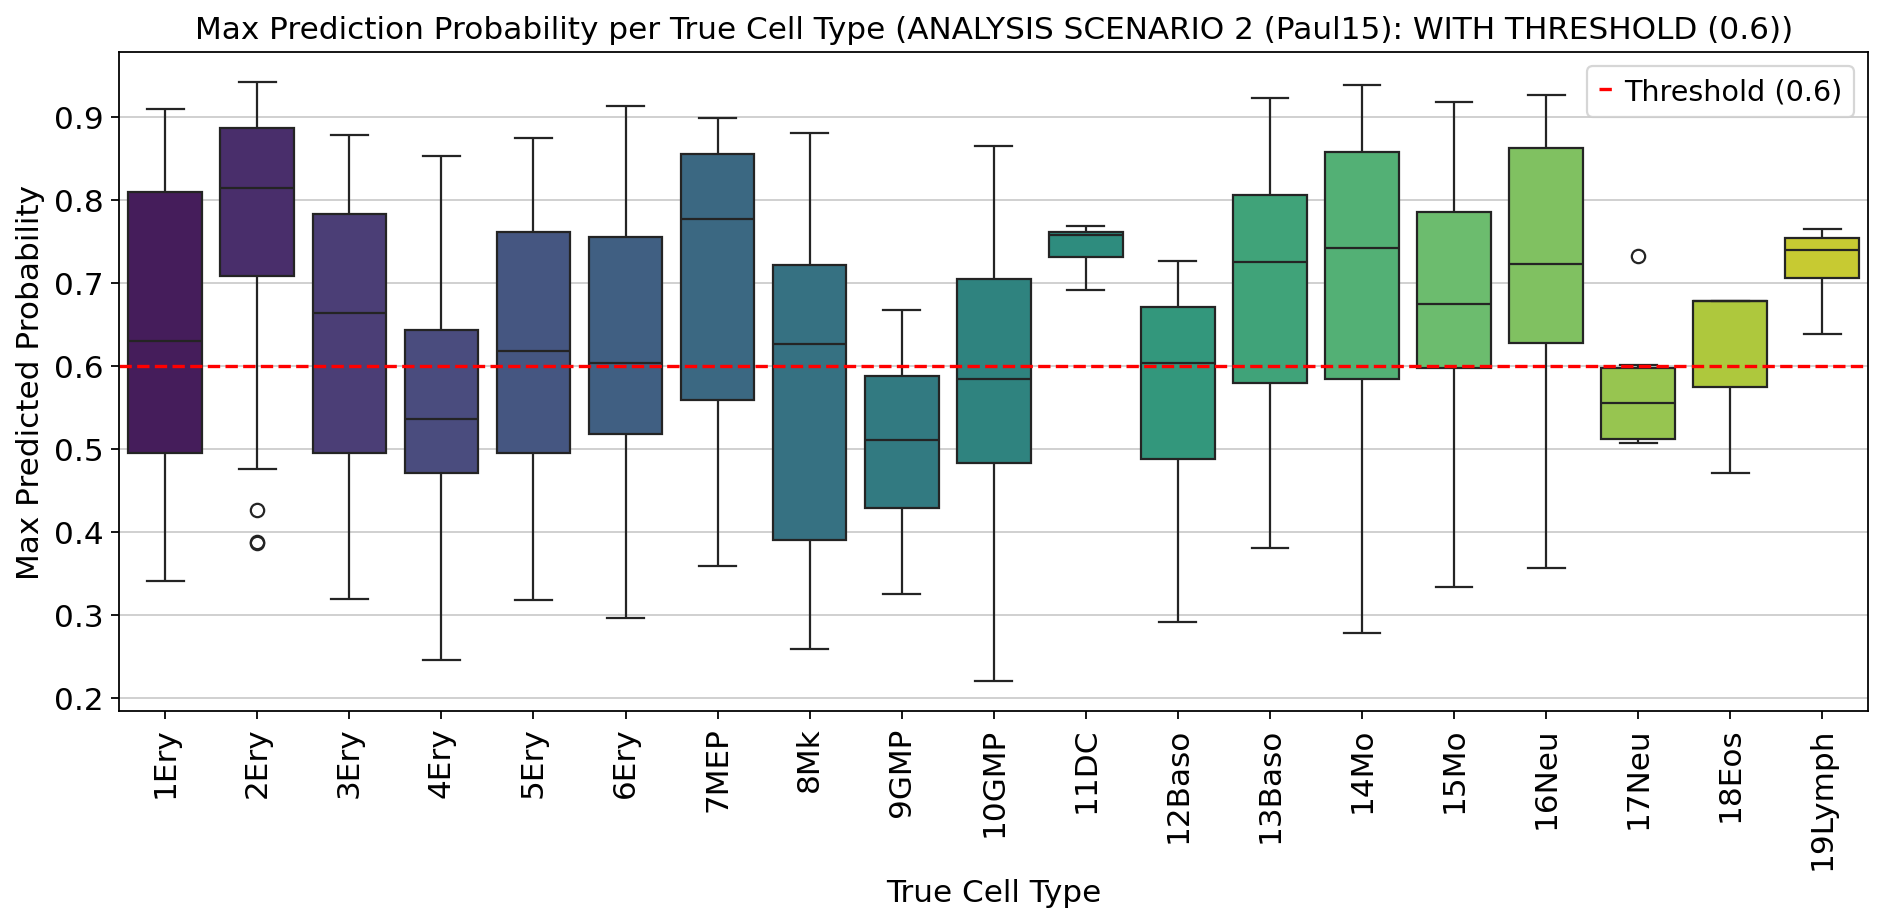


--- Max Prediction Probability per Predicted Label (ANALYSIS SCENARIO 2 (Paul15): WITH THRESHOLD (0.6)) ---


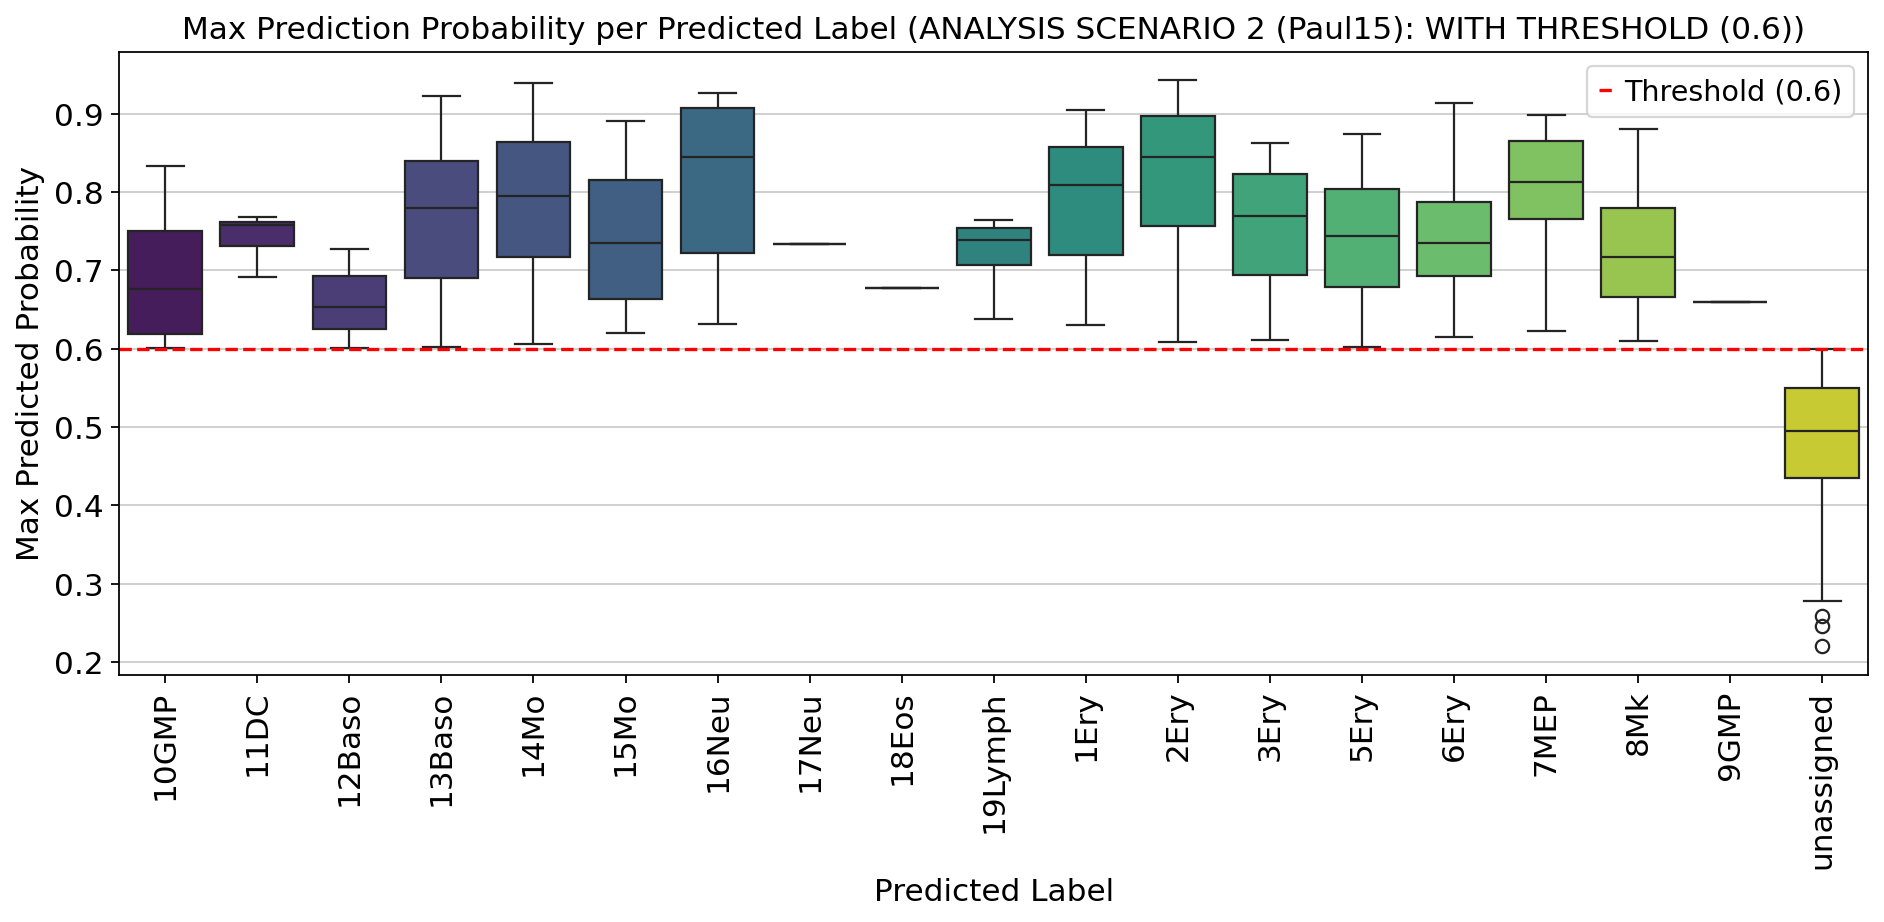


--- UMAP Visualizations (ANALYSIS SCENARIO 2 (Paul15): WITH THRESHOLD (0.6)) ---


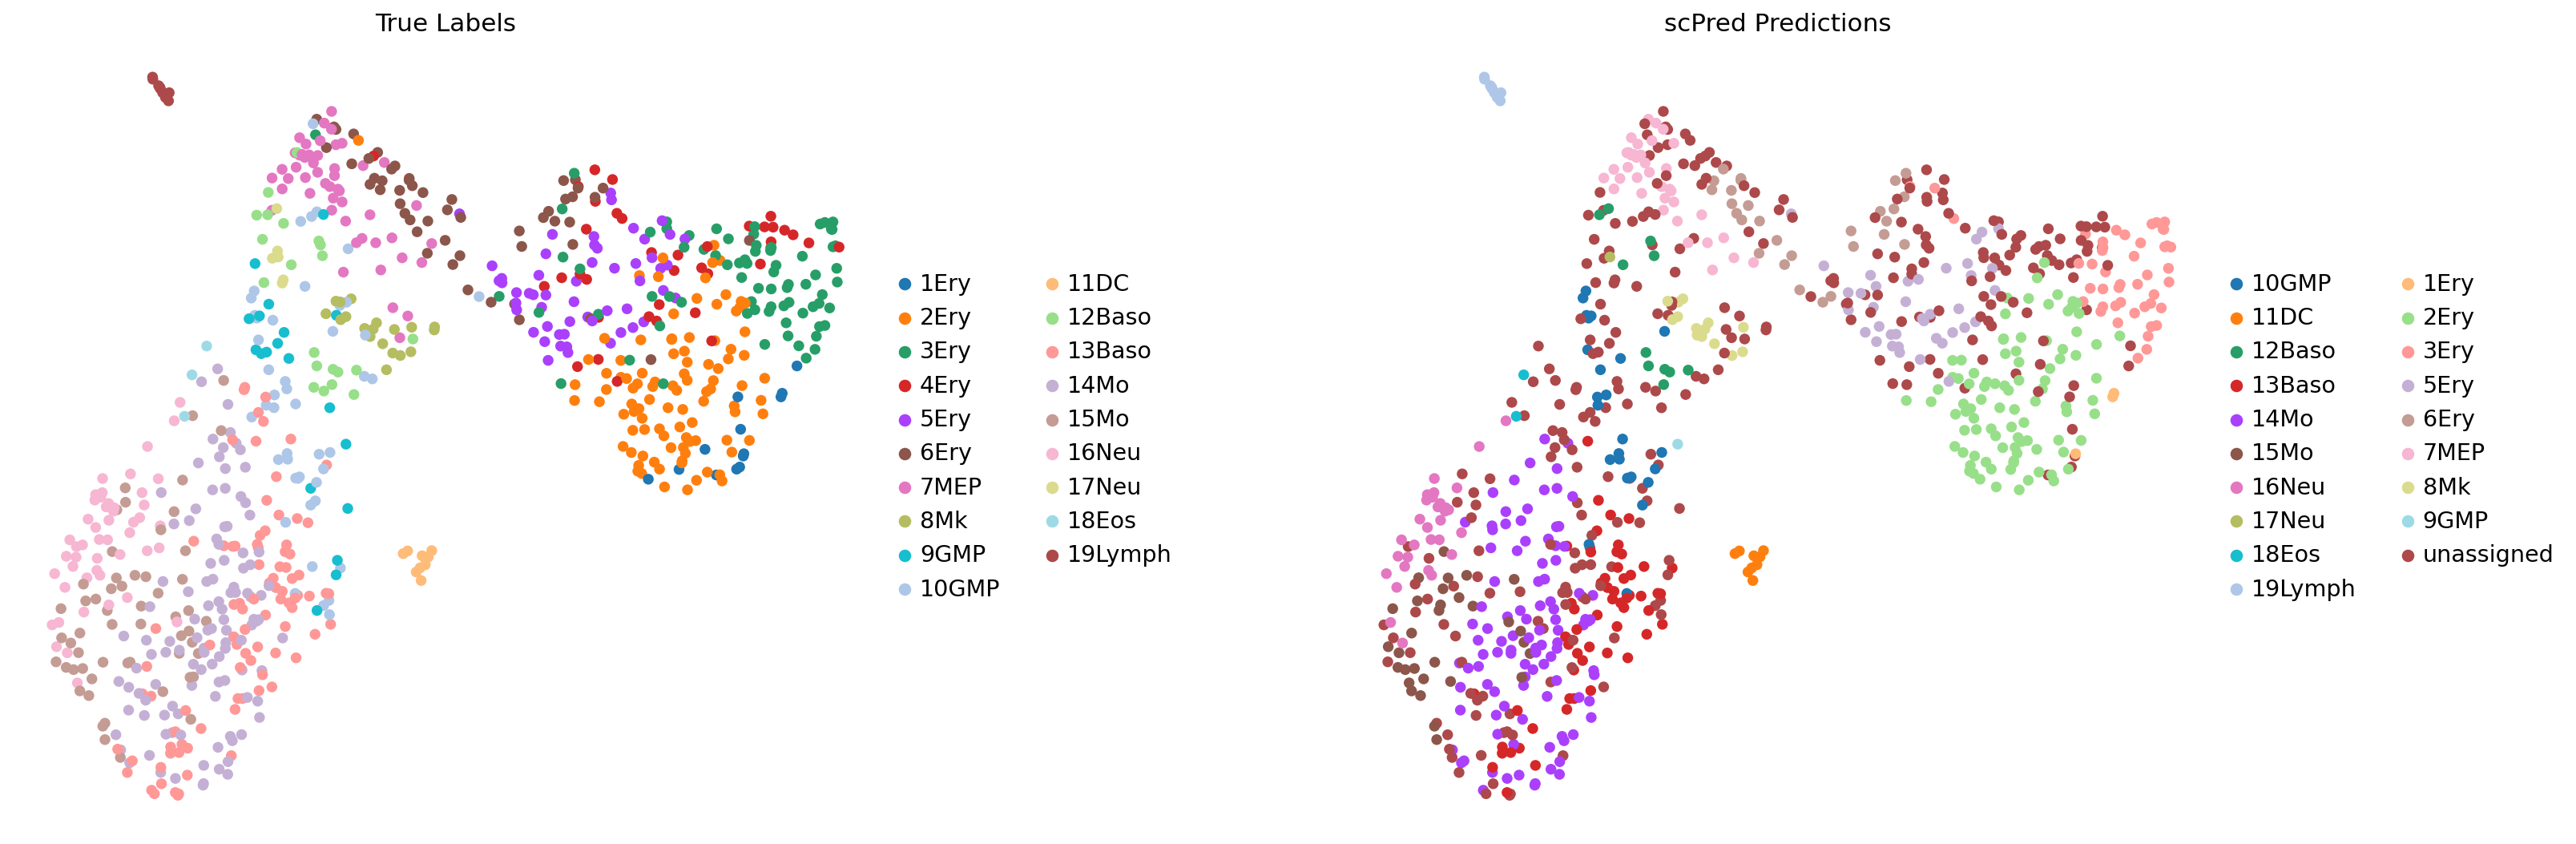

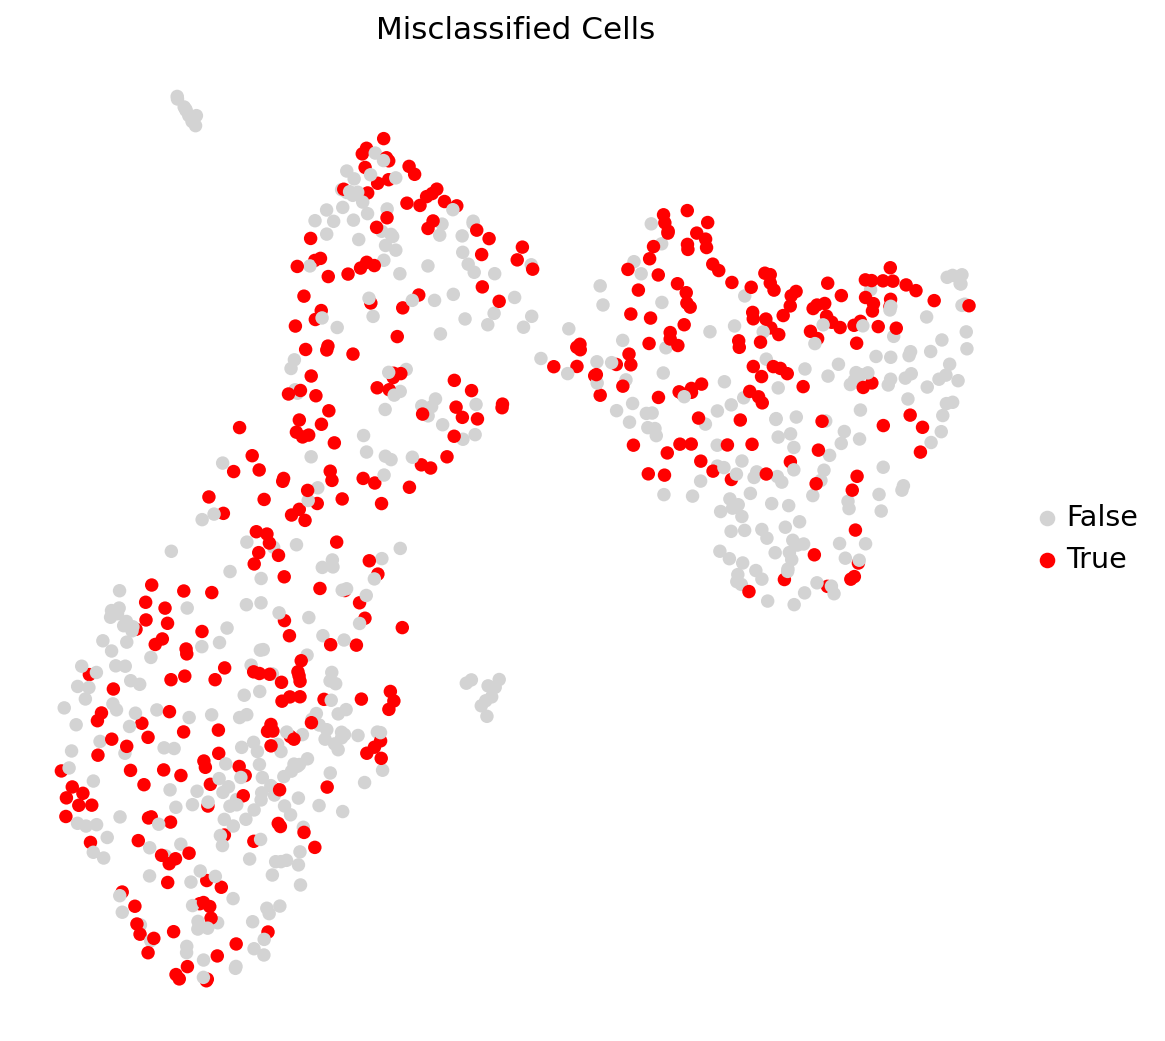

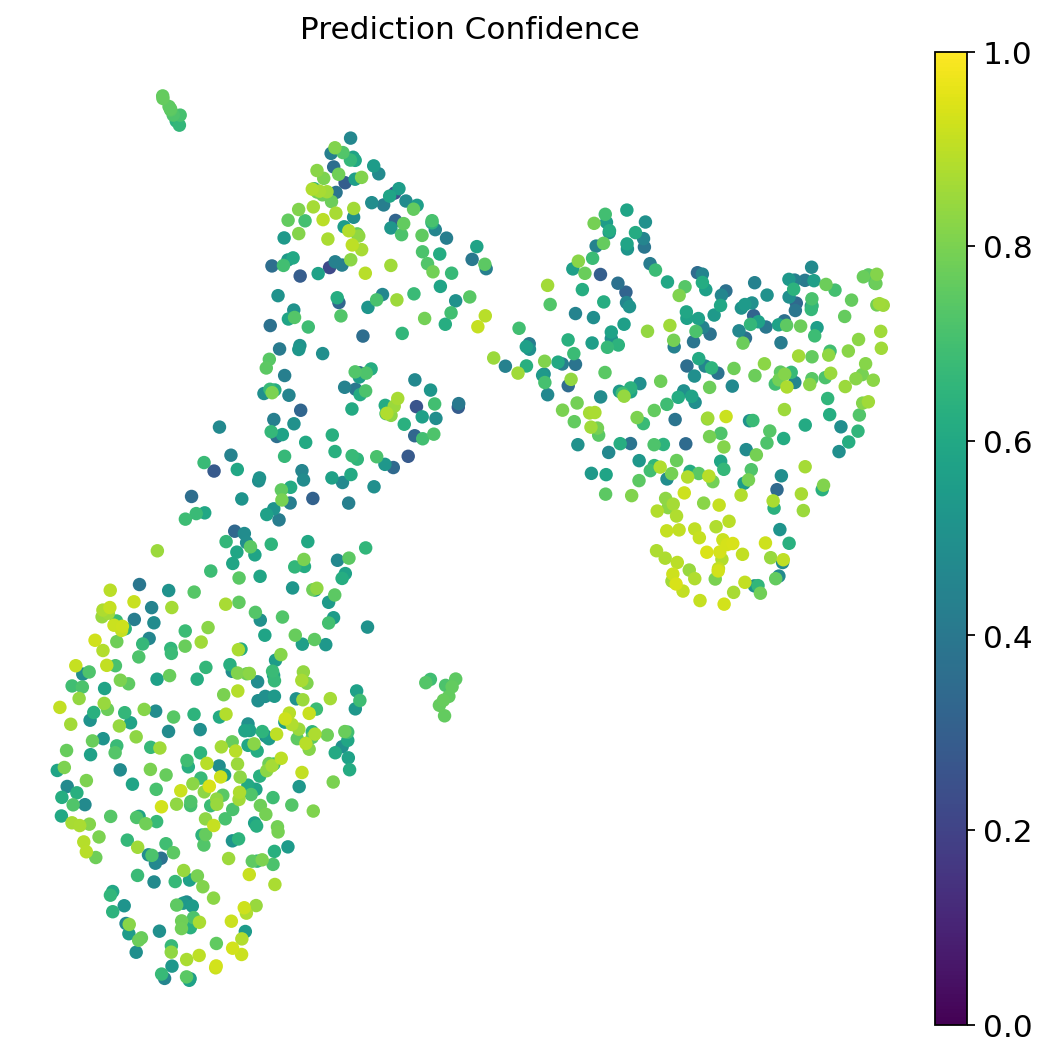


--- Paul15 Analysis Complete ---


In [7]:
# --- Run Scenario 2 ---
run_scenario(scpred_model, query_adata_raw, threshold=0.6, scenario_name="ANALYSIS SCENARIO 2 (Paul15): WITH THRESHOLD (0.6)", random_state=RANDOM_STATE)

print("\n--- Paul15 Analysis Complete ---")